# BÀI THỰC HÀNH: PHÂN ĐOẠN TÍN HIỆU TIẾNG NÓI VÀ KHOẢNG LẶNG
### (Speech / Silence Discrimination using Energy-based Binary Search)
**Học phần:** Audio and Speech Processing
**Tài liệu tham khảo chính:**
- *CS425 Audio and Speech Processing* – Hodgkinson (2012), Section 2.1: Energy-based Speech/Silence discrimination
- Hướng dẫn thực hành phân đoạn tiếng nói / khoảng lặng (`HuongDan.md`)

---

## I. CƠ SỞ LÝ THUYẾT & PHƯƠNG PHÁP LUẬN

### 1. Phân tích khung ngắn hạn (Short-Time Analysis)
Tín hiệu tiếng nói có tính chất dừng cục bộ trong các khoảng thời gian ngắn ($10-30\text{ ms}$). Do đó tín hiệu âm thanh $x[n]$ được chia thành các khung (frame) có độ dài $L$ và bước nhảy (shift) $R$:
- **Frame length:** $L = 20\text{ ms}$ (ở $16\text{ kHz}$ tương đương $320$ mẫu; ở $44.1\text{ kHz}$ tương đương $882$ mẫu).
- **Frame shift:** $R = 10\text{ ms}$ (độ chồng lấp $50\%$ giữa các khung kế cận).

Đặc trưng ngắn hạn được sử dụng là **Mean Absolute (MA)** và **log(MA)**:
$$\text{MA}[m] = \frac{1}{L} \sum_{n=0}^{L-1} |x[m \cdot R + n]|$$
$$\text{logMA}[m] = \ln(\text{MA}[m] + \epsilon) \quad (\epsilon = 10^{-10})$$
- *Ưu điểm:* $\text{logMA}$ nén động dải biên độ, giúp phân biệt rõ rệt giữa miền năng lượng thấp (khoảng lặng) và miền năng lượng cao (nguyên âm, phụ âm hữu thanh).

---

### 2. Thuật toán Tìm kiếm nhị phân (Binary Search) tìm Ngưỡng tối ưu
Theo Hodgkinson (2012), ngưỡng tối ưu $T$ **bắt buộc phải nằm trong Vùng Chồng Lấn (Overlap Region)** giữa phân bố của tiếng nói Speech ($g$) và khoảng lặng Silence ($f$):
$$T_{min} = \max(\min(g), \min(f)), \quad T_{max} = \min(\max(g), \max(f))$$

Tại mỗi giá trị ngưỡng thử nghiệm $T = \frac{T_{min} + T_{max}}{2}$, hàm mất mát nhầm lẫn (confusion) được định nghĩa:
$$C_{silence}(T) = \frac{1}{N_{sil}} \sum_{f \in \text{Silence}} \max(f - T, 0) \quad \text{(Mức độ Silence bị nhận nhầm thành Speech)}$$
$$C_{speech}(T) = \frac{1}{N_{spch}} \sum_{g \in \text{Speech}} \max(T - g, 0) \quad \text{(Mức độ Speech bị nhận nhầm thành Silence)}$$
$$D(T) = C_{silence}(T) - C_{speech}(T)$$

**Quy tắc cập nhật nhị phân:**
- Nếu $D(T) > 0 \implies C_{silence} > C_{speech} \implies$ Ngưỡng $T$ đang quá thấp $\implies$ Tăng ngưỡng: $T_{min} = T$.
- Nếu $D(T) < 0 \implies C_{speech} > C_{silence} \implies$ Ngưỡng $T$ đang quá cao $\implies$ Giảm ngưỡng: $T_{max} = T$.

Thuật toán hội tụ và dừng lại khi:
$$|D(T)| < 10^{-9} \quad \text{hoặc} \quad (T_{max} - T_{min}) < 10^{-9}$$

---

### 3. Hậu xử lý & Lọc Khoảng lặng Ngắn ($< 300\text{ ms}$)
Trong ngữ âm học thực tế, khoảng dừng phát âm tự nhiên của con người giữa các từ hoặc câu có thời lượng đáng kể. Những khoảng năng lượng thấp có độ dài $< 300\text{ ms}$ thường xuất phát từ:
- Khoảng nén khí trước âm tắc (plosive closure, ví dụ /p/, /t/, /k/).
- Các phụ âm vô thanh năng lượng thấp hoặc ngắt âm rất ngắn.

Việc phân đoạn thuần túy theo từng frame sẽ tạo ra các đoạn ngắt vụn vặt (khoảng lặng ảo). Thuật toán hậu xử lý sẽ **gộp các đoạn silence $< 300\text{ ms}$ vào đoạn tiếng nói liền kề**, đảm bảo tính liên tục tự nhiên của câu nói.

---

### 4. Tiêu chí Đánh giá Ranh giới (Boundary Matching Metrics)
Các điểm biên phân đoạn dự đoán ($B_{pred}$) được so khớp với các điểm biên Ground Truth ($B_{gt}$) từ file nhãn `.lab` với khoảng dung sai cho phép **$\text{Tolerance} = 100\text{ ms}$**:
- **Precision:** $P = \frac{N_{matched}}{N_{pred}}$ (Tỷ lệ biên dự đoán trùng khớp đúng biên thực tế).
- **Recall:** $R = \frac{N_{matched}}{N_{gt}}$ (Tỷ lệ biên thực tế được phát hiện thành công).
- **F1-Score:** $F_1 = \frac{2 \cdot P \cdot R}{P + R}$ (Trung bình điều hòa giữa Precision và Recall).
- **MAE (Mean Absolute Error):** Sai số tuyệt đối trung bình giữa các cặp biên **đã khớp** (chỉ tính trên $N_{matched}$ cặp, KHÔNG tính các biên không khớp được):
  $$\text{MAE} = \frac{1}{N_{matched}} \sum_{i=1}^{N_{matched}} |t_{pred, i} - t_{gt, i}| \quad (\text{đơn vị: ms})$$
- **RMSE (Root Mean Squared Error):** Căn bậc hai trung bình bình phương sai số, phạt nặng hơn các sai số lớn:
  $$\text{RMSE} = \sqrt{\frac{1}{N_{matched}} \sum_{i=1}^{N_{matched}} (t_{pred, i} - t_{gt, i})^2} \quad (\text{đơn vị: ms})$$

> ⚠️ **Lưu ý khi đọc MAE/RMSE:** vì hai chỉ số này chỉ tính trên các cặp **đã khớp**, một hệ thống bỏ sót nhiều biên (Recall thấp) vẫn có thể cho MAE/RMSE rất đẹp — luôn đọc MAE/RMSE **cùng với** Precision/Recall/F1, không đọc riêng lẻ. Mục **II bis** bên dưới sẽ kiểm chứng lại cách 3 chỉ số này được tính trong code trước khi tin tưởng số liệu ở các bước sau.

---
## II. THIẾT LẬP MÔI TRƯỜNG & IMPORT MODULES

Codebase được tổ chức theo kiến trúc modular:
- `src/`: các module dùng chung (`config`, `features`, `threshold`, `segmentation`, `io_utils`, `plotting`)
- `train/`: huấn luyện ngưỡng (`train_threshold`)
- `test/`: pipeline kiểm thử độc lập cho giáo viên (`evaluate_test`)

In [86]:
%matplotlib inline
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# Thêm project root vào sys.path để import được package `src`
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FEATURE_TYPE, FRAME_LENGTH_MS, FRAME_SHIFT_MS,
    MIN_SILENCE_DURATION_MS, BOUNDARY_MATCH_TOLERANCE_MS,
    ORIGINAL_TRAINING_DIR, OUTPUT_DIR, TEST_DIR,
)
from src.io_utils import load_audio, parse_lab_file, load_ground_truth
from src.features import compute_short_time_feature, assign_frame_labels
from src.threshold import find_overlap_region, find_optimal_threshold_binary_search
from src.segmentation import (
    classify_frames, frames_to_segments, remove_short_silence_segments,
    compute_boundary_errors, extract_boundaries, match_boundaries,
)

TRAIN_FILES = ["studio_F1", "studio_M1", "phone_F1", "phone_M1"]

print("=== MÔI TRƯỜNG ĐÃ ĐƯỢC KHỞI TẠO THÀNH CÔNG ===")
print(f"Đặc trưng sử dụng : {FEATURE_TYPE.value}")
print(f"Độ dài frame      : {FRAME_LENGTH_MS} ms (shift: {FRAME_SHIFT_MS} ms)")
print(f"Lọc silence ngắn  : {MIN_SILENCE_DURATION_MS} ms")
print(f"Dung sai match    : {BOUNDARY_MATCH_TOLERANCE_MS} ms")
print(f"Thư mục training  : {ORIGINAL_TRAINING_DIR}")
print(f"Thư mục test      : {TEST_DIR}")
print(f"Thư mục output    : {OUTPUT_DIR}")
print(f"Danh sách file    : {', '.join(TRAIN_FILES)}")

# Kiểm tra sớm các đường dẫn cần thiết, báo lỗi rõ ràng thay vì để
# lỗi khó hiểu xuất hiện ở tận các bước sau.
missing = [p for p in (ORIGINAL_TRAINING_DIR, OUTPUT_DIR) if not os.path.isdir(p)]
if missing:
    print(f"\n⚠️  CẢNH BÁO: không tìm thấy thư mục: {missing}. "
          f"Hãy chạy `train/train_threshold.py` trước để sinh dữ liệu vào {OUTPUT_DIR}/.")

=== MÔI TRƯỜNG ĐÃ ĐƯỢC KHỞI TẠO THÀNH CÔNG ===
Đặc trưng sử dụng : logMA
Độ dài frame      : 20 ms (shift: 10 ms)
Lọc silence ngắn  : 300.0 ms
Dung sai match    : 100.0 ms
Thư mục training  : ./TinHieuHuanLuyen
Thư mục test      : ./TinHieuKiemThu
Thư mục output    : ./output
Danh sách file    : studio_F1, studio_M1, phone_F1, phone_M1


---
## III. TRÌNH TỰ THỰC THI TRỰC QUAN CỦA CHƯƠNG TRÌNH

### 1. Bước 1: Nạp File Âm thanh & Nhãn Chuẩn – Hiển thị Waveform Gốc (4 Files Huấn luyện)
- Đọc tín hiệu âm thanh `.wav` và file nhãn chuẩn `.lab` (`sil` = Silence, `v`/`uv` = Speech).
- Minh họa trực quan dạng sóng âm thanh với vùng **Speech (tô xanh dương)** và **Silence (tô hồng nhạt)** cho cả 4 file huấn luyện.


FILE: studio_F1.wav | Tần số lấy mẫu: 44100 Hz | Thời lượng: 2.86s | Số đoạn nhãn GT: 3


/Users/coding/XLTN/separate_speech_silence/src/io_utils.py:139: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(wav_path)


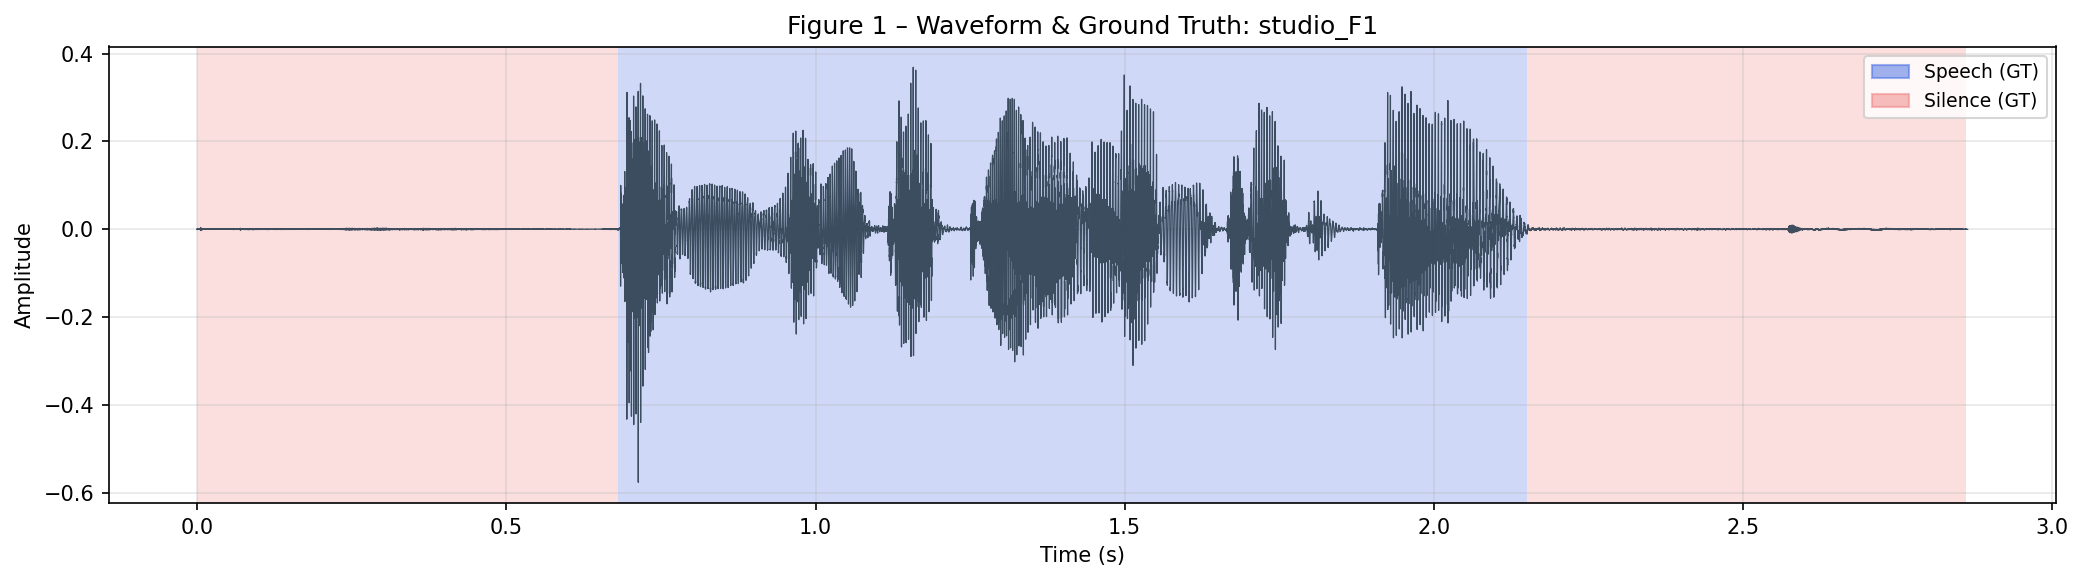


FILE: studio_M1.wav | Tần số lấy mẫu: 44100 Hz | Thời lượng: 2.73s | Số đoạn nhãn GT: 3


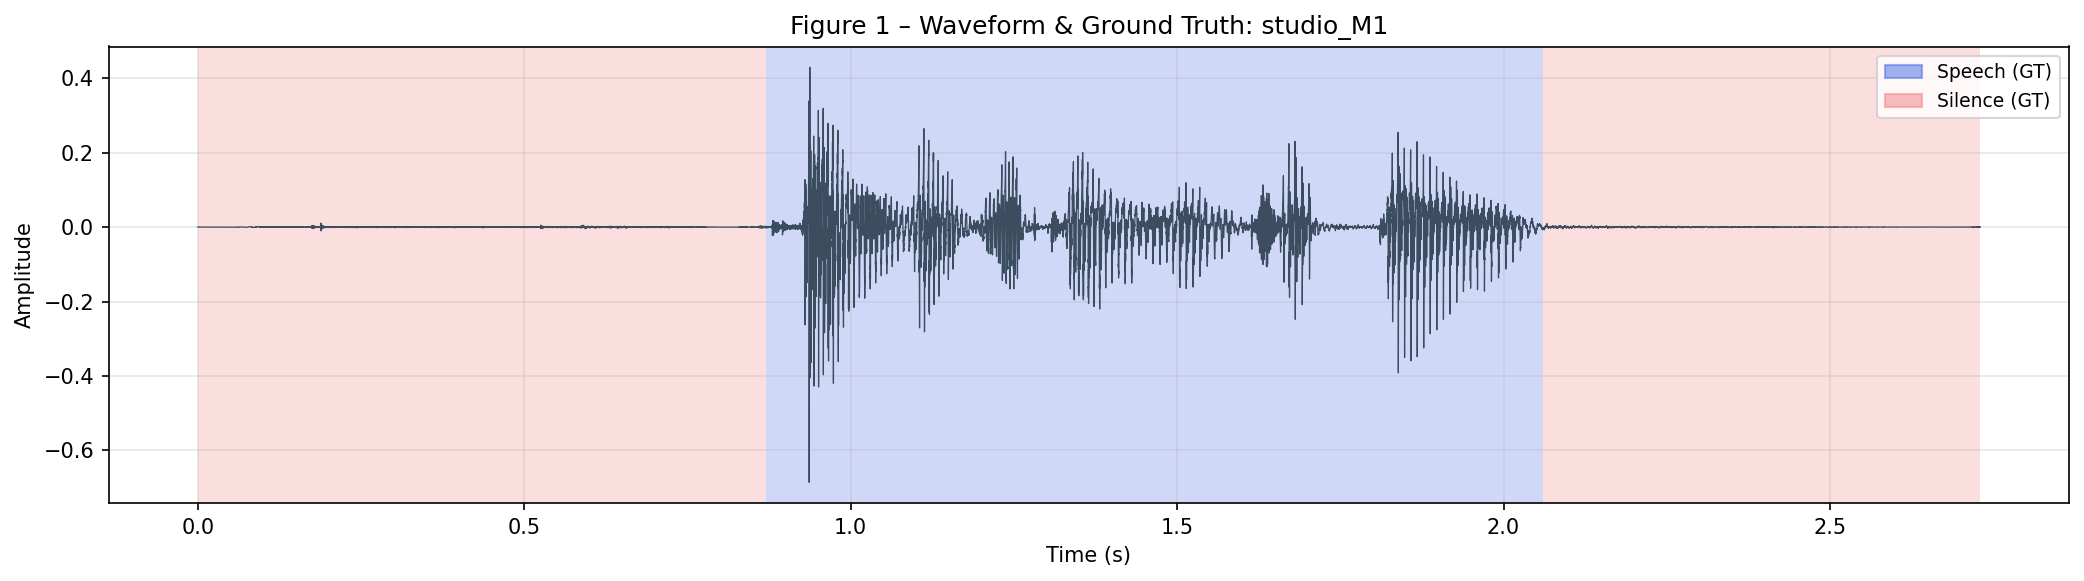


FILE: phone_F1.wav | Tần số lấy mẫu: 16000 Hz | Thời lượng: 3.24s | Số đoạn nhãn GT: 3


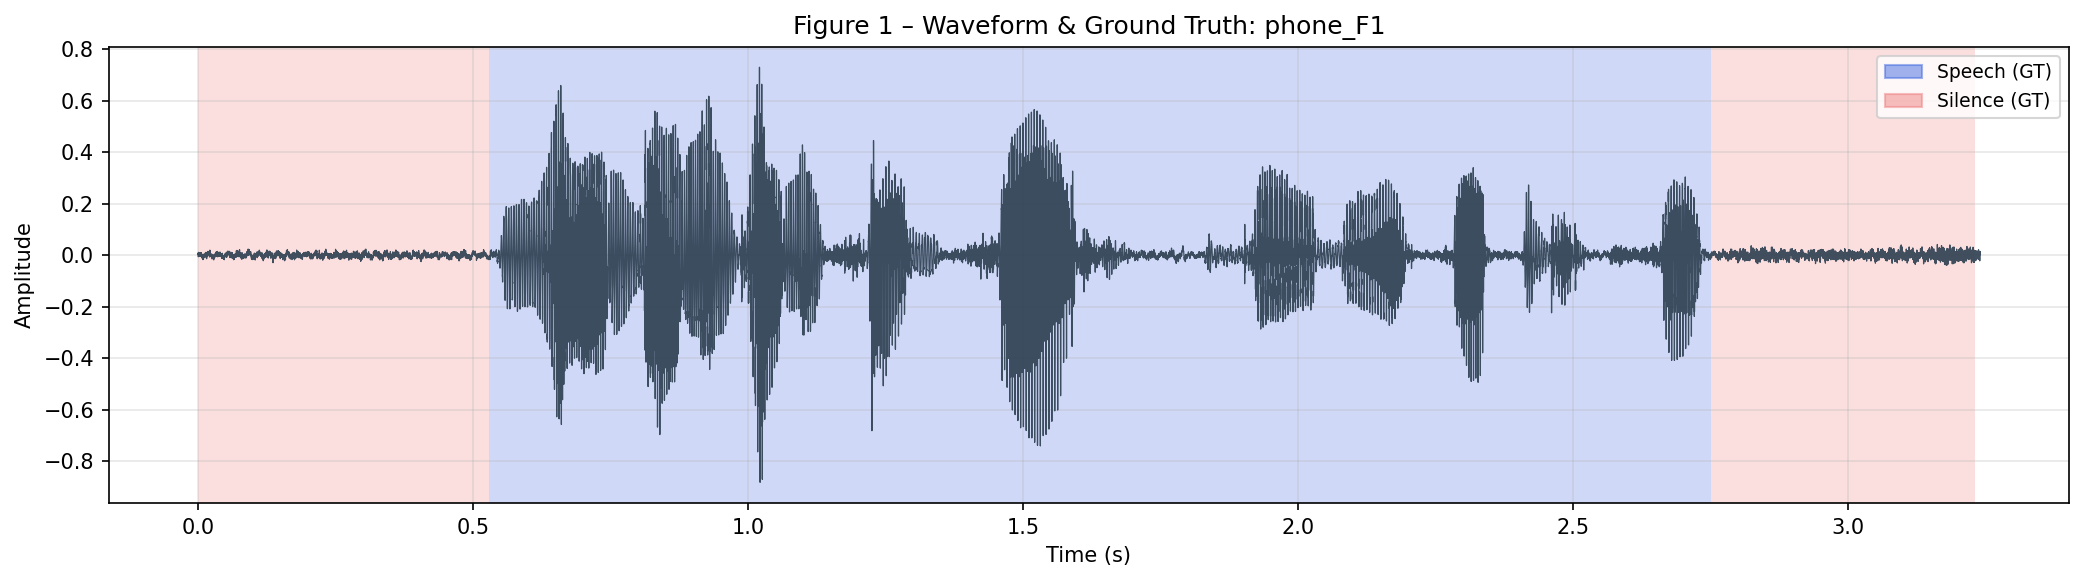


FILE: phone_M1.wav | Tần số lấy mẫu: 16000 Hz | Thời lượng: 4.16s | Số đoạn nhãn GT: 3


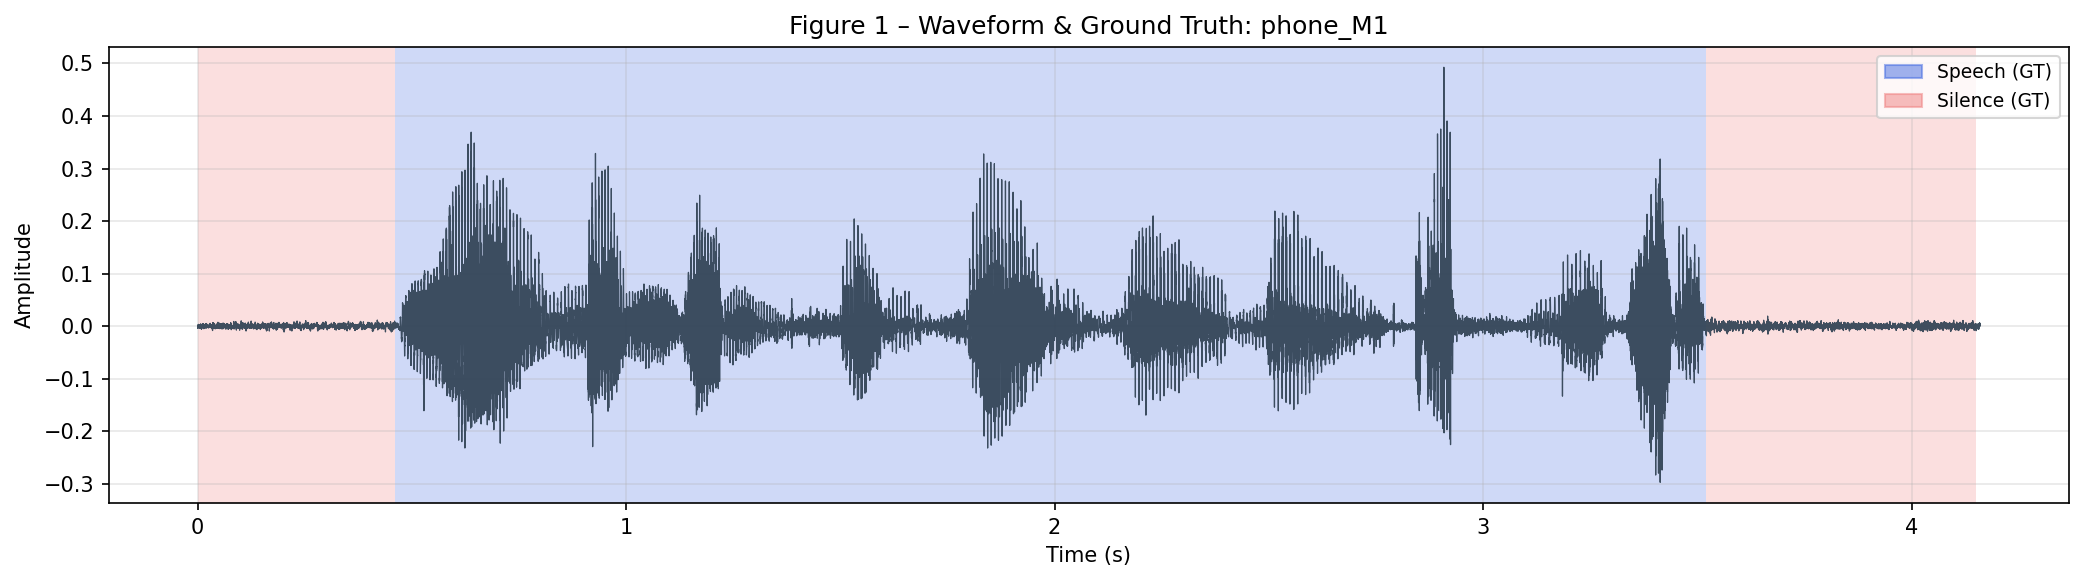

In [87]:
for fname in TRAIN_FILES:
    wav_path = os.path.join(ORIGINAL_TRAINING_DIR, f"{fname}.wav")
    lab_path = os.path.join(ORIGINAL_TRAINING_DIR, f"{fname}.lab")
    sig, sr = load_audio(wav_path)
    lab_segs = parse_lab_file(lab_path)
    gt_segs = load_ground_truth(lab_segs)

    print(f"\n{'='*75}")
    print(f"FILE: {fname}.wav | Tần số lấy mẫu: {sr} Hz | "
          f"Thời lượng: {len(sig)/sr:.2f}s | Số đoạn nhãn GT: {len(gt_segs)}")
    print(f"{'='*75}")
    fig_path = os.path.join(OUTPUT_DIR, "per_file", fname, "figures", f"{fname}_fig1_waveform_gt.png")
    display(Image(fig_path))

---
### 2. Bước 2: Biến đổi Tín hiệu sang Đặc trưng Ngắn hạn $\text{log(MA)}$ (4 Files)
- Tín hiệu được cắt thành các khung $20\text{ ms}$, dịch chuyển mỗi $10\text{ ms}$.
- Tại mỗi khung, tính trung bình biên độ tuyệt đối $\text{MA} = \frac{1}{L}\sum |x[n]|$ rồi lấy log: $\text{logMA} = \ln(\text{MA} + 10^{-10})$.
- **Ý nghĩa:** vùng có tiếng nói dao động mạnh $\implies \text{logMA}$ cao; vùng khoảng lặng chỉ có tạp âm $\implies \text{logMA}$ thấp.
- Đồ thị dưới đây so sánh trực tiếp dạng sóng gốc với đường cong đặc trưng $\text{logMA}$ cùng trục thời gian cho cả 4 file.


ĐẶC TRƯNG log(MA): studio_F1 (Số khung: 285, frame shift 10ms)


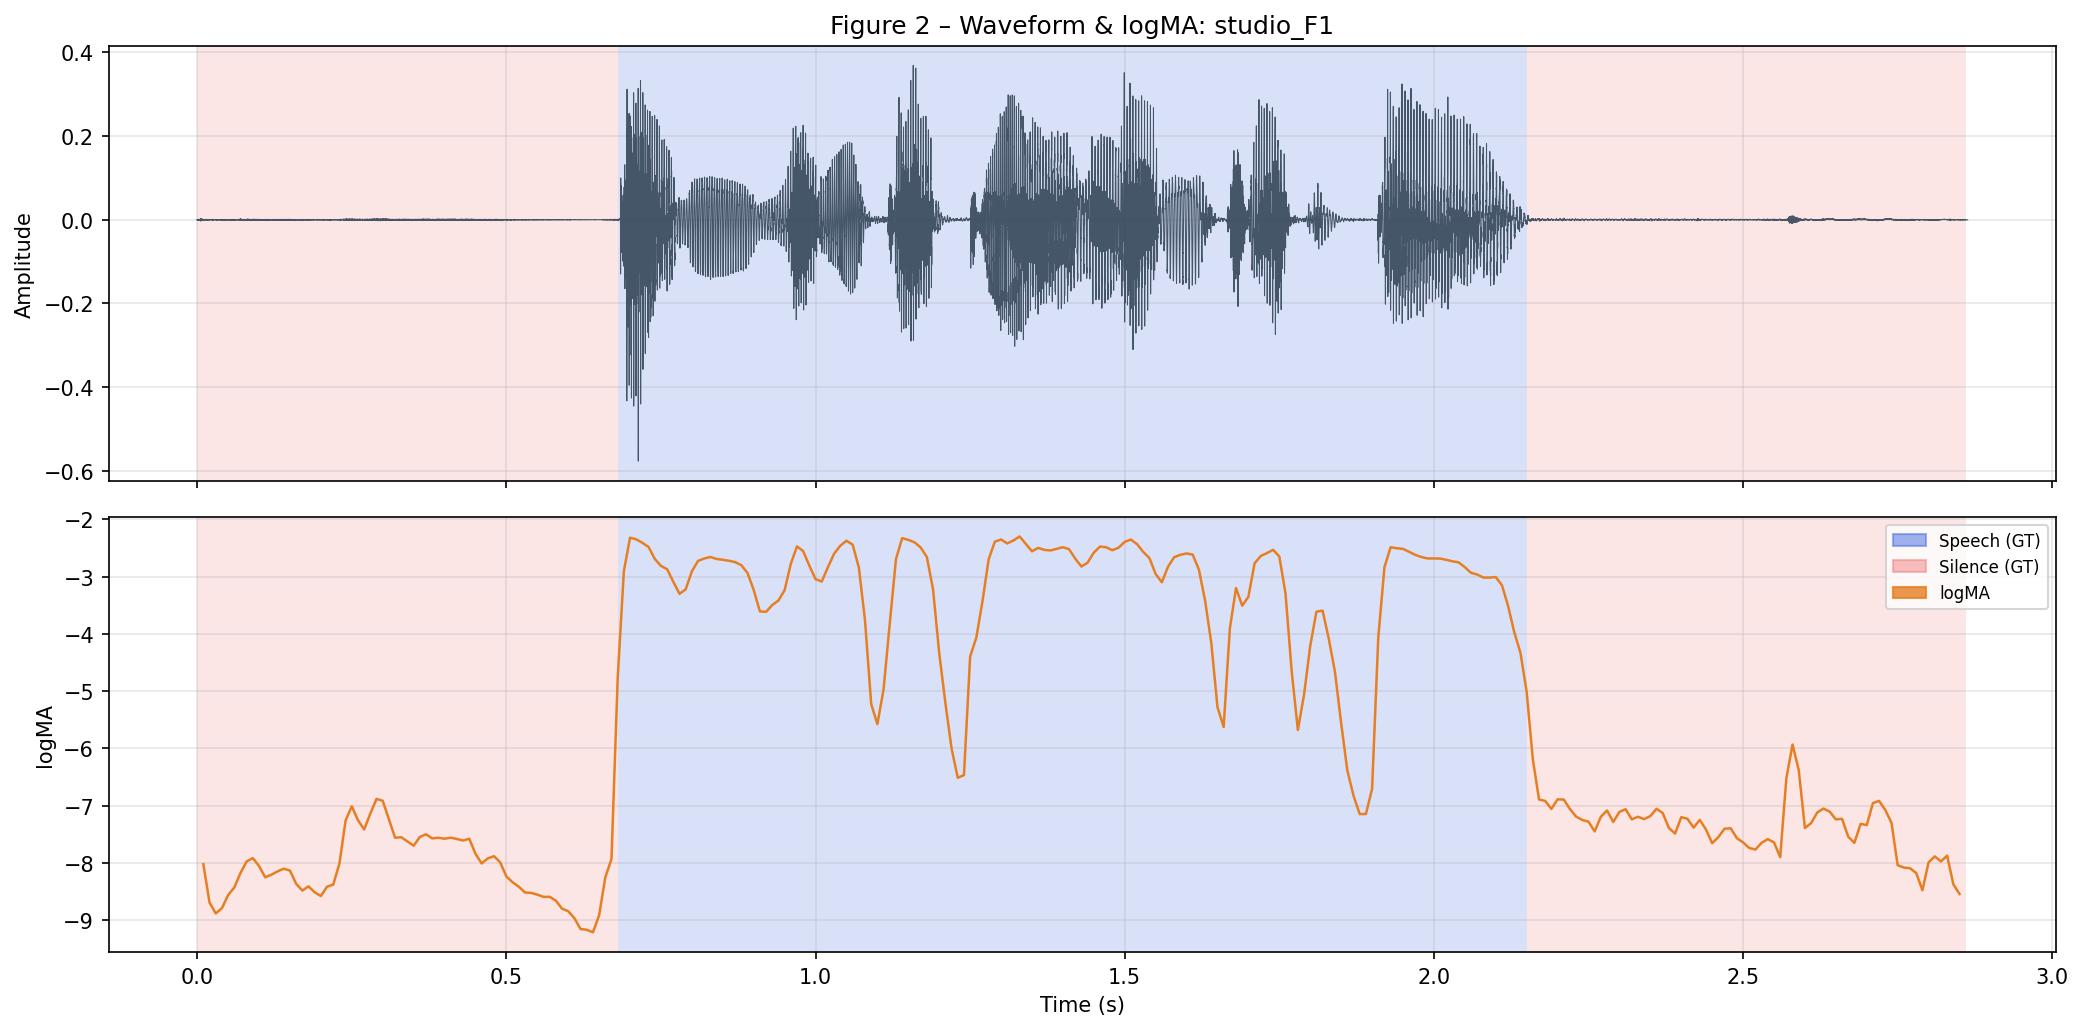


ĐẶC TRƯNG log(MA): studio_M1 (Số khung: 272, frame shift 10ms)


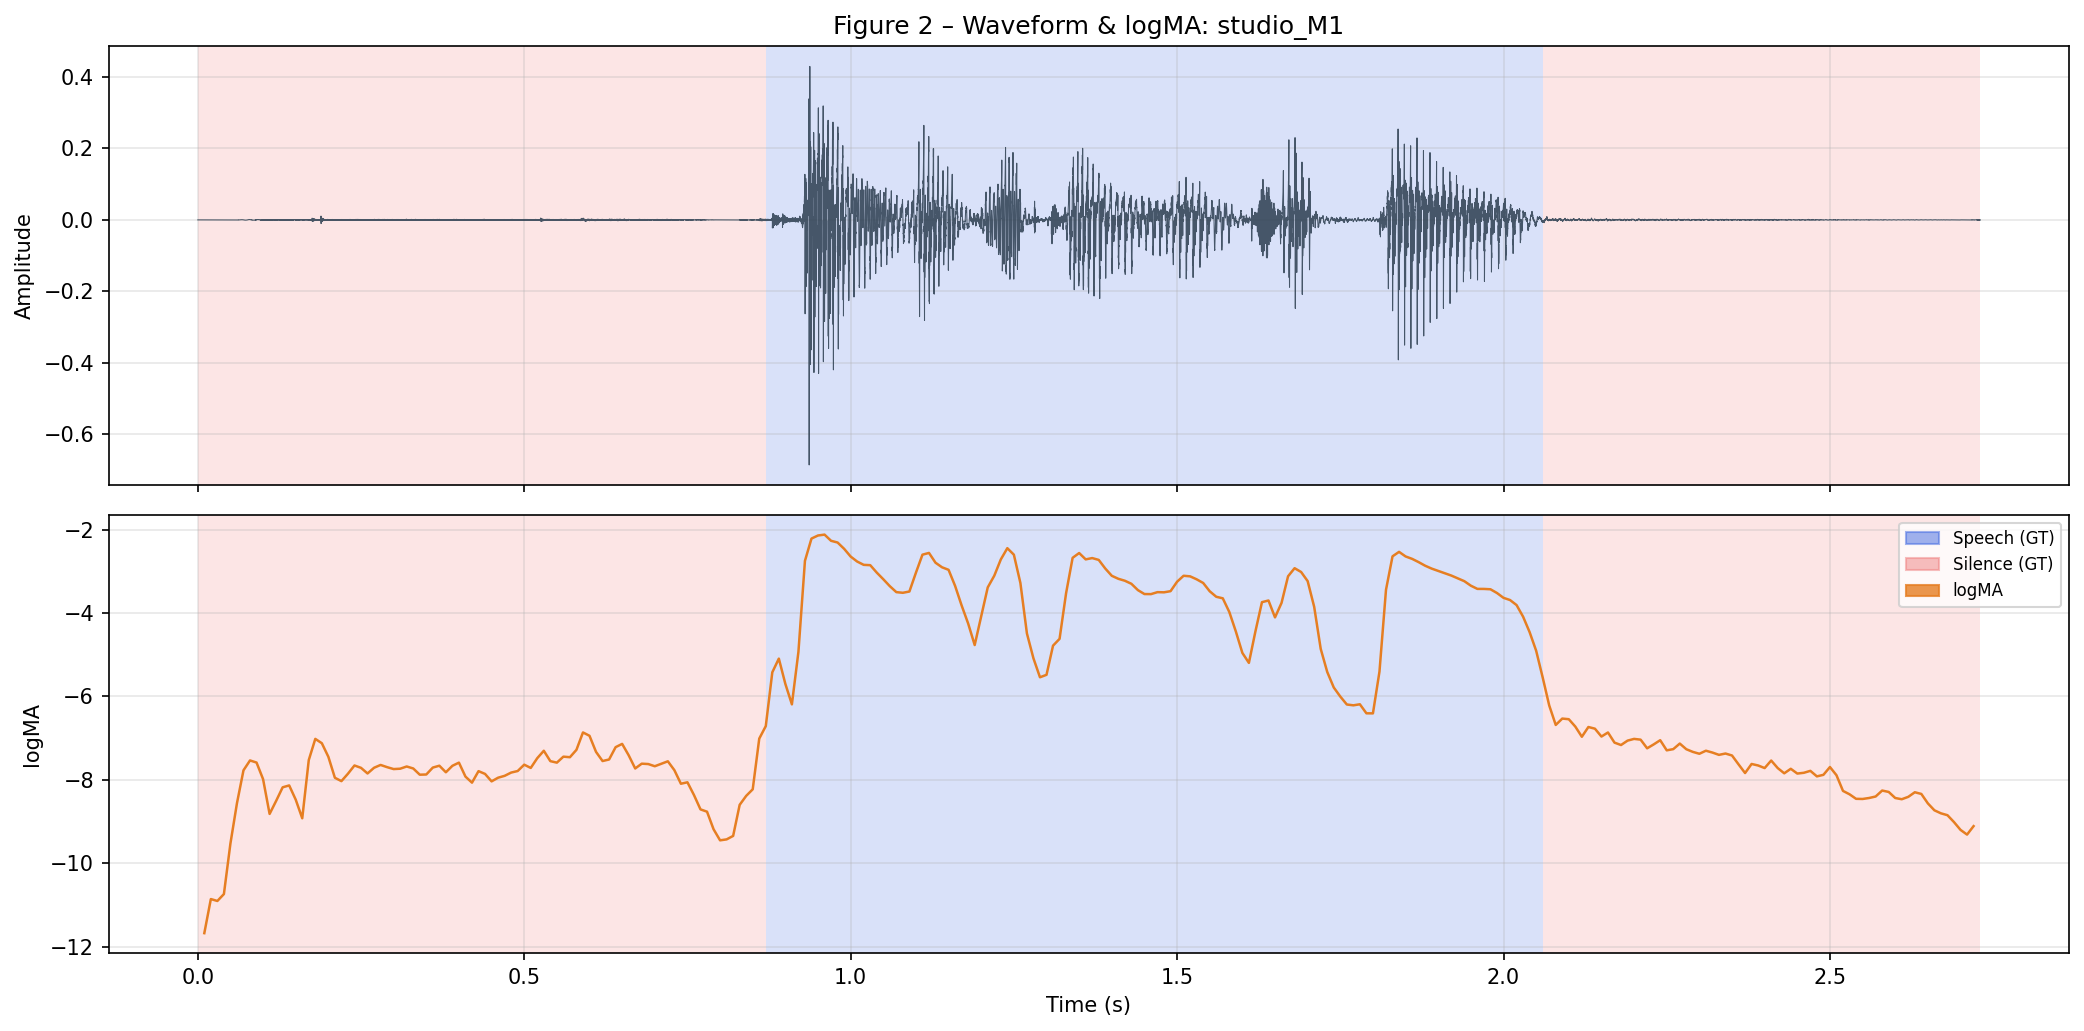


ĐẶC TRƯNG log(MA): phone_F1 (Số khung: 323, frame shift 10ms)


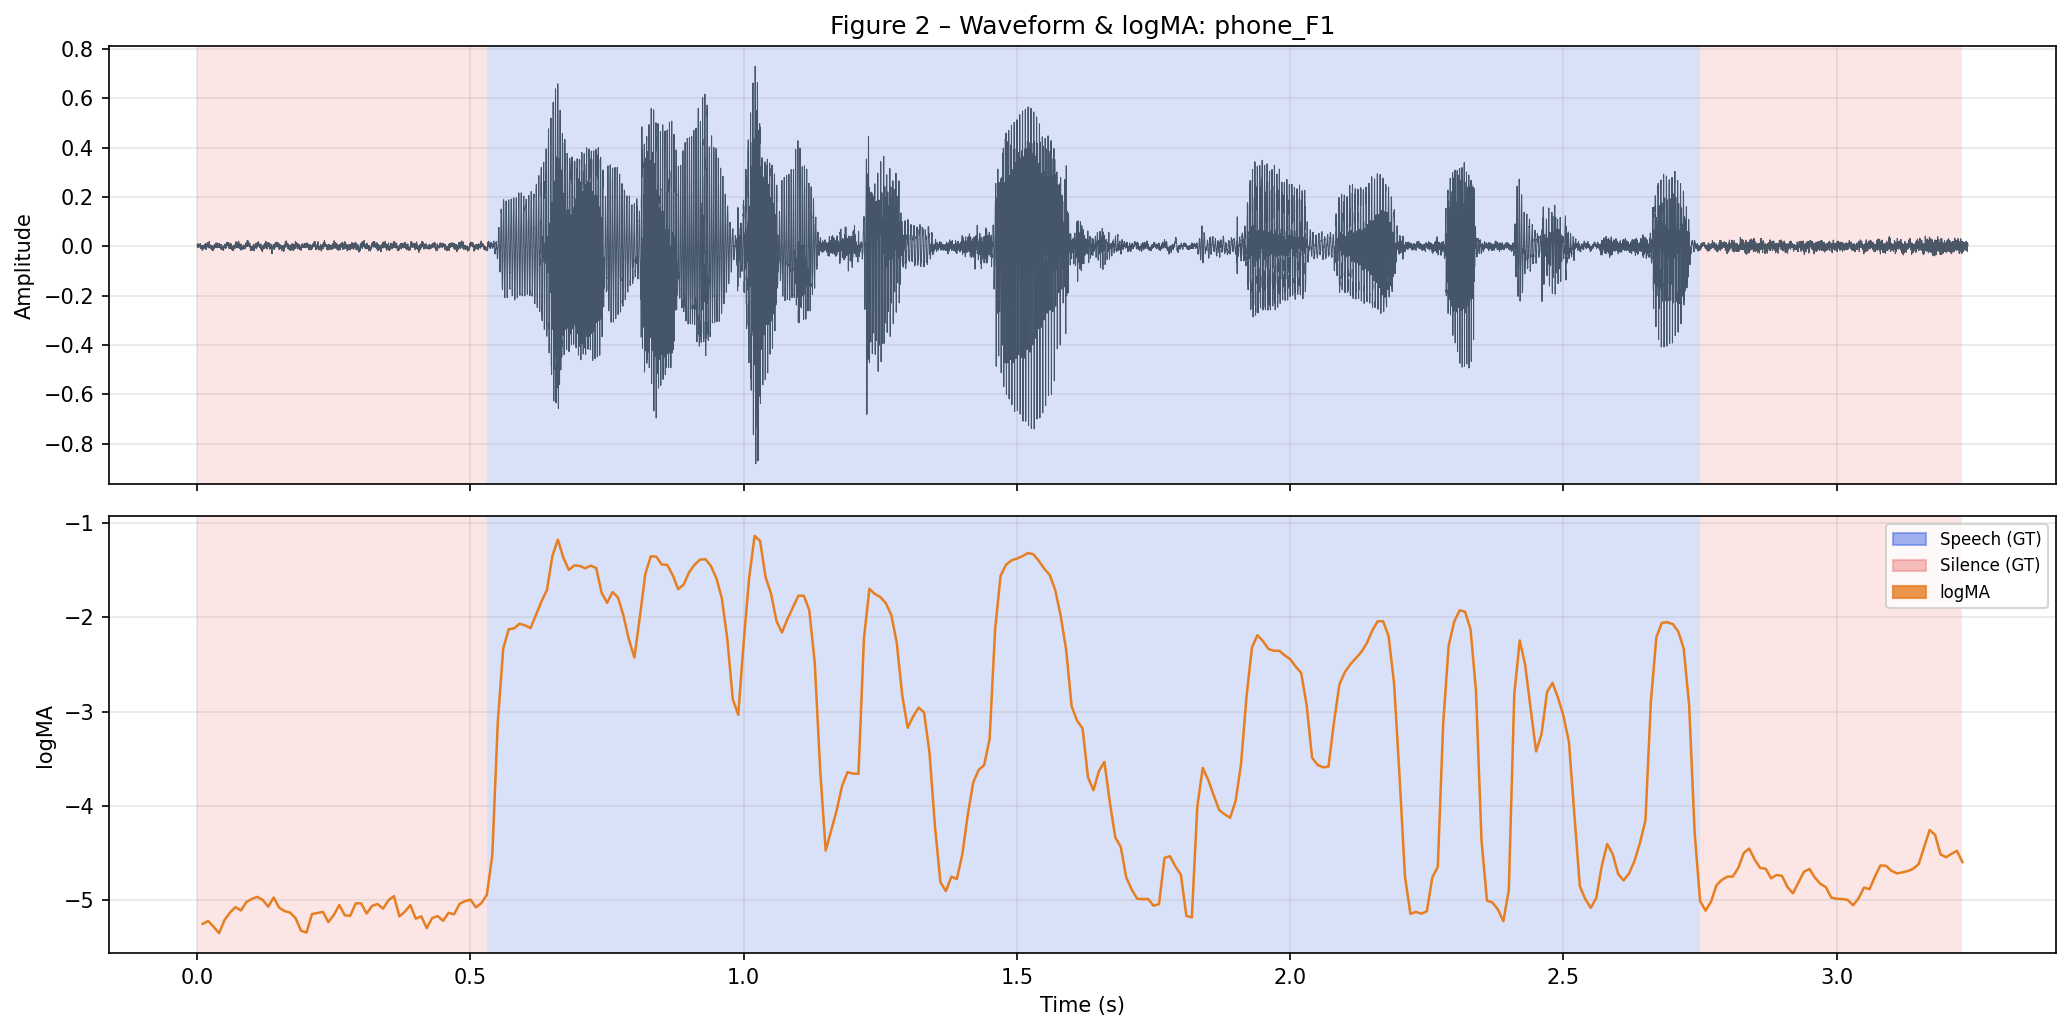


ĐẶC TRƯNG log(MA): phone_M1 (Số khung: 415, frame shift 10ms)


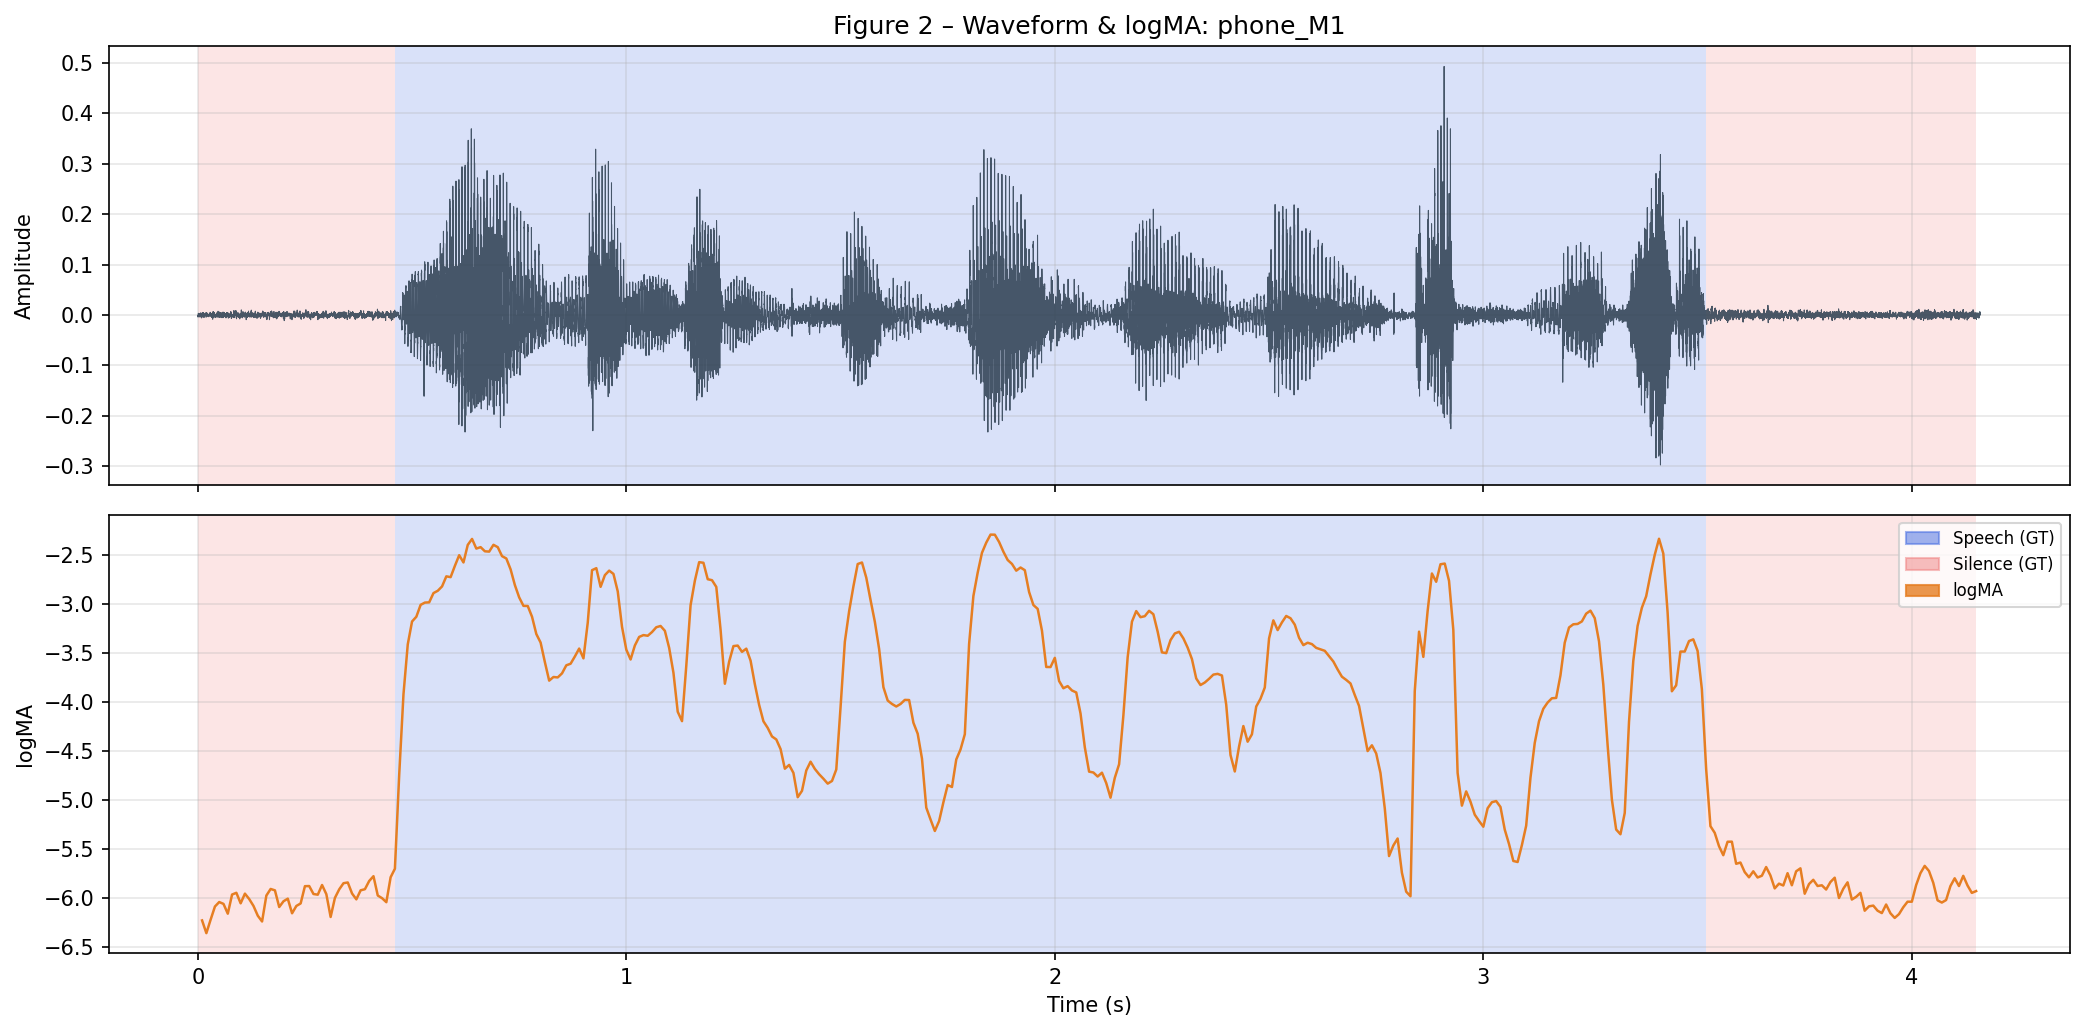

In [88]:
for fname in TRAIN_FILES:
    wav_path = os.path.join(ORIGINAL_TRAINING_DIR, f"{fname}.wav")
    sig, sr = load_audio(wav_path)
    fv, fc = compute_short_time_feature(sig, sr)

    print(f"\n{'='*75}")
    print(f"ĐẶC TRƯNG log(MA): {fname} (Số khung: {len(fv)}, frame shift 10ms)")
    print(f"{'='*75}")
    fig_path = os.path.join(OUTPUT_DIR, "per_file", fname, "figures", f"{fname}_fig2_feature.png")
    display(Image(fig_path))

---
### 3. Bước 3: Xác định & Trực quan hóa VÙNG OVERLAP (Chồng lấn – 4 Files)
Theo lý thuyết của **Hodgkinson (2012)**:
- Ngưỡng tối ưu $T$ **bắt buộc phải nằm trong khoảng chồng lấn** giữa phân bố Speech và Silence:
  $$T_{min} = \max(\min(\text{Speech}), \min(\text{Silence})), \quad T_{max} = \min(\max(\text{Speech}), \max(\text{Silence}))$$

> **Lưu ý quan trọng:** ở bước này hệ thống **chỉ mới xác định được miền chứa nghiệm $[T_{min}, T_{max}]$**.
> Binary Search **chưa chạy**, nên **chưa có giá trị $T$** — các đồ thị **Figure 2b** dưới đây chỉ hiển thị
> dải màu vàng Overlap giới hạn bởi 2 biên cam $T_{min}$/$T_{max}$, không có đường ngưỡng $T$ nào cả.

Biểu đồ **Figure 2b** đặt Waveform gốc (với nhãn Ground Truth) ở trên và đường cong $\text{logMA}$ ở dưới, làm nổi bật khoảng giá trị Overlap màu vàng.


VÙNG OVERLAP: studio_F1 -> [Tmin = -7.1472, Tmax = -5.0132]


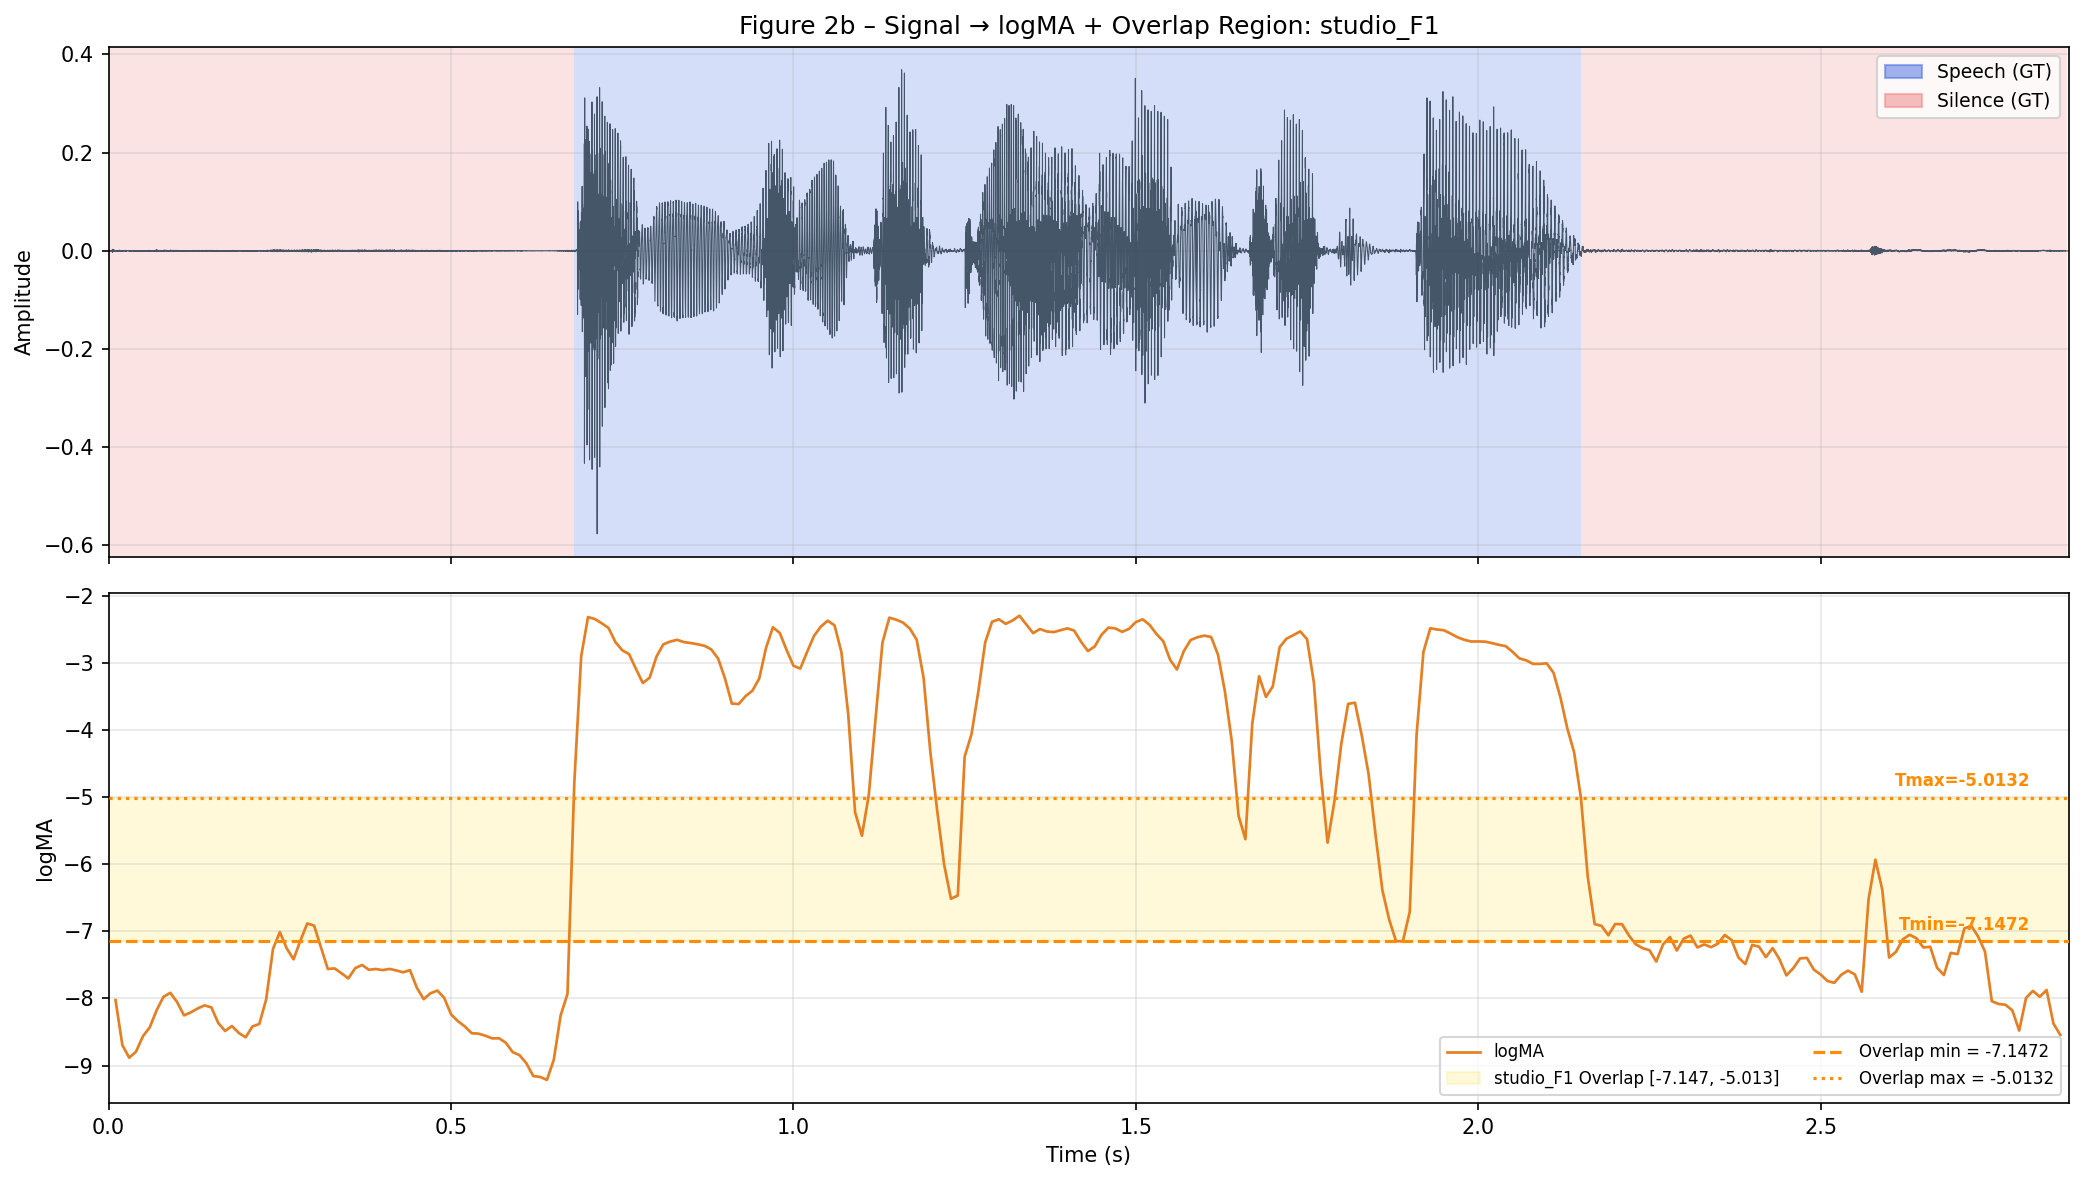


VÙNG OVERLAP: studio_M1 -> [Tmin = -6.7100, Tmax = -5.5441]


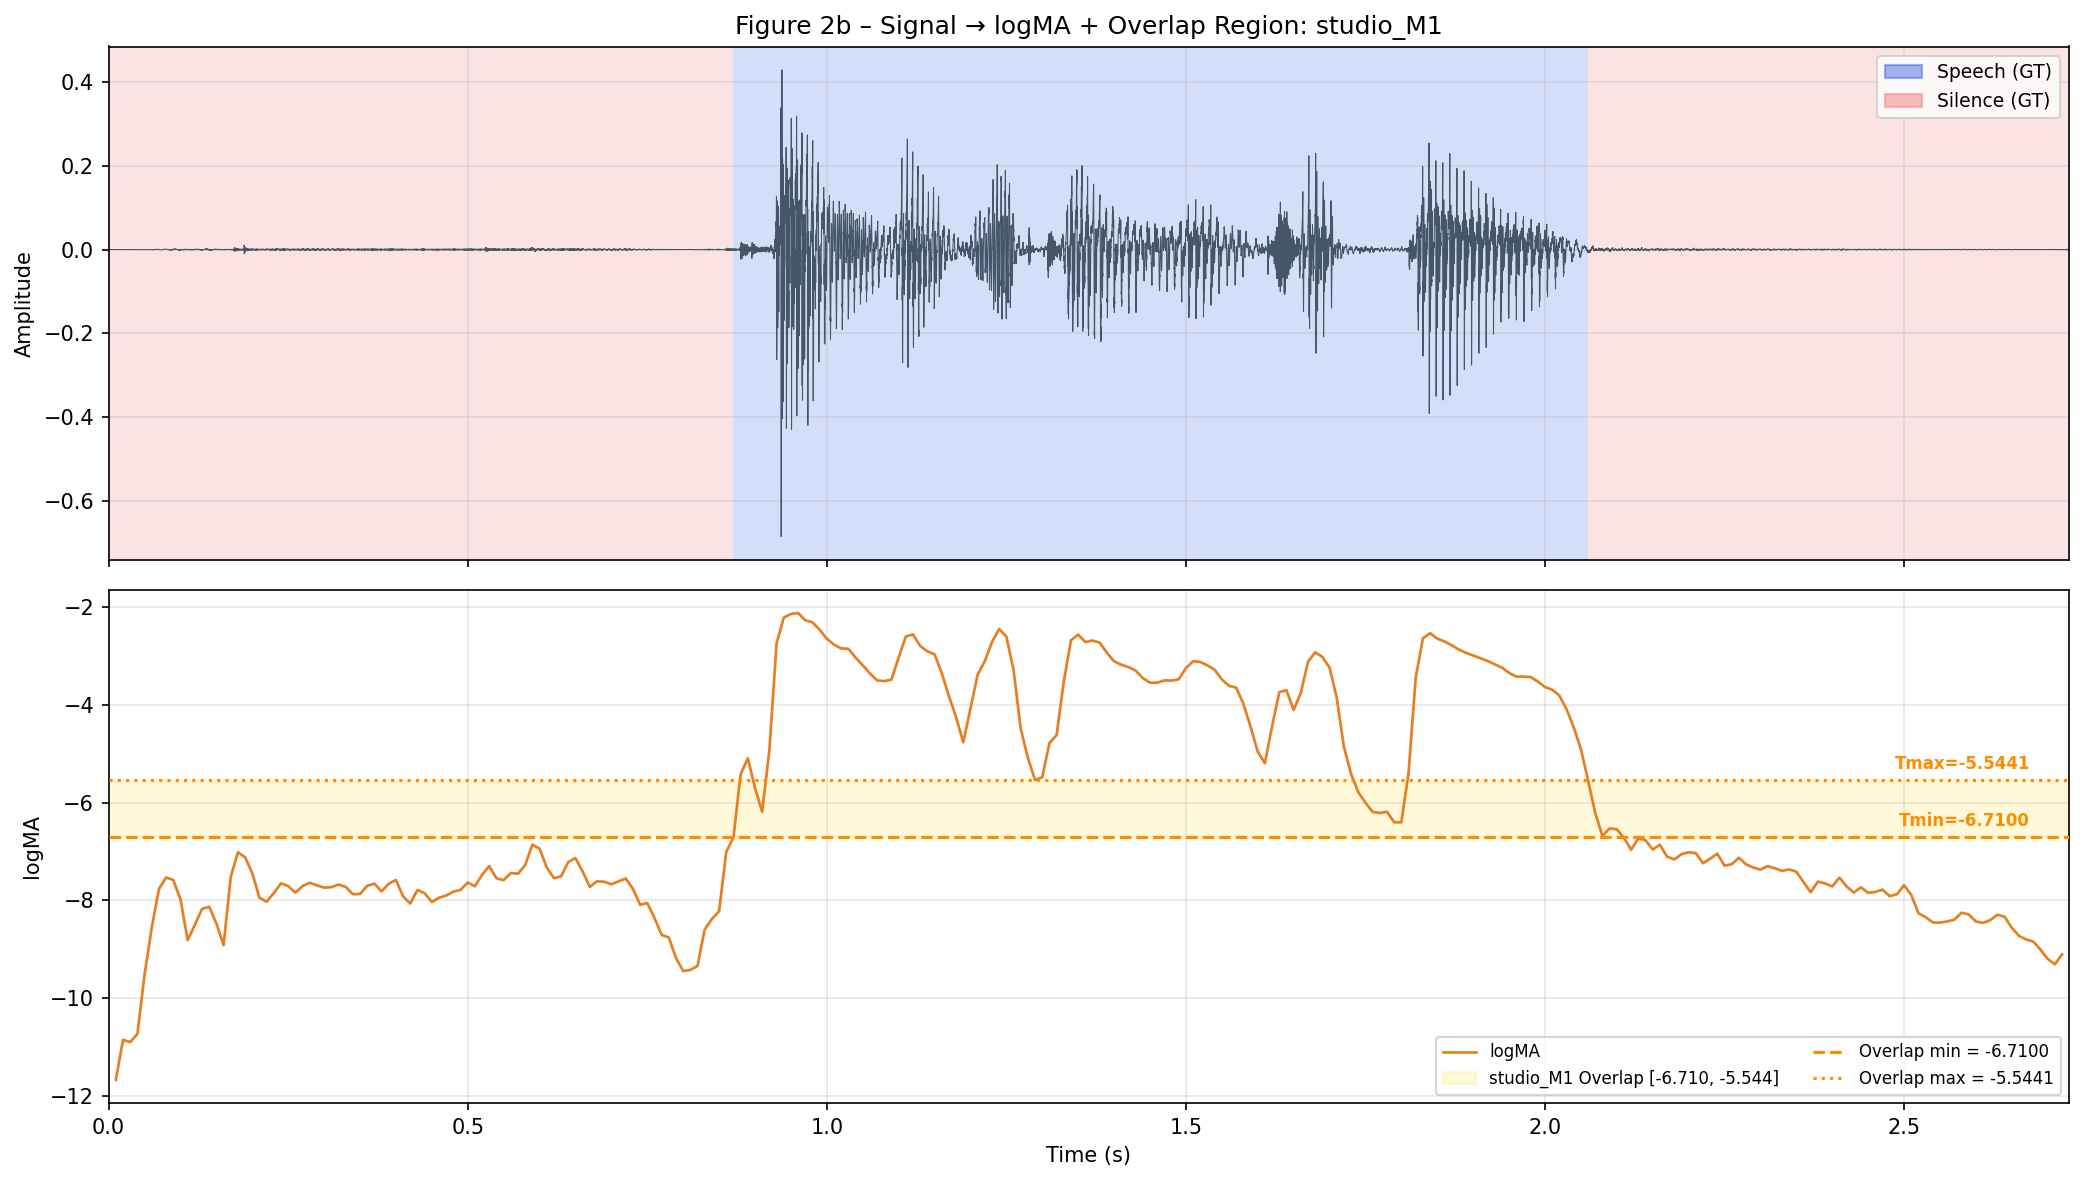

2026-09-12 12:41:41,073 [WARNING]   1 frame không thuộc đoạn lab nào (unknown)



VÙNG OVERLAP: phone_F1 -> [Tmin = -5.2199, Tmax = -4.2542]


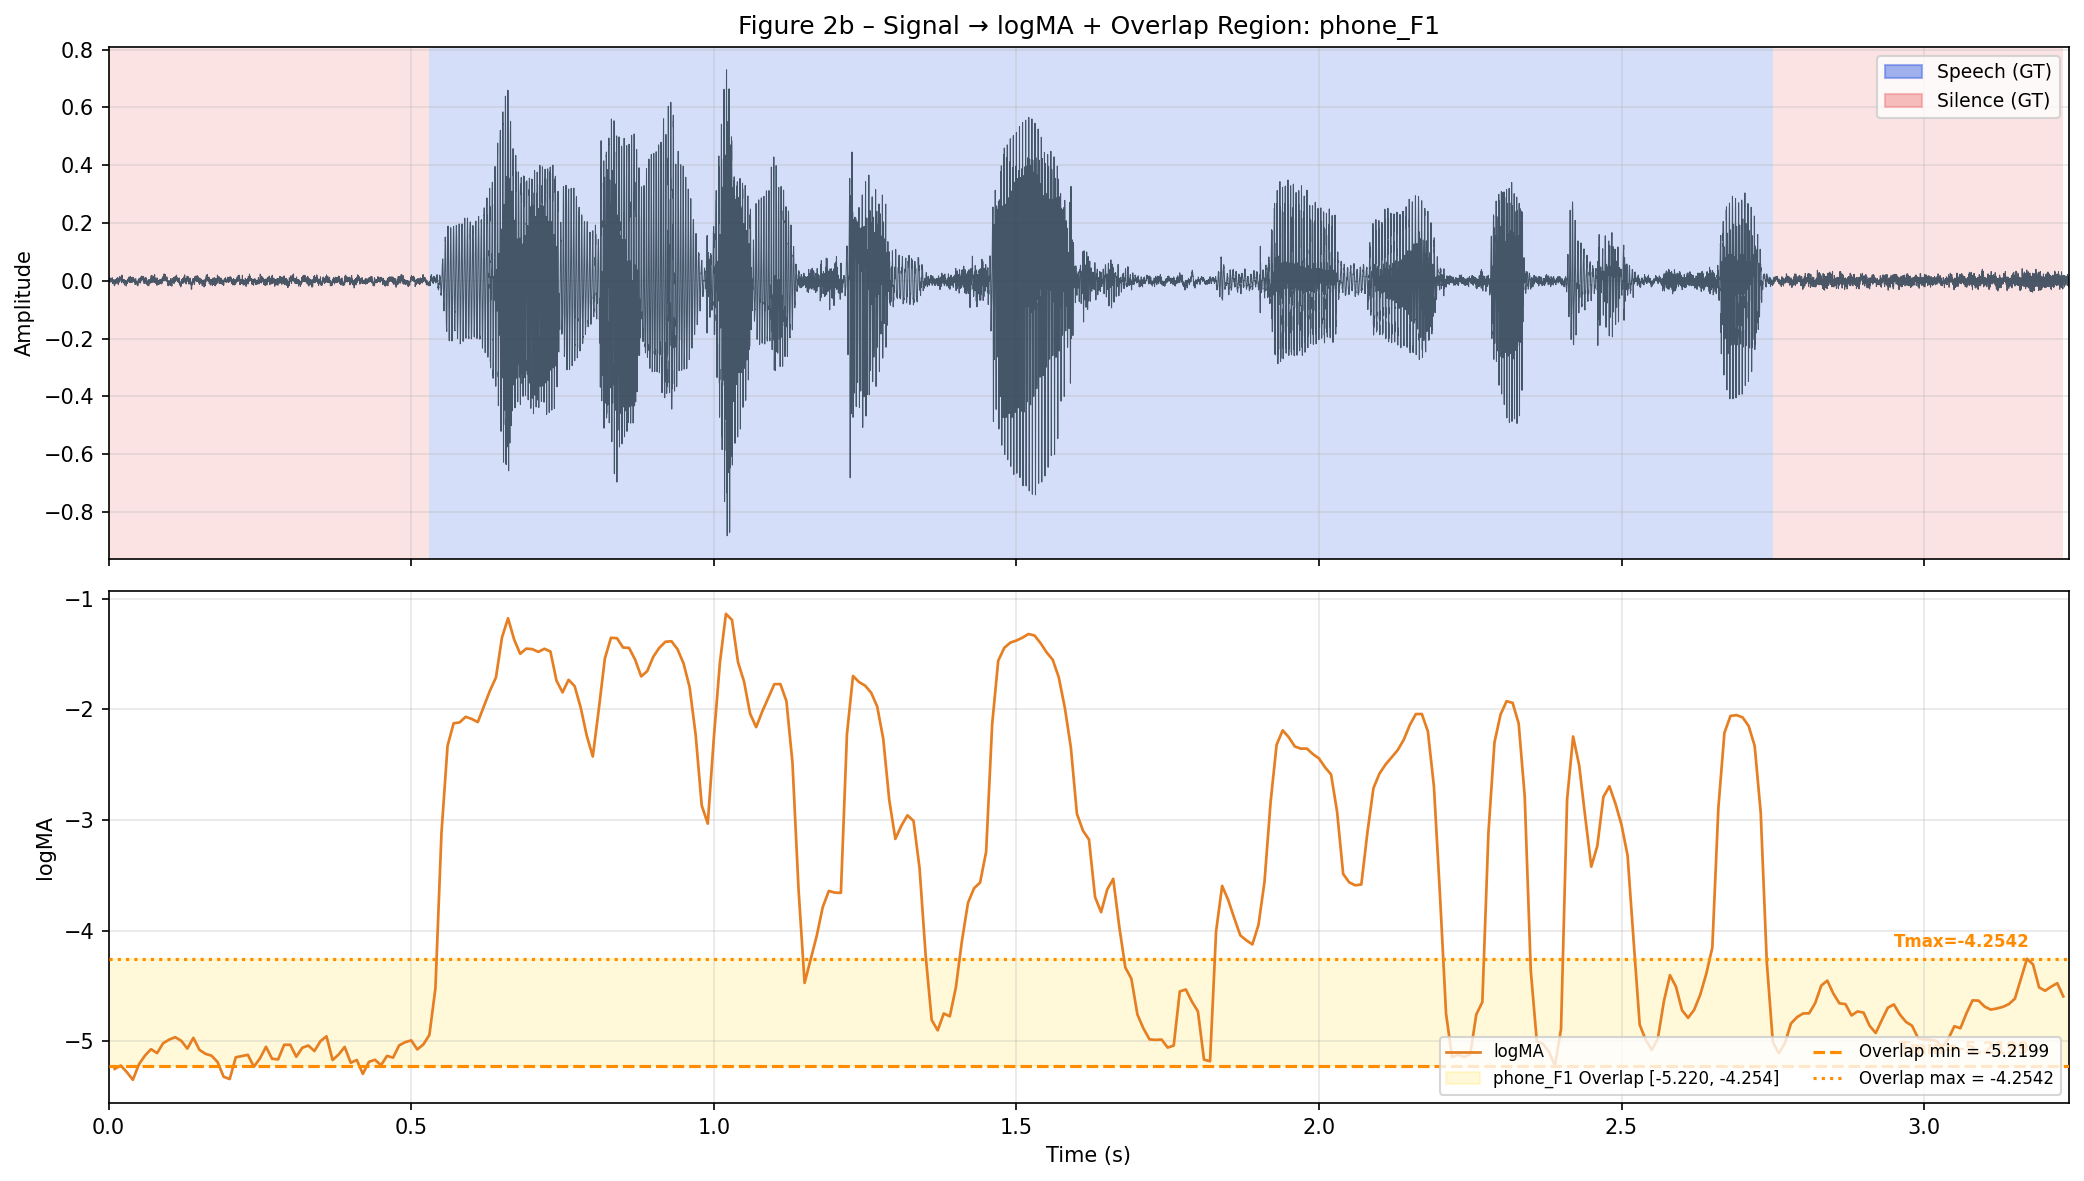

2026-09-12 12:41:41,080 [WARNING]   1 frame không thuộc đoạn lab nào (unknown)



VÙNG OVERLAP: phone_M1 -> [Tmin = -5.9857, Tmax = -4.6867]


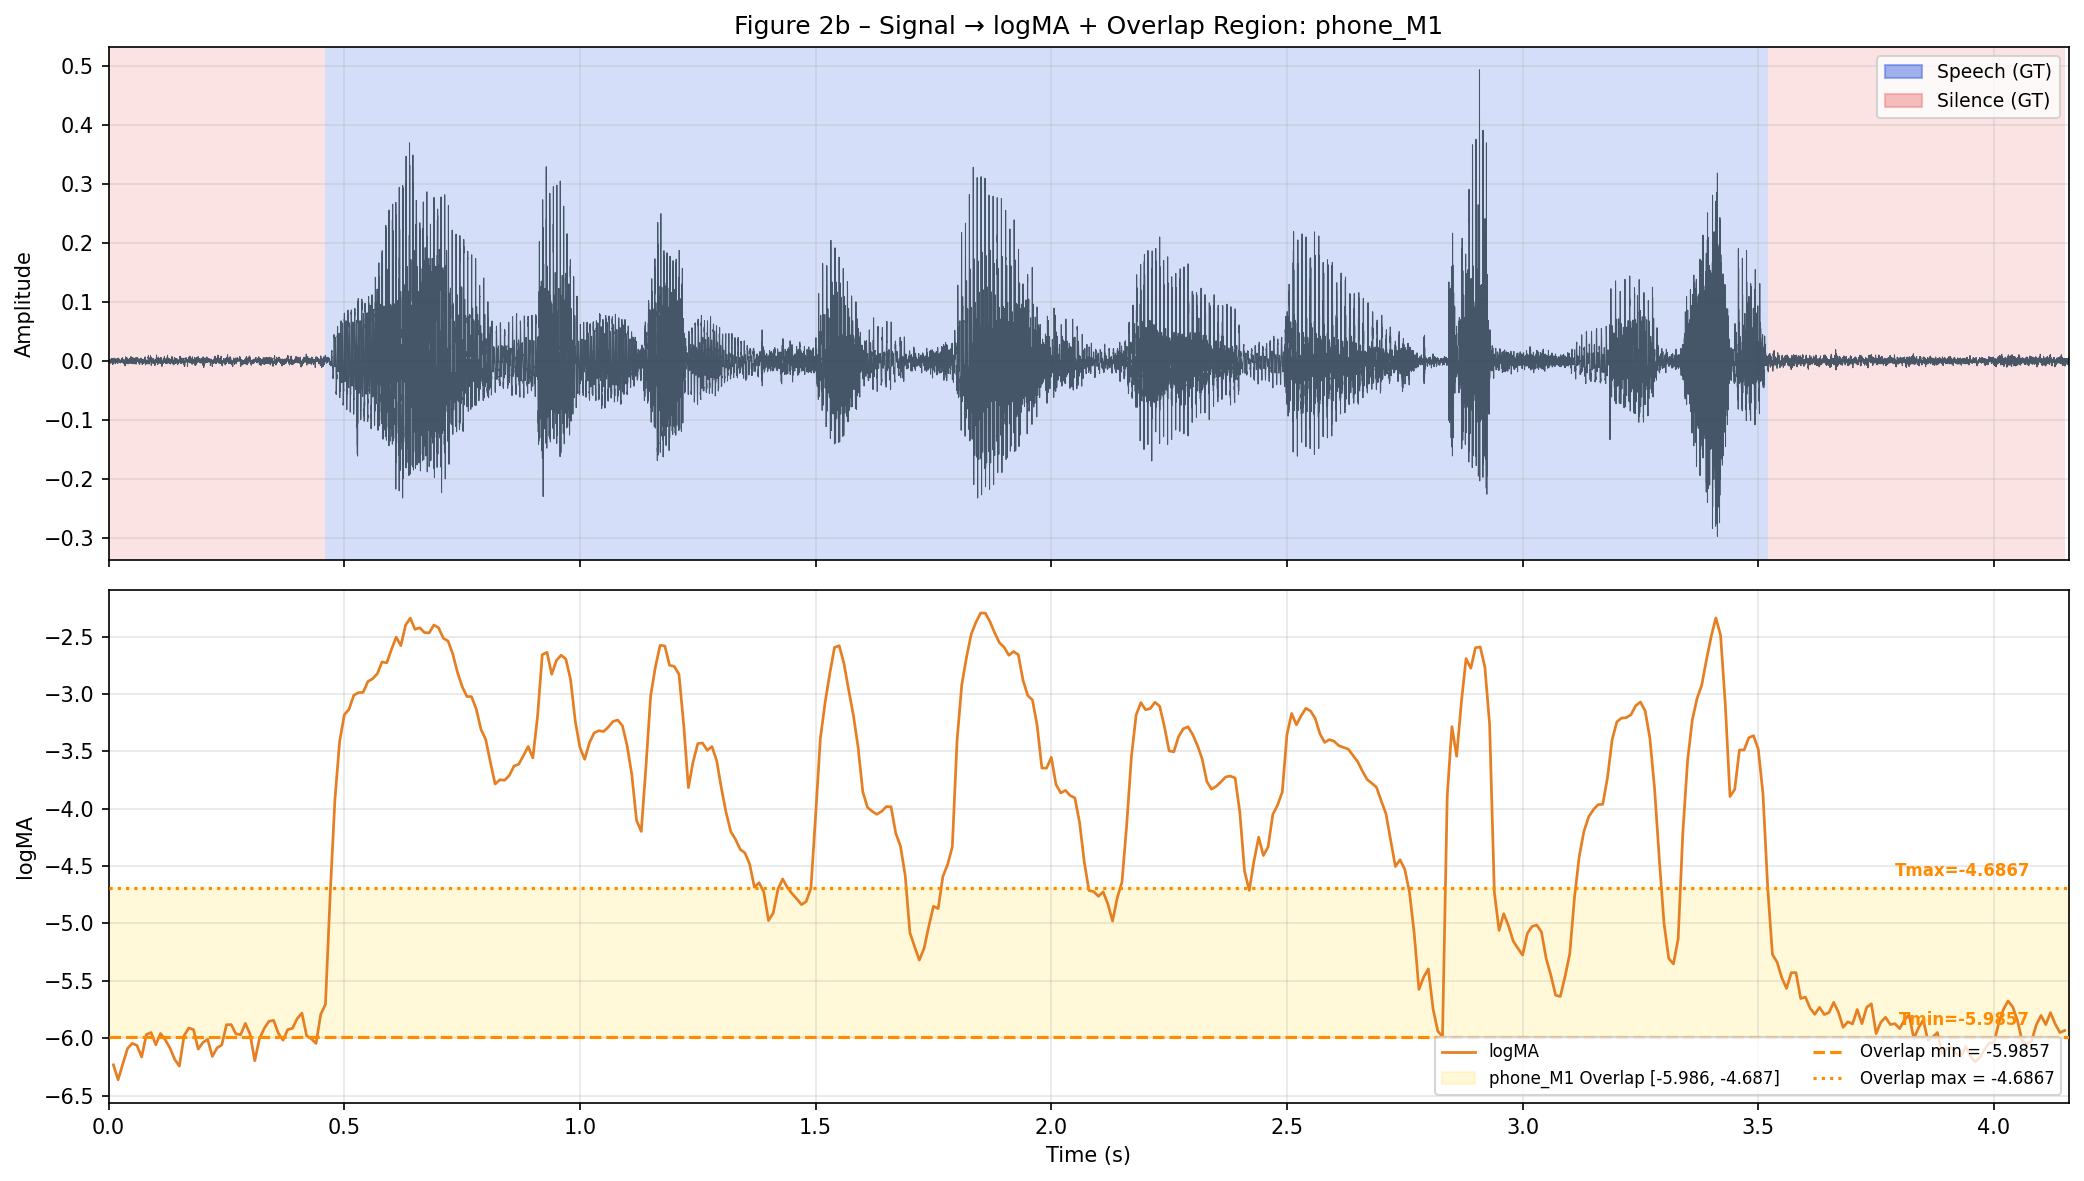

In [89]:
for fname in TRAIN_FILES:
    wav_path = os.path.join(ORIGINAL_TRAINING_DIR, f"{fname}.wav")
    lab_path = os.path.join(ORIGINAL_TRAINING_DIR, f"{fname}.lab")
    sig, sr = load_audio(wav_path)
    lab_segs = parse_lab_file(lab_path)
    fv, fc = compute_short_time_feature(sig, sr)
    lbls = assign_frame_labels(fc, lab_segs)
    ov = find_overlap_region(fv[lbls == 1], fv[lbls == 0])

    print(f"\n{'='*75}")
    print(f"VÙNG OVERLAP: {fname} -> [Tmin = {ov['overlap_min']:.4f}, Tmax = {ov['overlap_max']:.4f}]")
    print(f"{'='*75}")

    fig2b_path = os.path.join(OUTPUT_DIR, "per_file", fname, "figures", f"{fname}_fig2b_signal_to_feature_overlap.png")
    display(Image(fig2b_path))

---
### 4. Bước 4: Tiến hành Train (Binary Search Tìm Ngưỡng $T$ – 4 Files)
Thuật toán tìm kiếm nhị phân chia đôi khoảng Overlap tại mỗi vòng lặp để tìm điểm cân bằng hàm tổn thất nhầm lẫn:
$$C_{silence}(T) = \frac{1}{N_{sil}}\sum \max(\text{sil} - T, 0), \qquad C_{speech}(T) = \frac{1}{N_{spch}}\sum \max(T - \text{speech}, 0)$$
- Nếu $C_{sil} > C_{spch} \implies T$ đang quá thấp $\implies T_{min} = T$.
- Nếu $C_{sil} < C_{spch} \implies T$ đang quá cao $\implies T_{max} = T$.

Đồ thị dưới đây thể hiện sự hội tụ của thuật toán trên cả 4 file: ngưỡng $T$ tiệm cận giá trị tối ưu, các thành phần mất mát cân bằng dần và hiệu số $(C_{sil} - C_{spch})$ tiến về $0$.


HỘI TỤ BINARY SEARCH: studio_F1 | Số vòng lặp: 25 | Ngưỡng tối ưu T = -6.544352


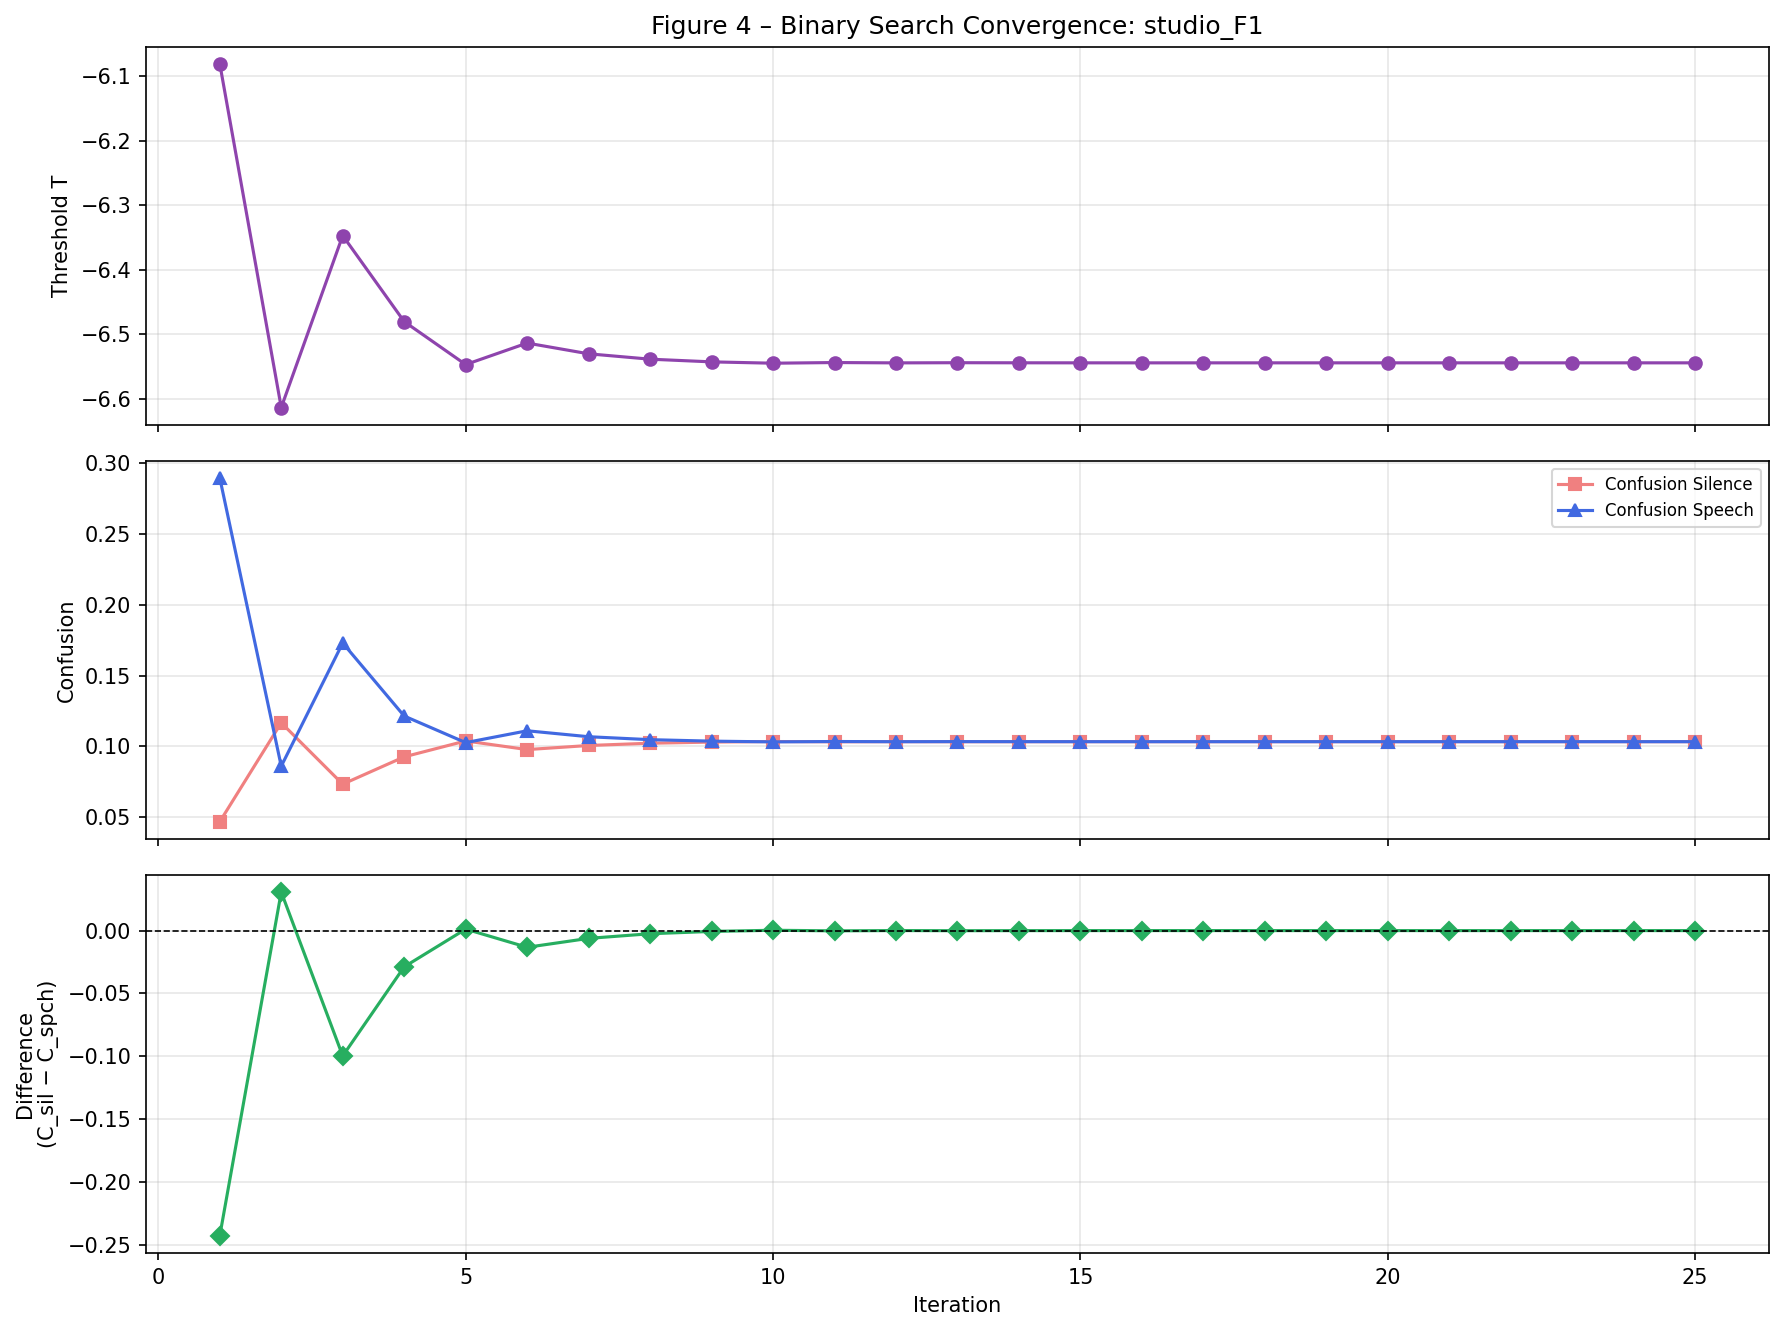


HỘI TỤ BINARY SEARCH: studio_M1 | Số vòng lặp: 29 | Ngưỡng tối ưu T = -6.153846


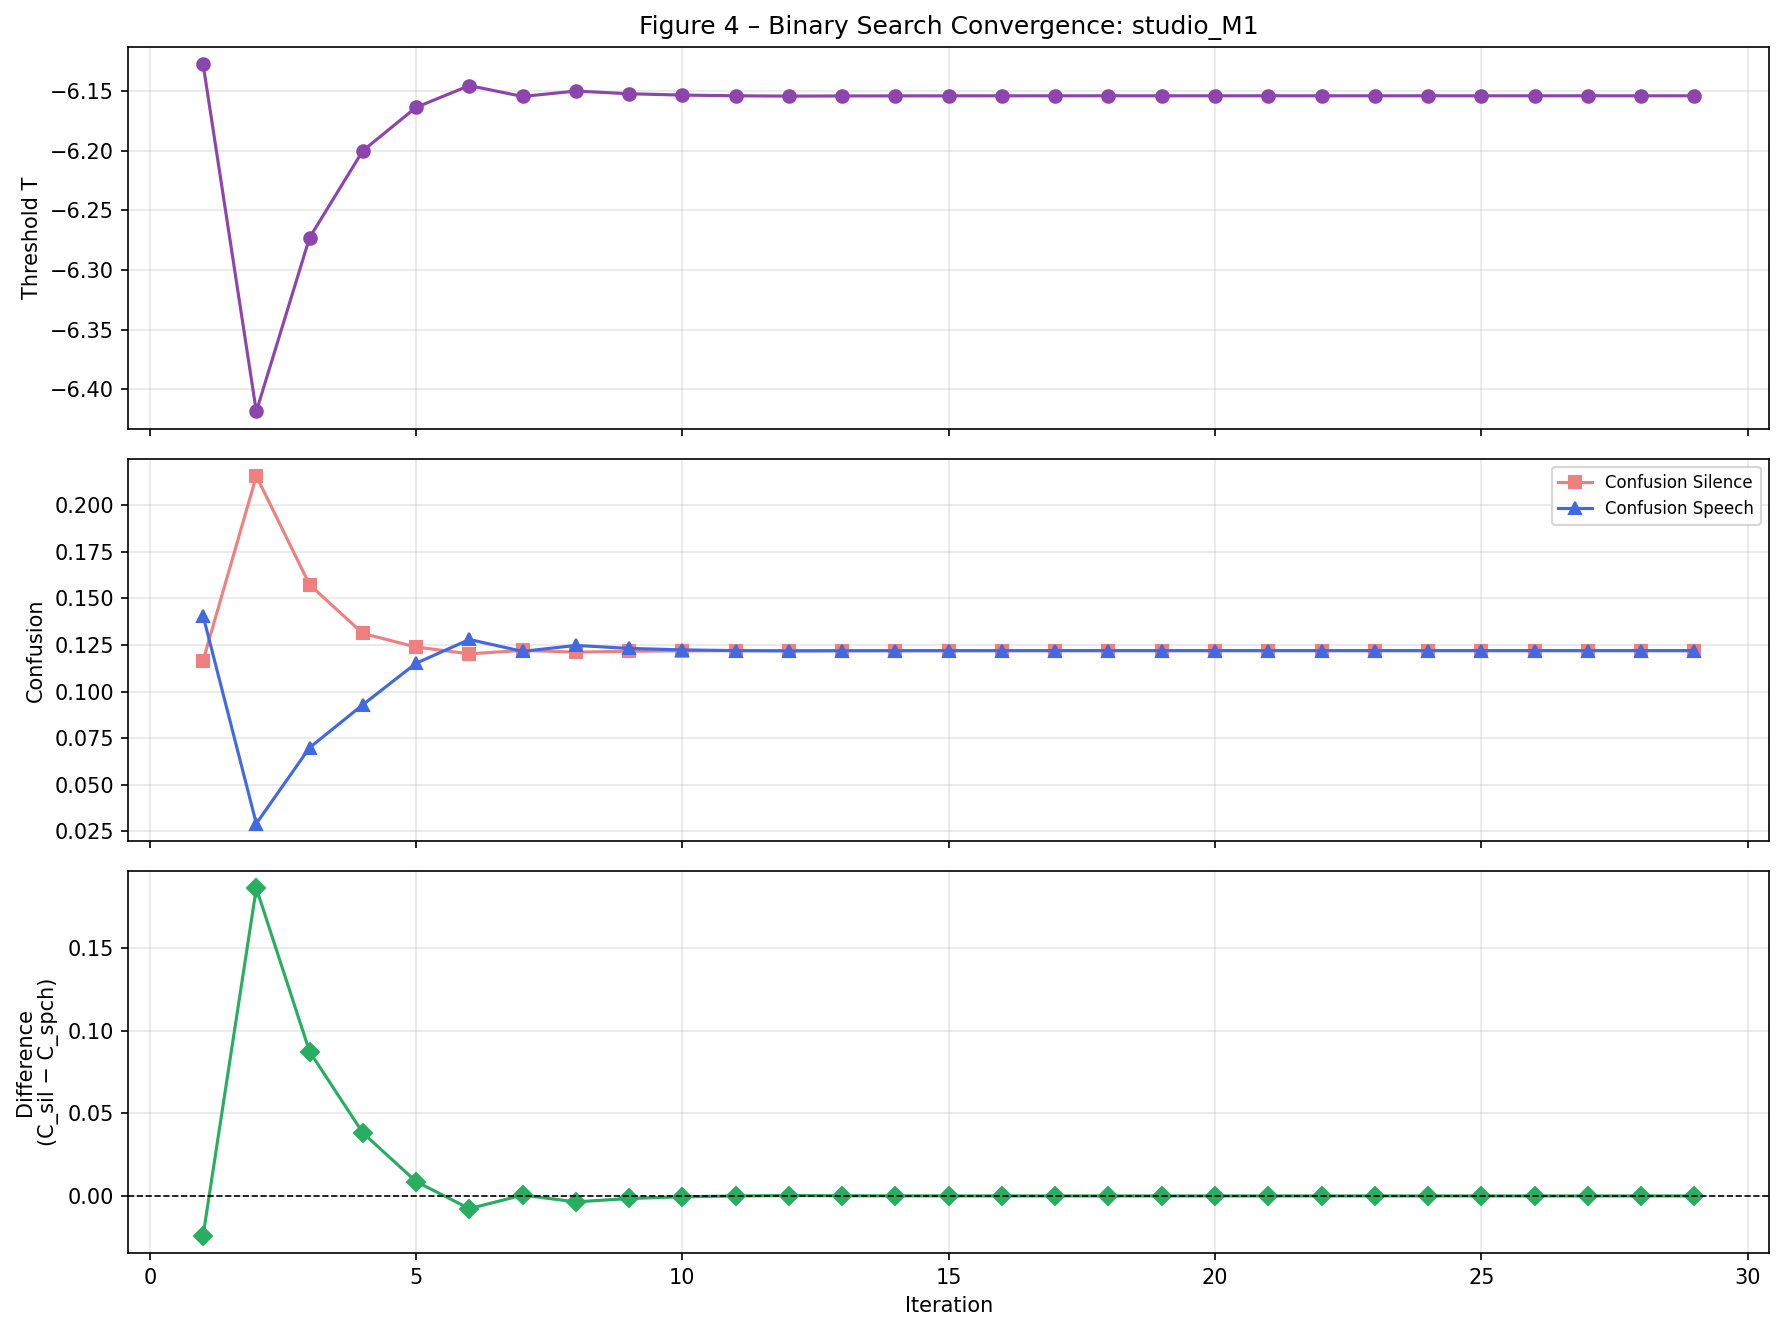


HỘI TỤ BINARY SEARCH: phone_F1 | Số vòng lặp: 29 | Ngưỡng tối ưu T = -4.858278


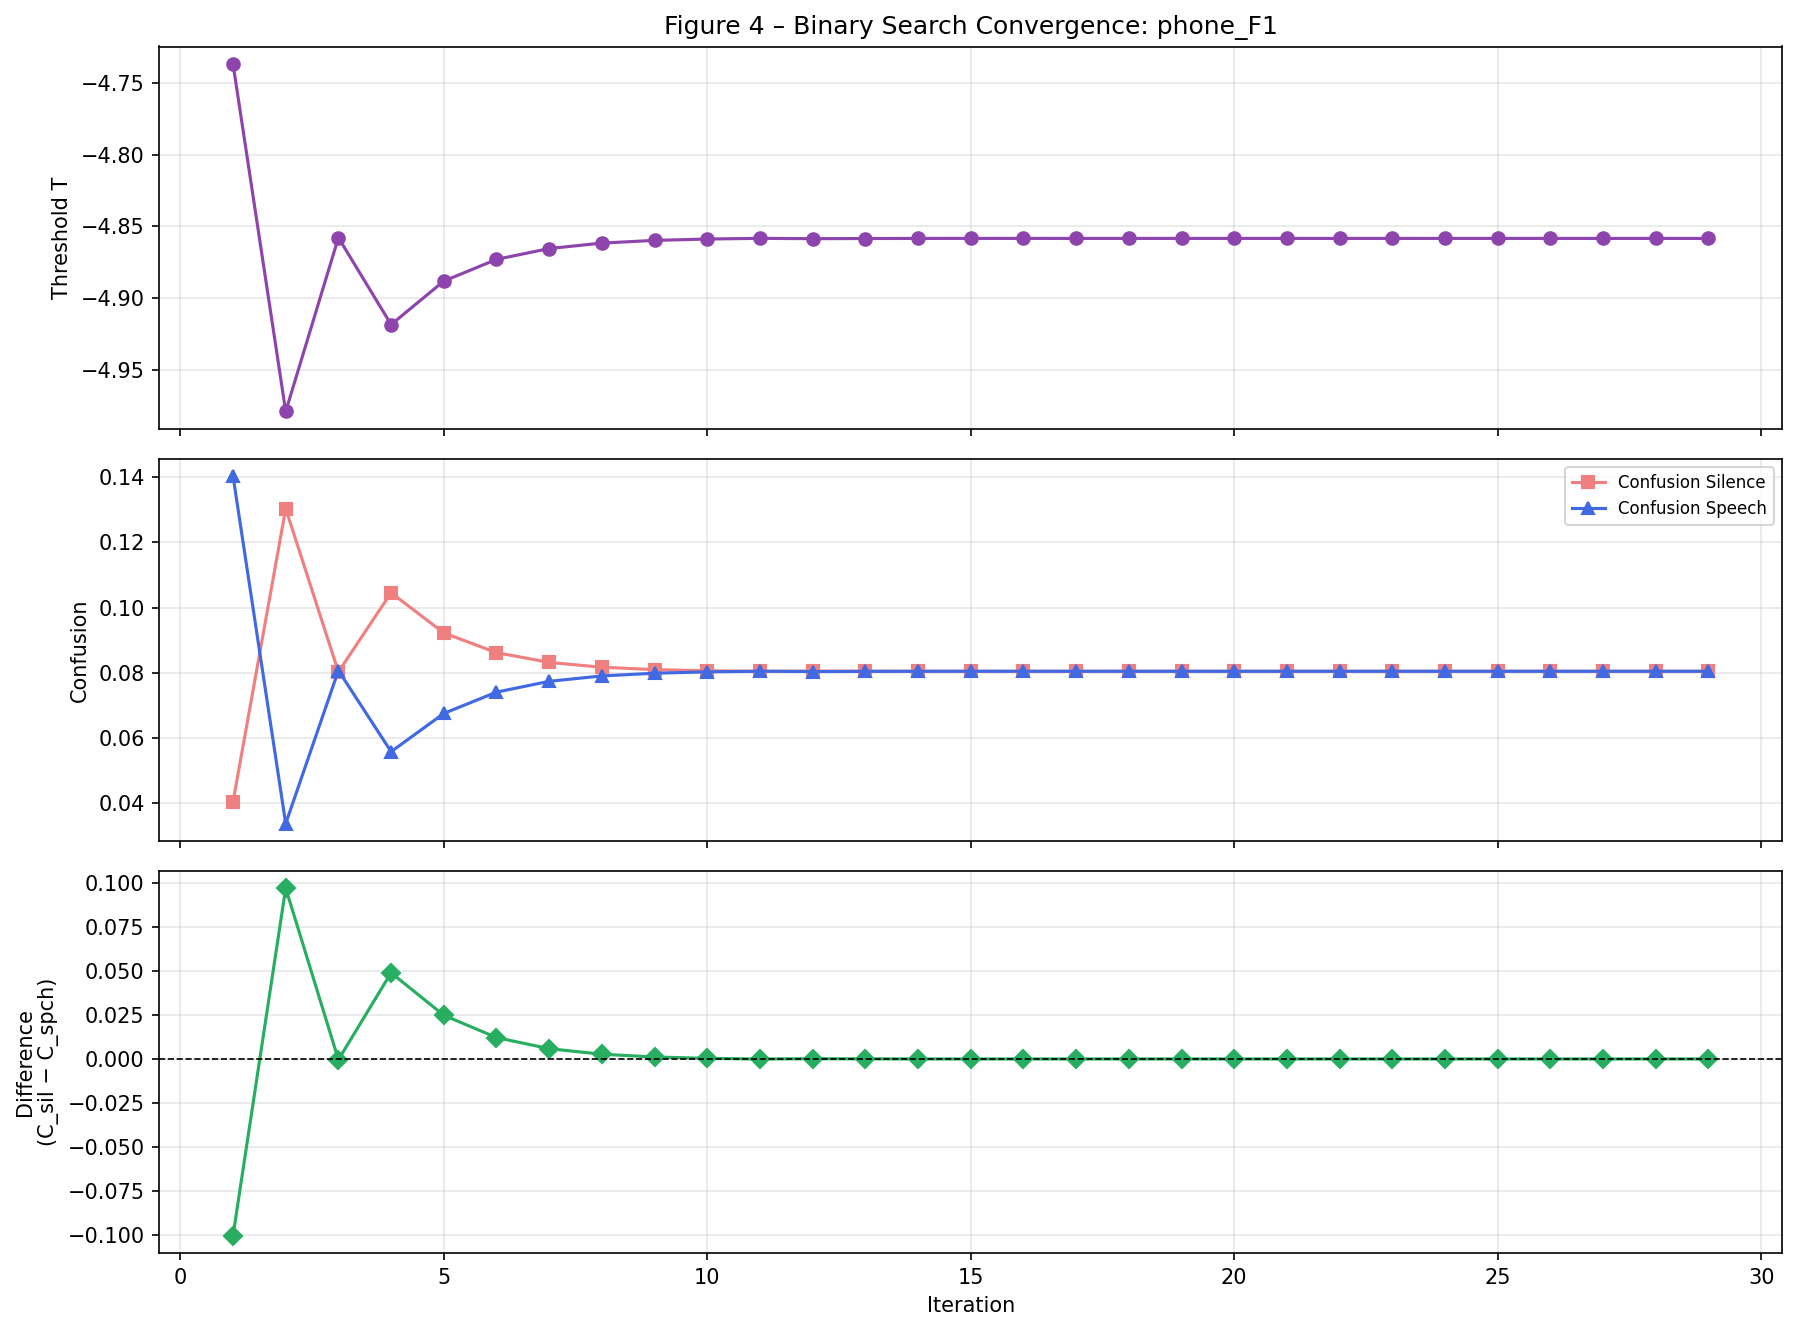


HỘI TỤ BINARY SEARCH: phone_M1 | Số vòng lặp: 27 | Ngưỡng tối ưu T = -5.547025


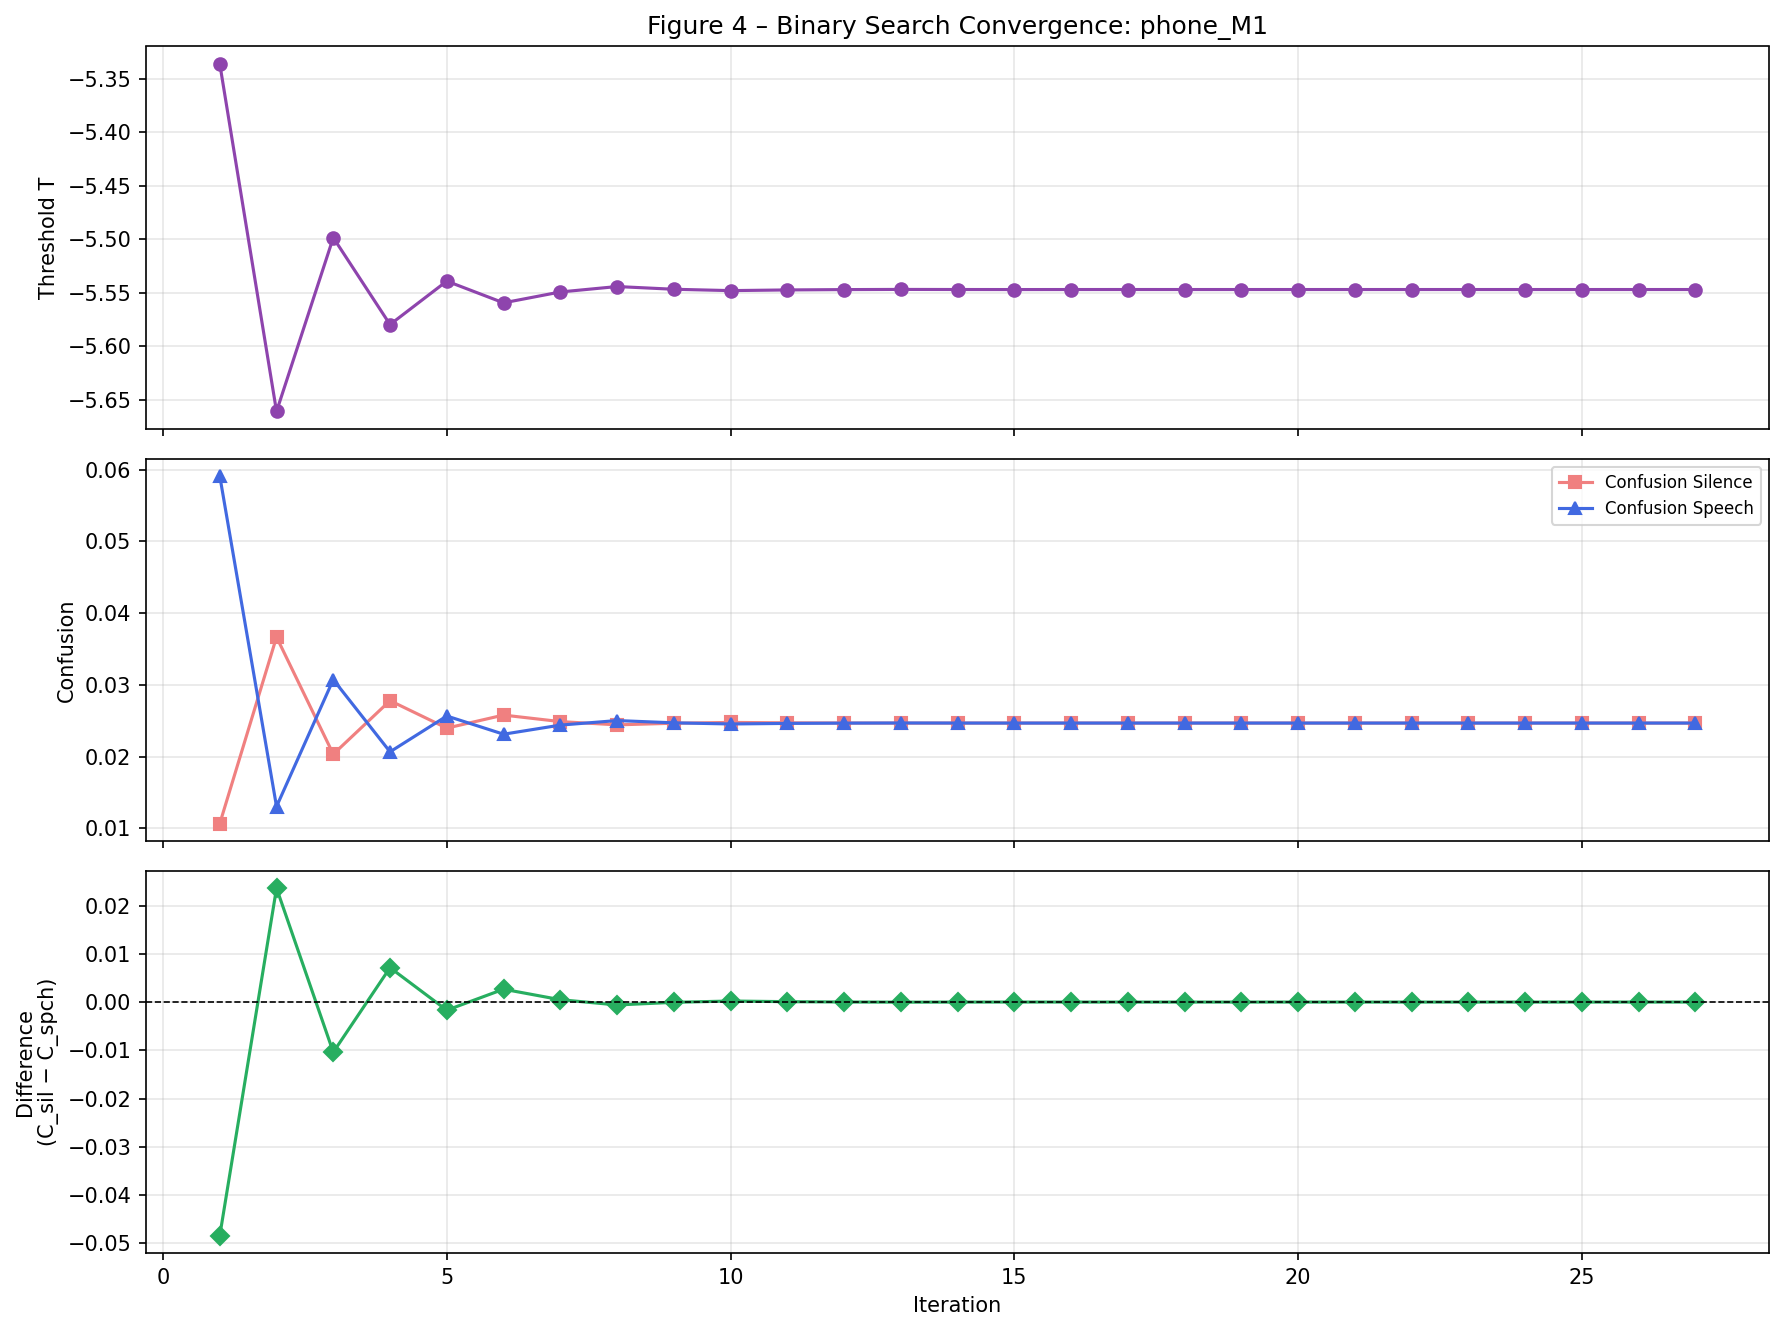

In [90]:
df_hist = pd.read_csv(os.path.join(OUTPUT_DIR, "training", "binary_search_history.csv"))

for fname in TRAIN_FILES:
    last_step = df_hist[df_hist["source"] == fname].iloc[-1]
    n_iters = int(last_step["iteration"])
    opt_t = float(last_step["threshold"])
    print(f"\n{'='*75}")
    print(f"HỘI TỤ BINARY SEARCH: {fname} | Số vòng lặp: {n_iters} | Ngưỡng tối ưu T = {opt_t:.6f}")
    print(f"{'='*75}")
    fig_path = os.path.join(OUTPUT_DIR, "per_file", fname, "figures", f"{fname}_fig4_binary_search.png")
    display(Image(fig_path))


---
### 5. Bước 5: Hậu Xử Lý & Lọc Khoảng Lặng Ngắn $< 300\text{ ms}$ (Before & After Filter – 4 Files)
- **Cơ chế:** sau khi so sánh từng khung với ngưỡng $T$ ($\text{logMA} \ge T \implies \text{Speech}$, ngược lại là $\text{Silence}$), các khung cùng nhãn liên tiếp được gộp thành các đoạn (Segment).
- **Vấn đề phân đoạn thô (Before Filter):** những khoảng nén khí trước âm tắc hoặc ngắt hơi ngắn tạo ra các đoạn silence giả kéo dài $50-200\text{ ms}$.
- **Hậu xử lý (After Filter):** toàn bộ các đoạn silence $< 300\text{ ms}$ được phát hiện và tự động gộp vào đoạn tiếng nói liền kề.

Đồ thị **Figure 6** dưới đây so sánh trực quan cấu trúc phân đoạn qua 3 tầng:
1. **Tầng 1 (trên cùng):** ranh giới chuẩn Ground Truth (`.lab`).
2. **Tầng 2 (giữa):** phân đoạn dự đoán THÔ trước khi lọc (nhiều đoạn silence vụn màu hồng bị ngắt quãng).
3. **Tầng 3 (dưới cùng):** phân đoạn ĐÃ LỌC, loại bỏ các khoảng lặng giả, khớp tốt hơn với Ground Truth.


SO SÁNH TRƯỚC VÀ SAU KHI LỌC SILENCE < 300MS (FIGURE 6): studio_F1


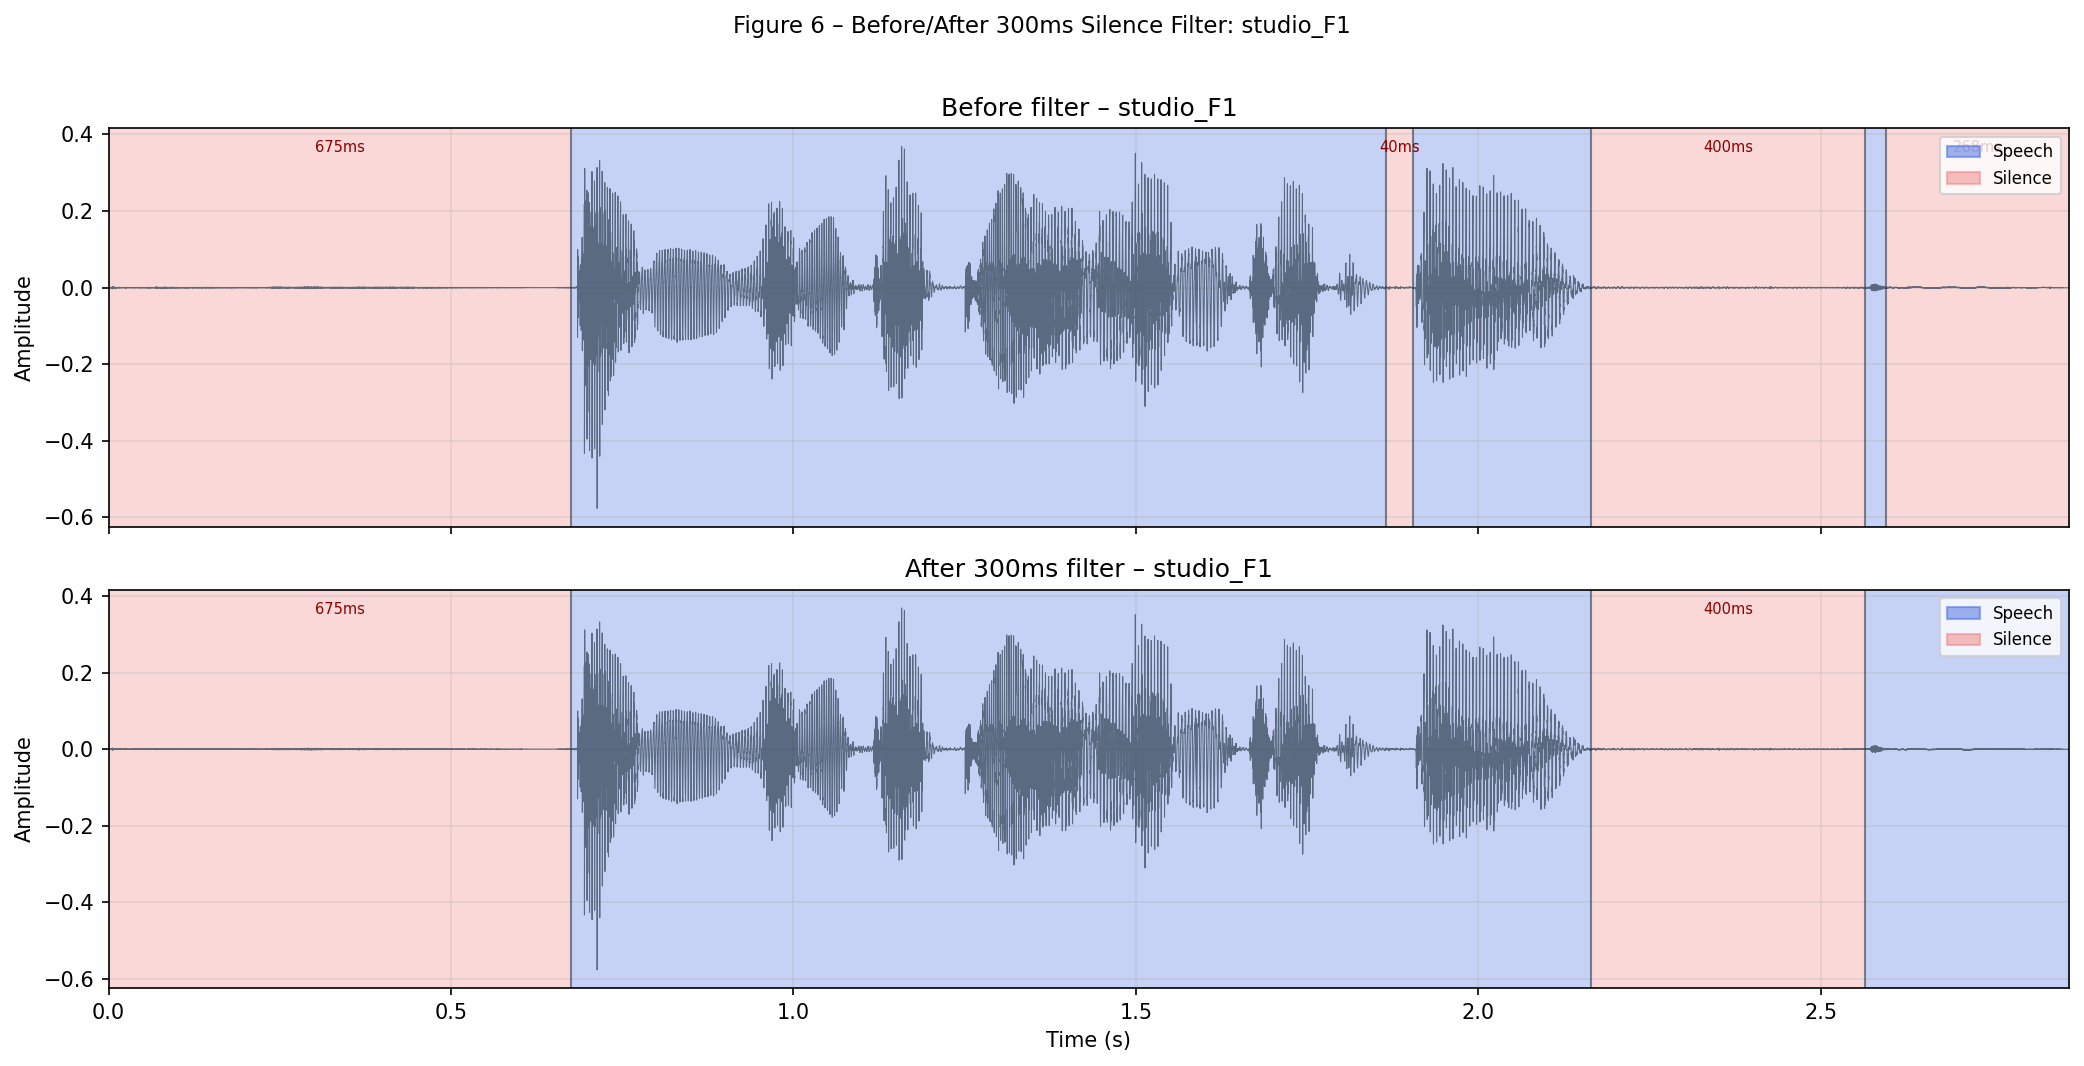


SO SÁNH TRƯỚC VÀ SAU KHI LỌC SILENCE < 300MS (FIGURE 6): studio_M1


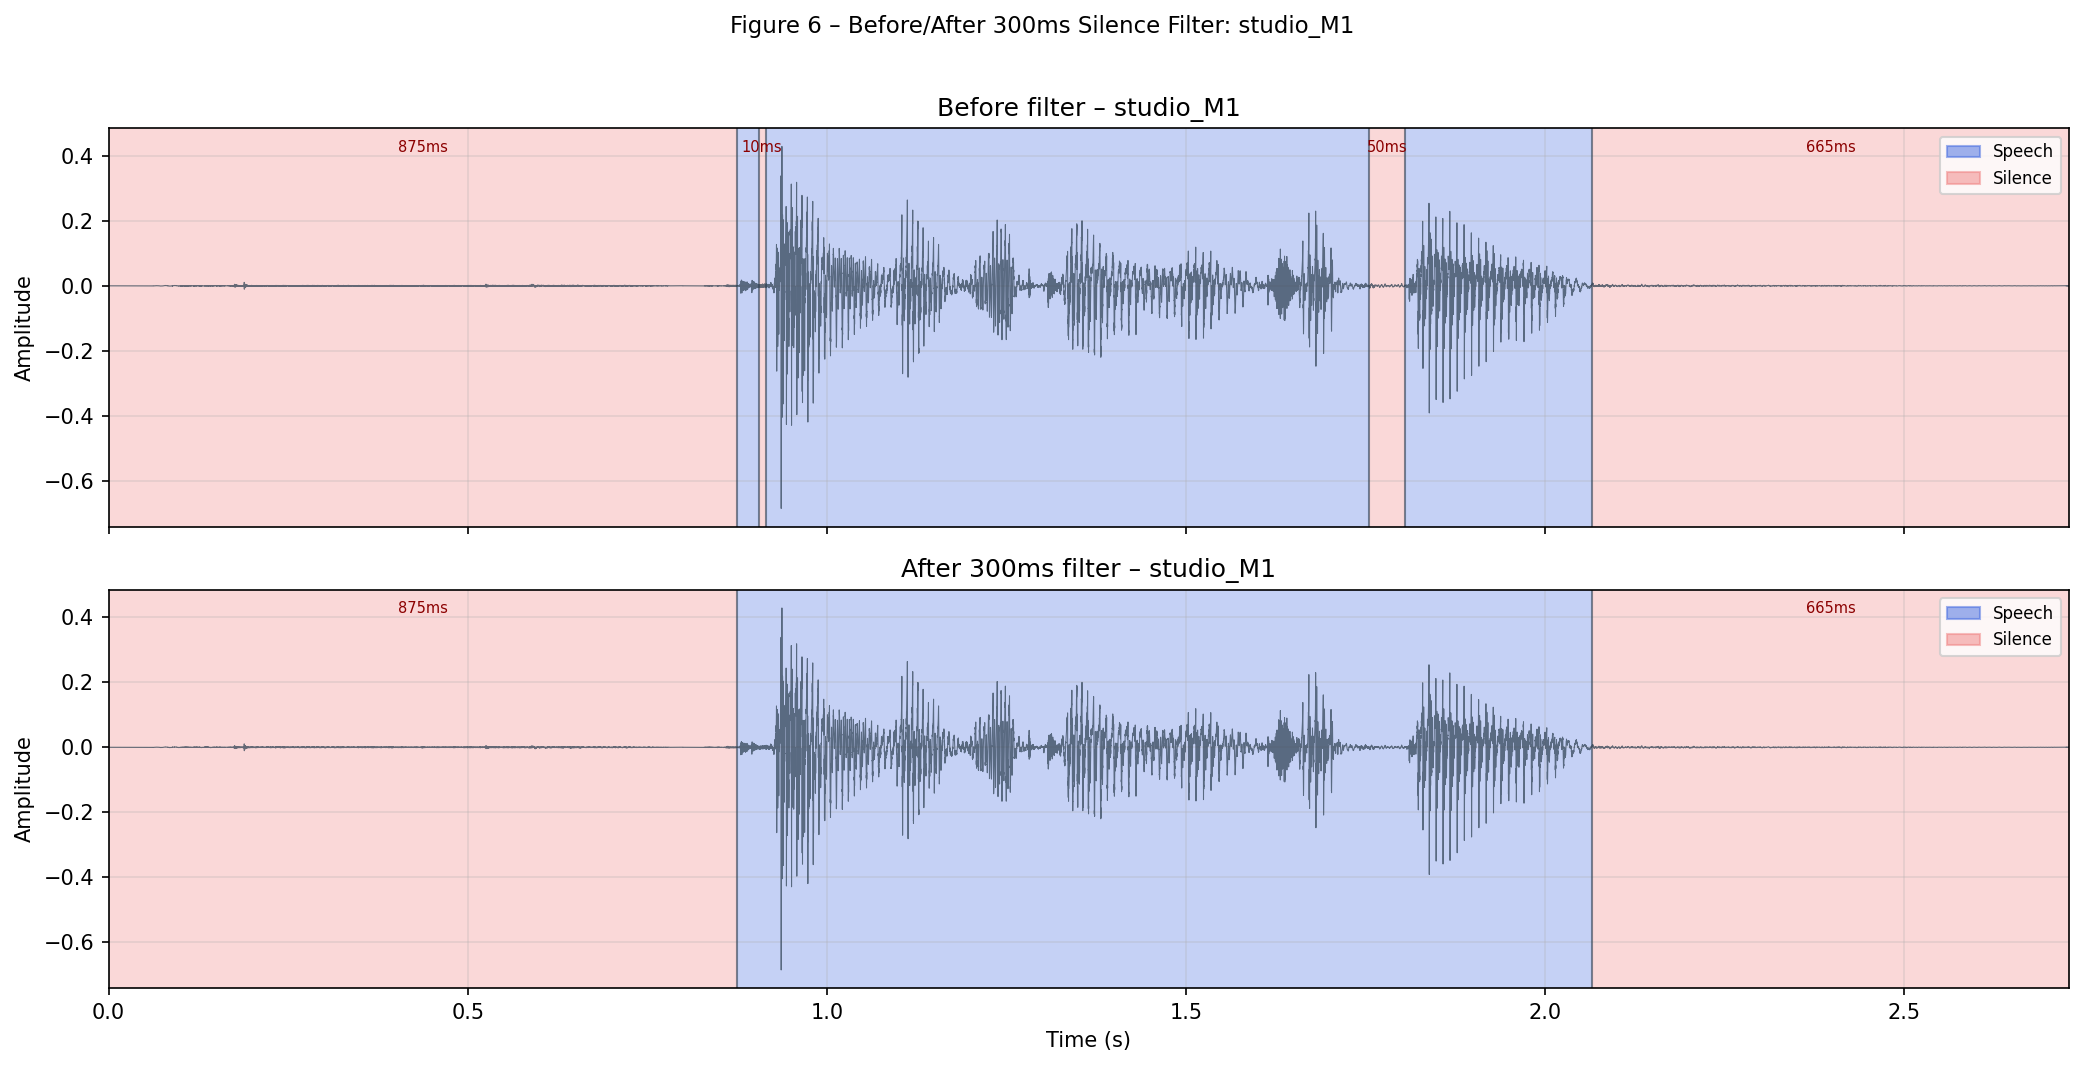


SO SÁNH TRƯỚC VÀ SAU KHI LỌC SILENCE < 300MS (FIGURE 6): phone_F1


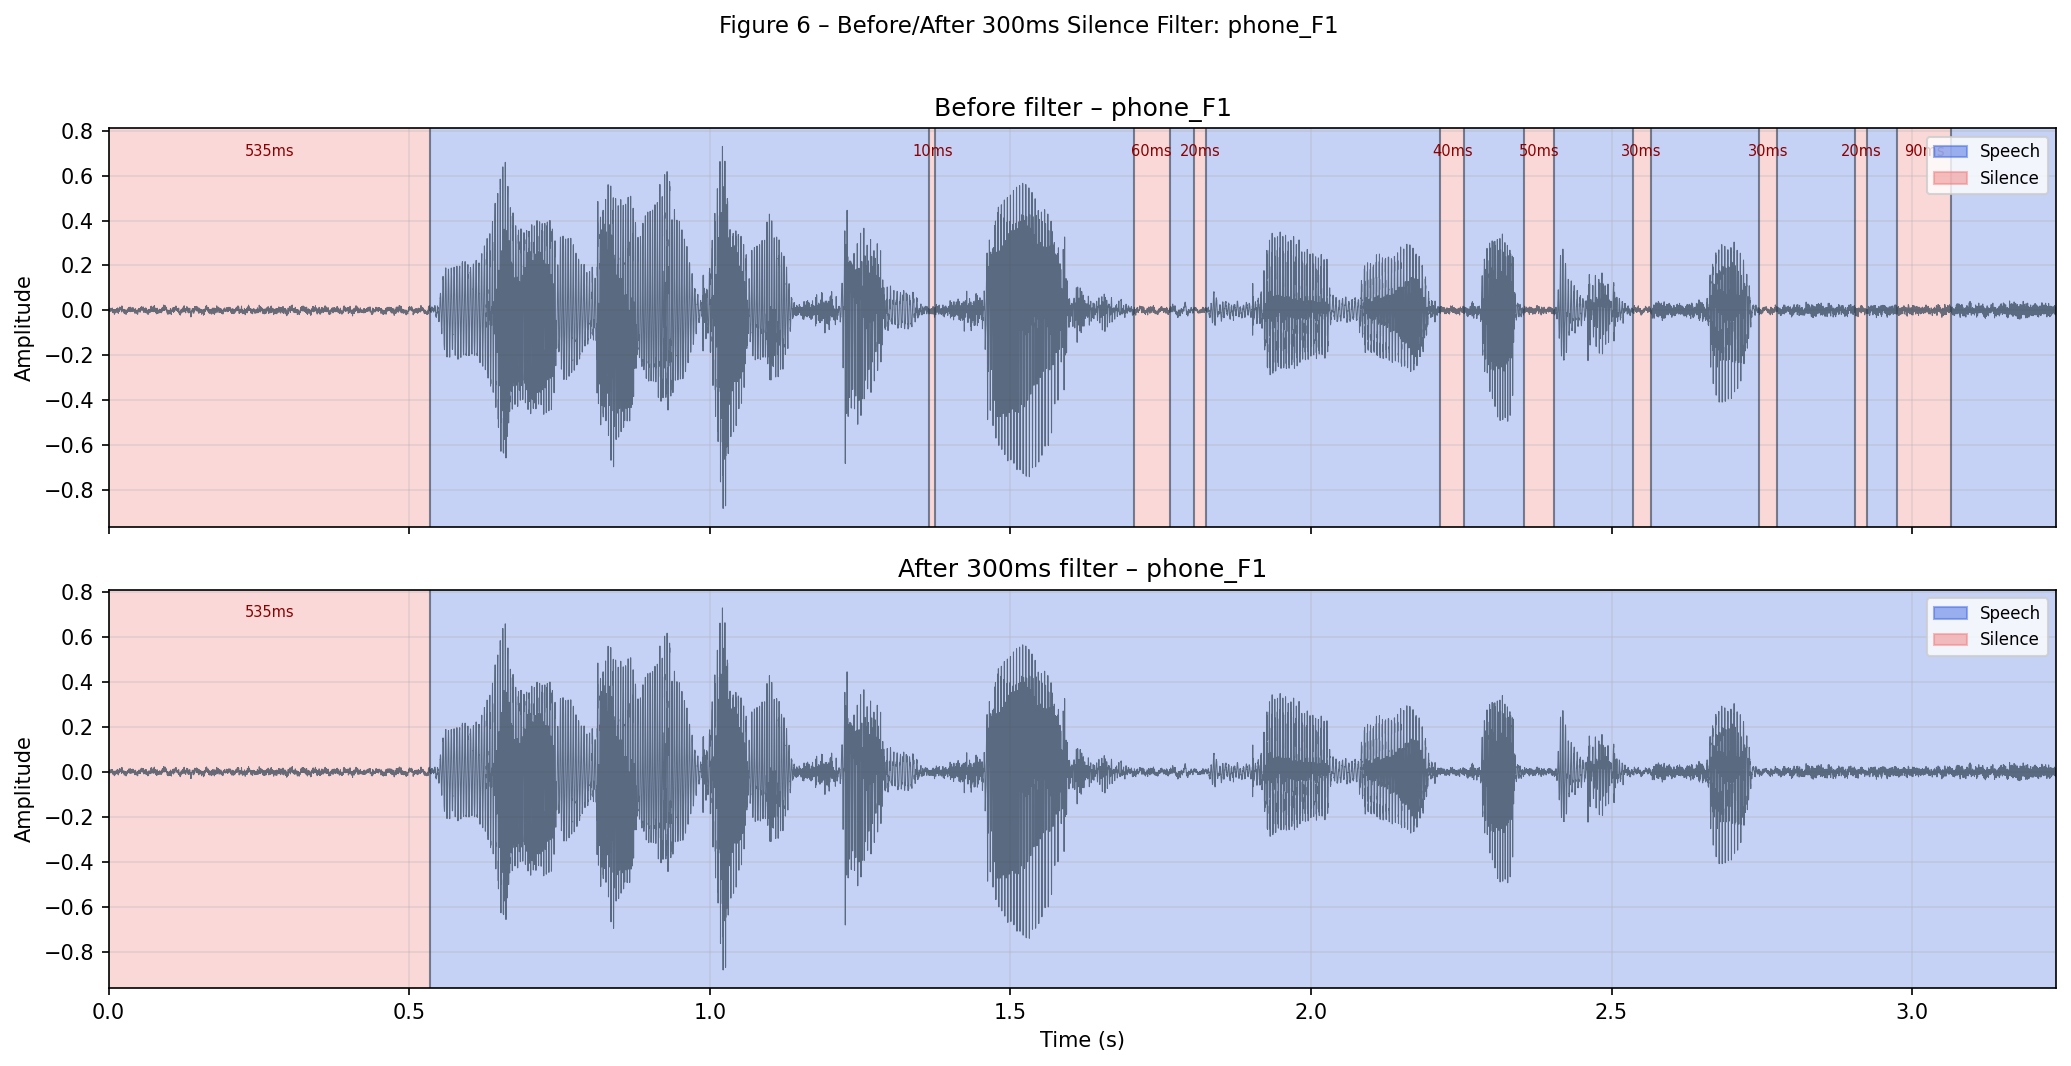


SO SÁNH TRƯỚC VÀ SAU KHI LỌC SILENCE < 300MS (FIGURE 6): phone_M1


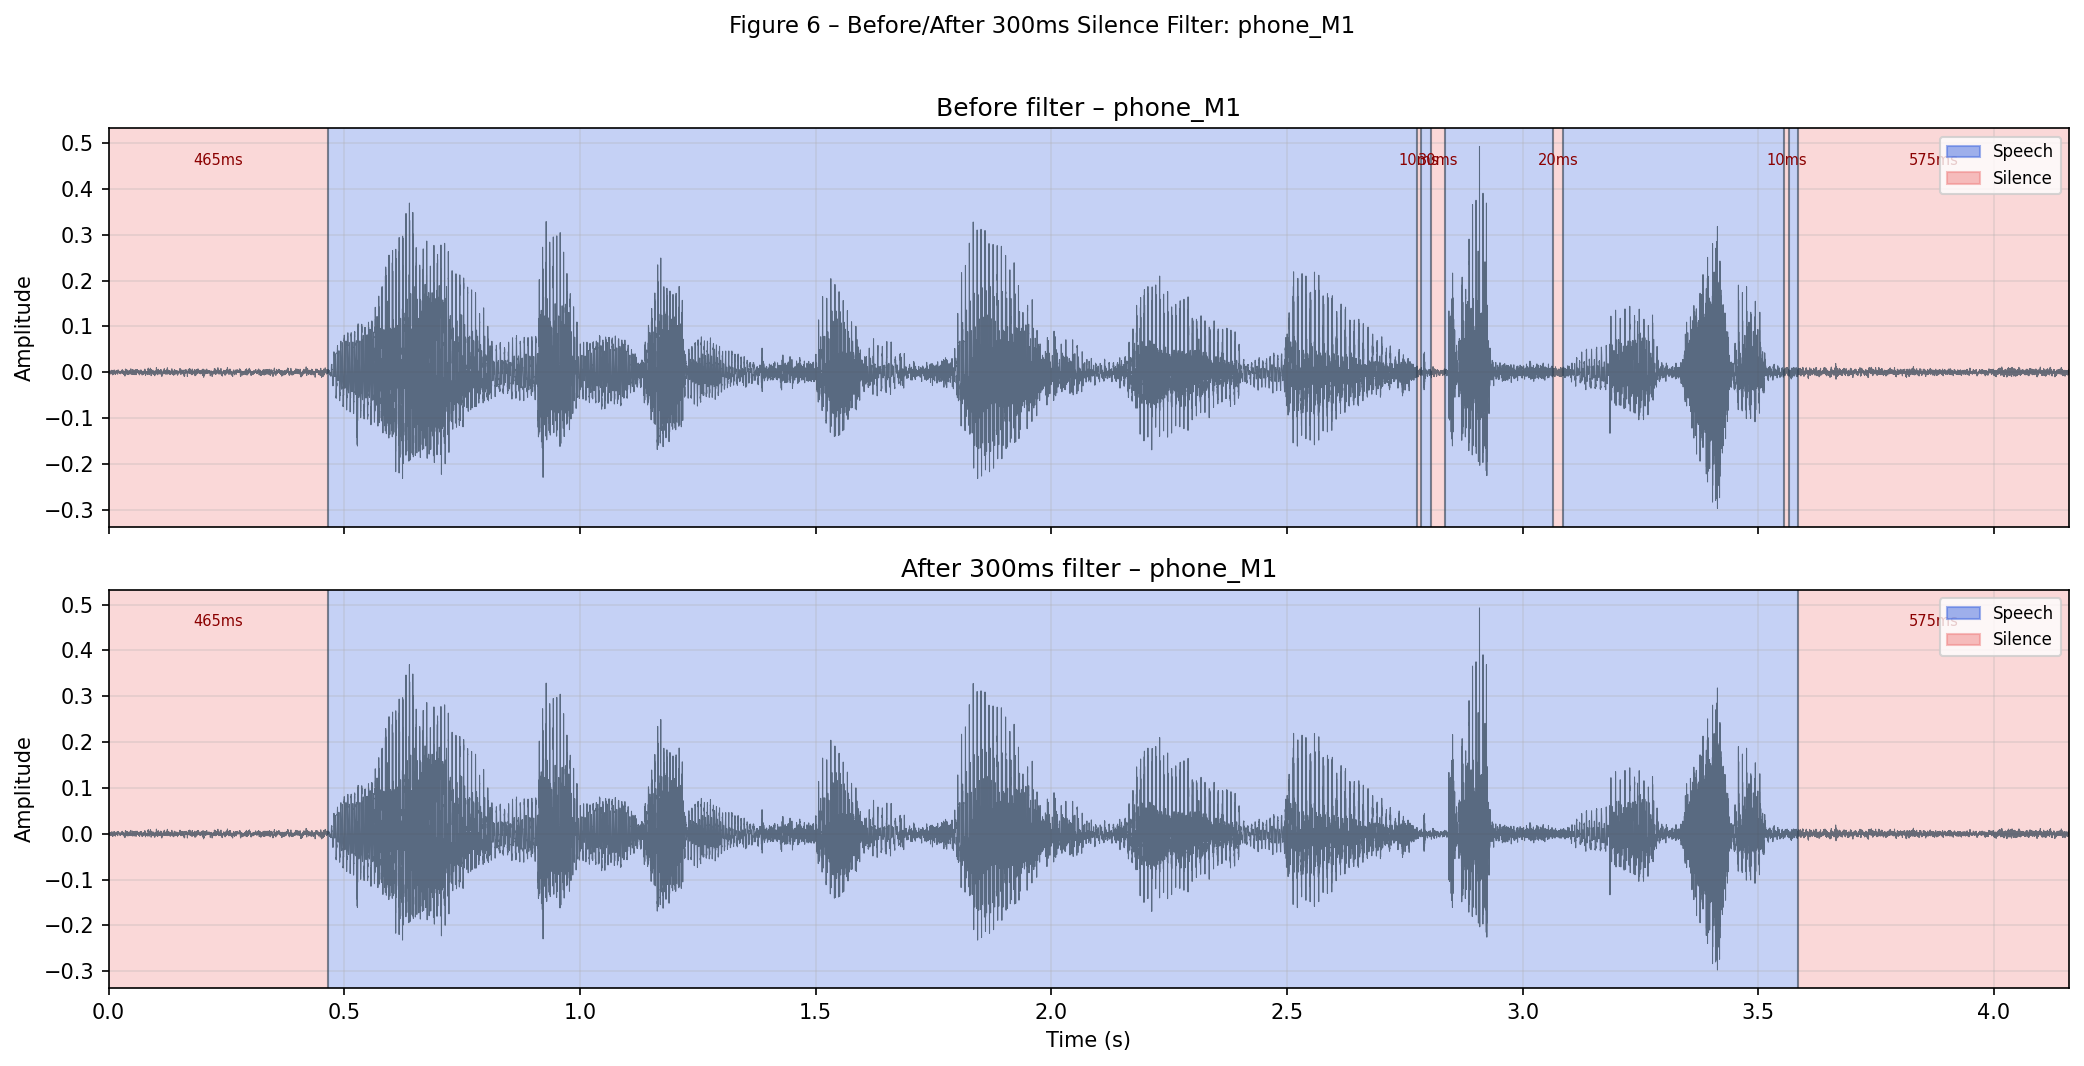

In [91]:
for fname in TRAIN_FILES:
    print(f"\n{'='*75}")
    print(f"SO SÁNH TRƯỚC VÀ SAU KHI LỌC SILENCE < 300MS (FIGURE 6): {fname}")
    print(f"{'='*75}")
    fig_path = os.path.join(OUTPUT_DIR, "per_file", fname, "figures", f"{fname}_fig6_before_after_filter.png")
    display(Image(fig_path))

---
### 6. Bước 6: Kết quả Huấn luyện Per-file (Cả 4 File Huấn luyện)
Khi mỗi file được huấn luyện một ngưỡng riêng thích ứng với môi trường thu âm của chính nó, kỳ vọng
là điểm số sẽ rất cao (ngưỡng "biết trước" đặc điểm nhiễu của file). Bảng bên dưới đọc trực tiếp từ
`threshold_summary_perfile.csv` — **đã bổ sung 3 cột `precision/recall/f1`** vốn bị thiếu trong bản
`io_utils.py` gốc (xem mục Changelog).

In [92]:
# Đọc và hiển thị bảng tóm tắt kết quả Per-file
df_pf = pd.read_csv(os.path.join(OUTPUT_DIR, "training", "threshold_summary_perfile.csv"))
table_pf = df_pf[["filename", "per_file_threshold", "precision", "recall", "f1", "mae_ms", "rmse_ms"]].copy()
table_pf.columns = ["Tên File", "Ngưỡng T", "Precision", "Recall", "F1-Score", "MAE (ms)", "RMSE (ms)"]
display(table_pf.style.format({
    "Ngưỡng T": "{:.4f}", "Precision": "{:.2f}", "Recall": "{:.2f}",
    "F1-Score": "{:.2f}", "MAE (ms)": "{:.1f}", "RMSE (ms)": "{:.1f}",
}))

,Tên File,Ngưỡng T,Precision,Recall,F1-Score,MAE (ms),RMSE (ms)
0,phone_F1,-4.8583,1.00,0.50,0.67,5.0,5.0
1,phone_M1,-5.5470,1.00,1.00,1.00,35.0,46.1
2,studio_F1,-6.5444,0.67,1.00,0.80,10.0,11.2
3,studio_M1,-6.1538,1.00,1.00,1.00,5.0,5.0


#### Hiển thị Trực quan Kết quả Phân đoạn của Cả 4 File Huấn luyện (Figure 5 – Per-file):
- **Đường nét đứt màu xanh:** ranh giới do thuật toán dự đoán.
- **Đường nét liền màu đỏ:** ranh giới chuẩn Ground Truth từ file `.lab`.
- **Vùng tô màu:** phân đoạn Speech (xanh nhạt) và Silence (hồng nhạt).
- Phía dưới là đường $\text{logMA}$ và vạch ngang thể hiện vị trí ngưỡng tối ưu $T$ của từng file.
- Hộp thông số ở góc trên bên trái mỗi hình hiển thị trực tiếp MAE/RMSE/P/R/F1 của file đó.


KẾT QUẢ PHÂN ĐOẠN PER-FILE (FIGURE 5): studio_F1


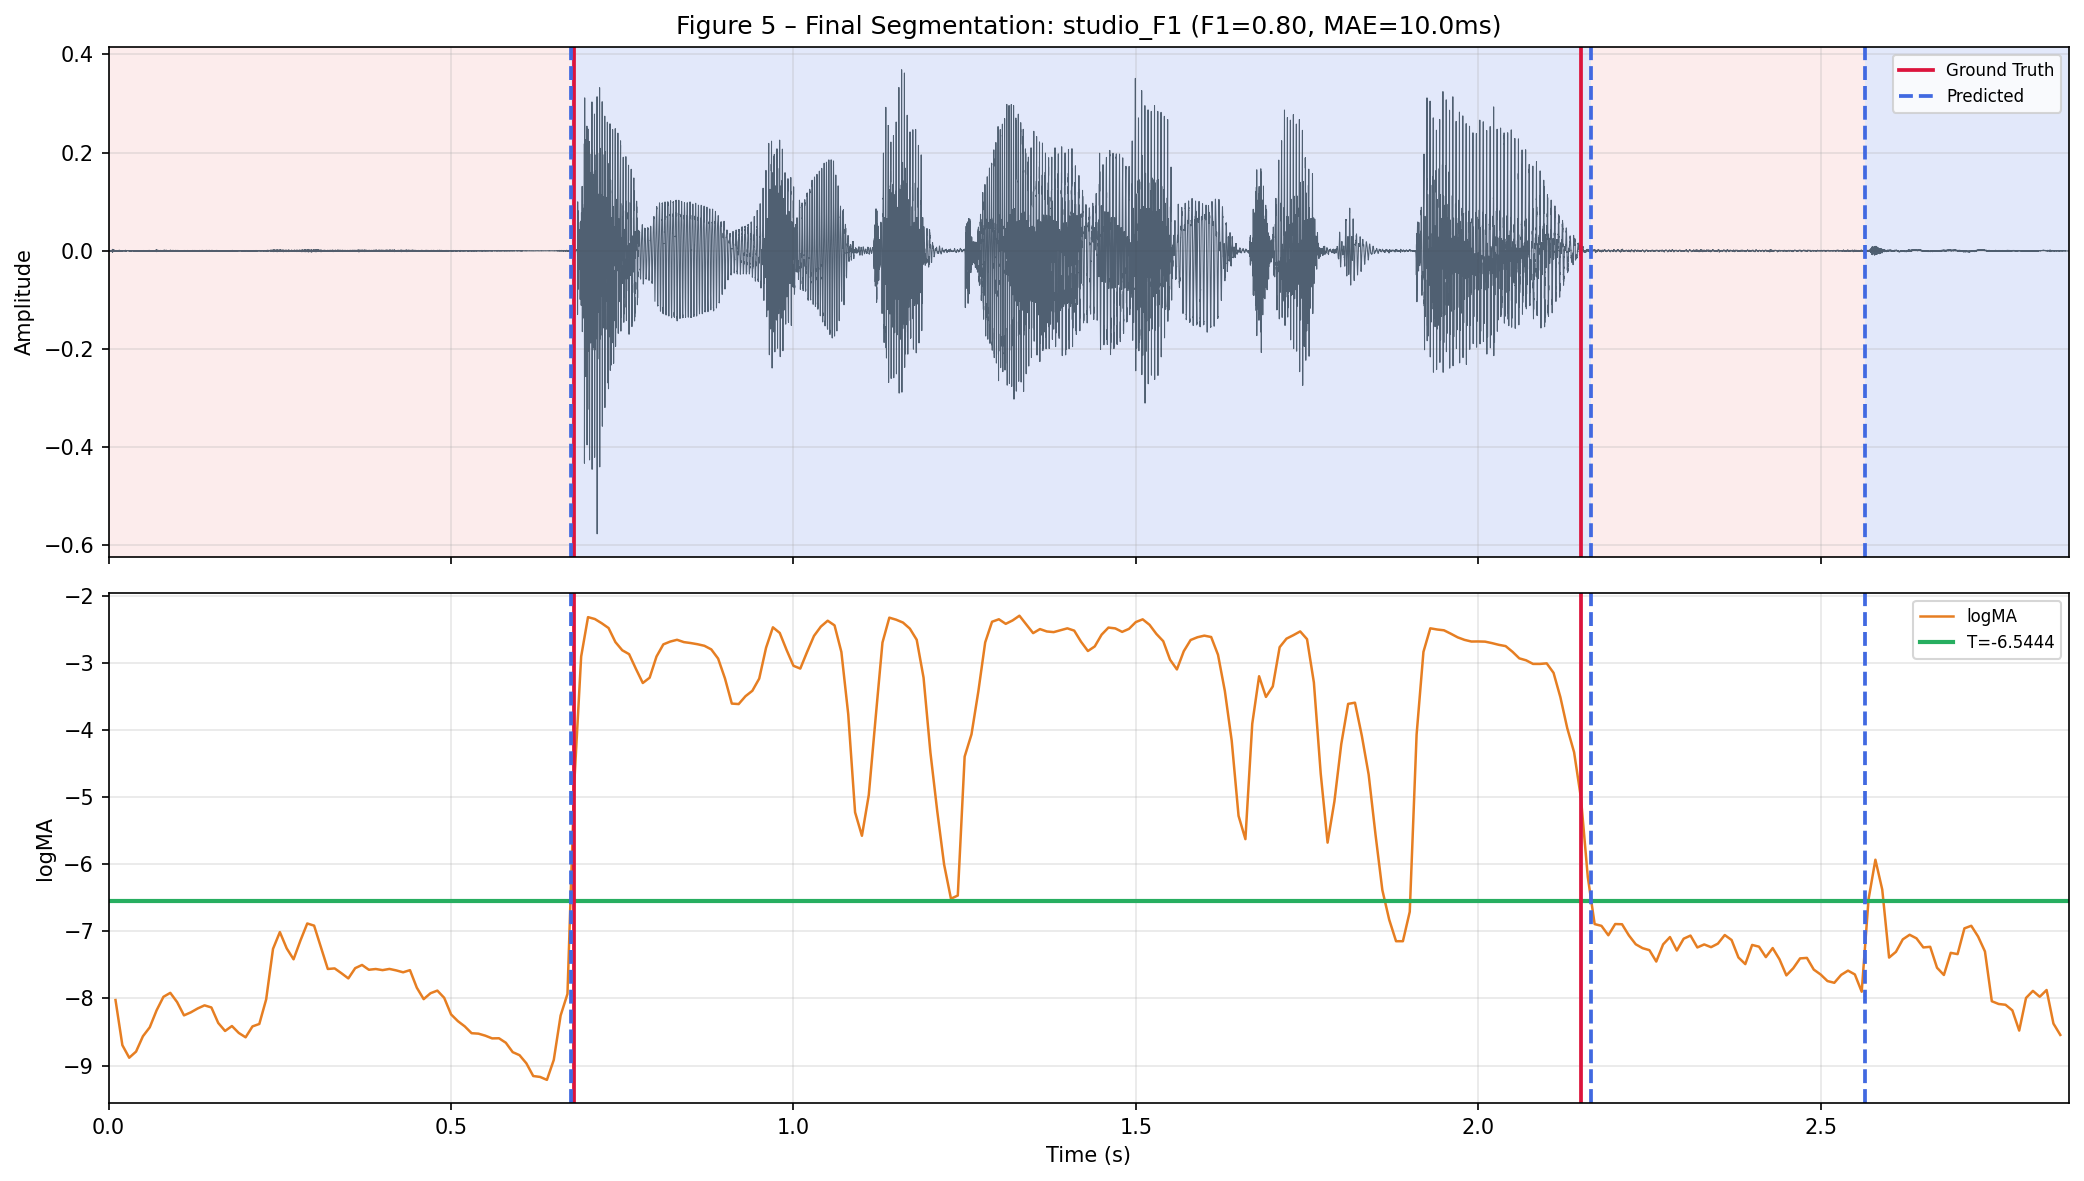


KẾT QUẢ PHÂN ĐOẠN PER-FILE (FIGURE 5): studio_M1


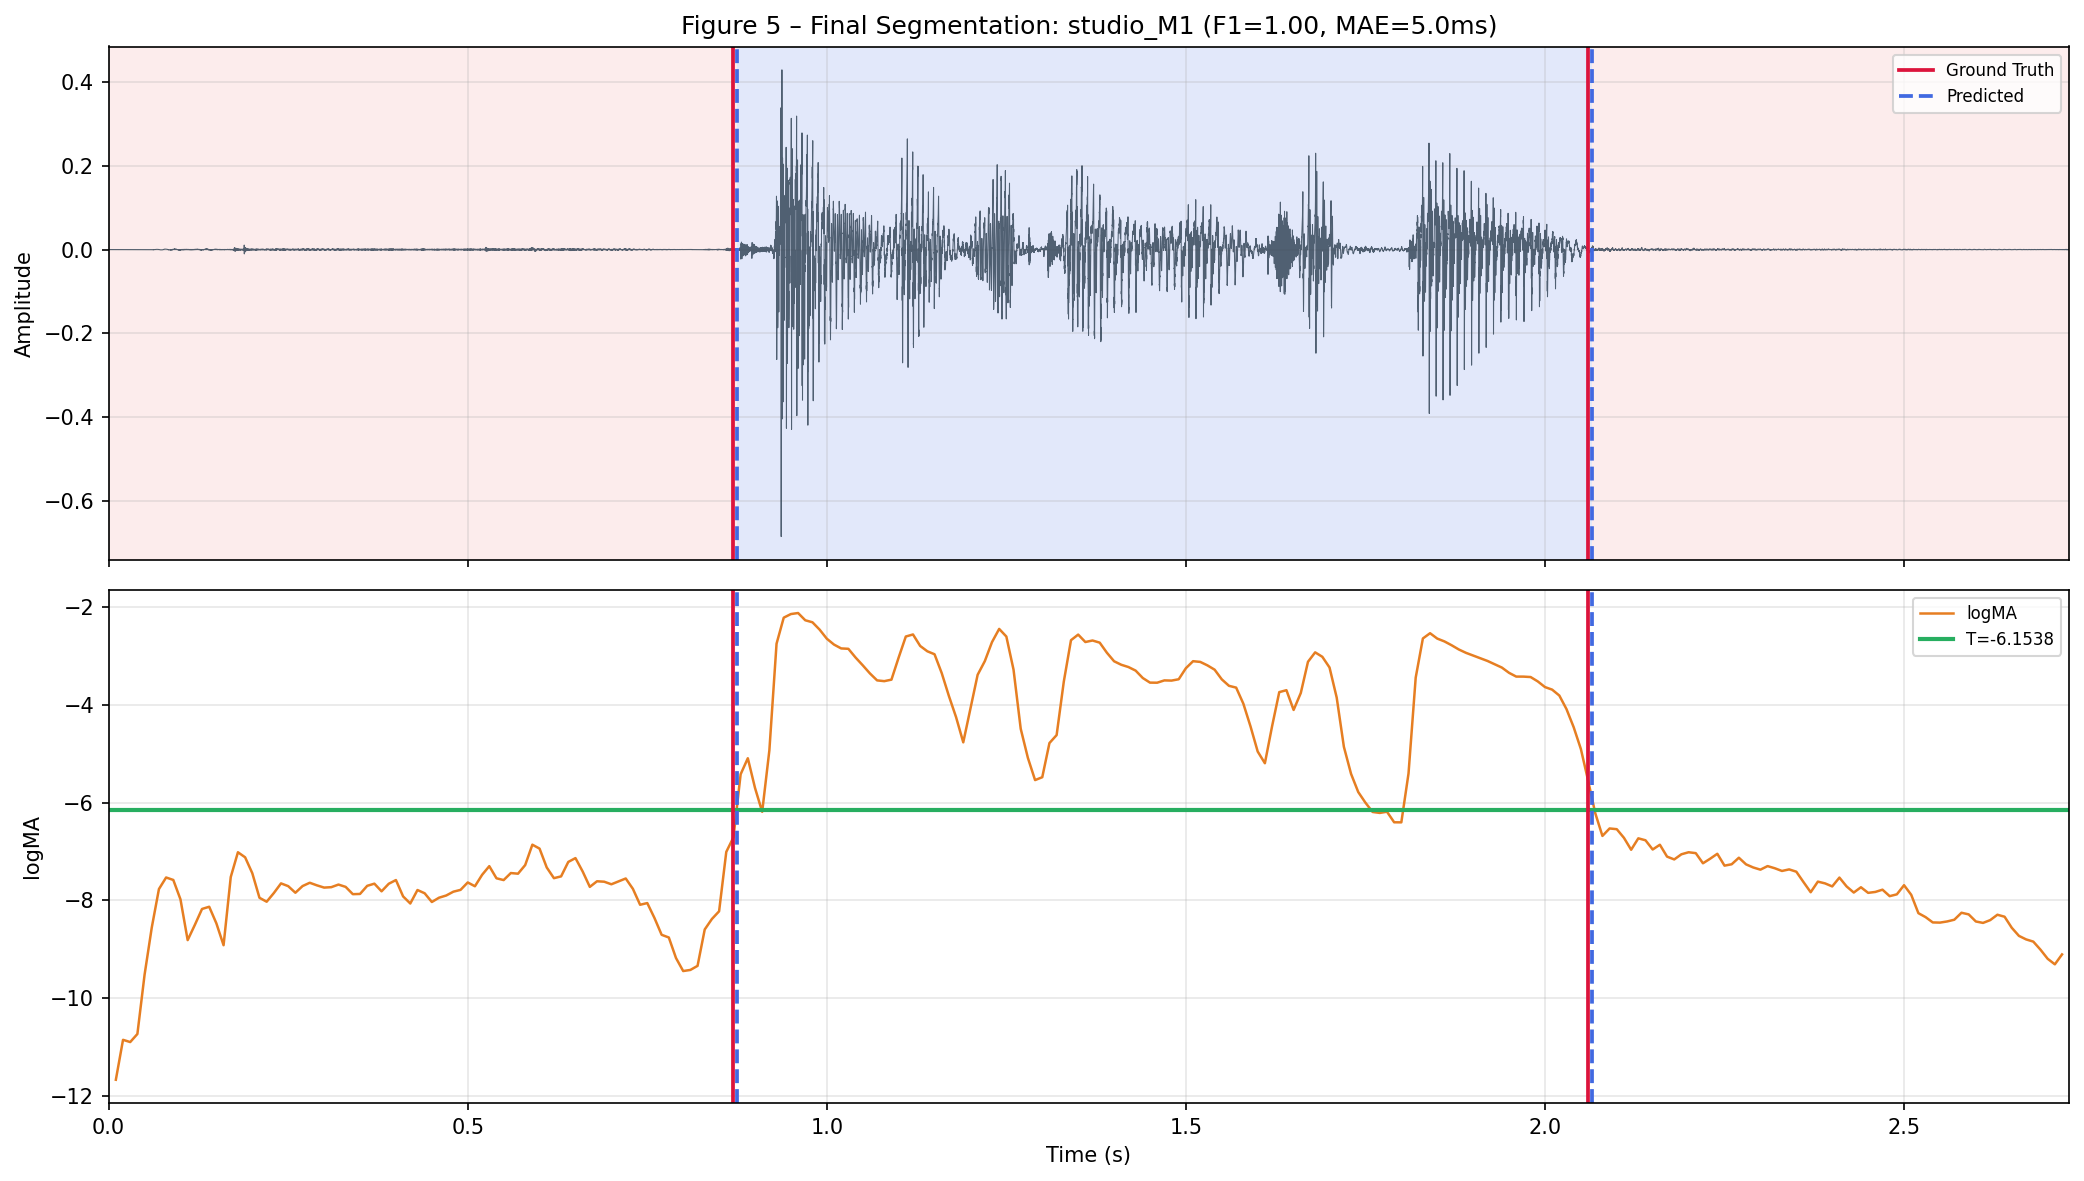


KẾT QUẢ PHÂN ĐOẠN PER-FILE (FIGURE 5): phone_F1


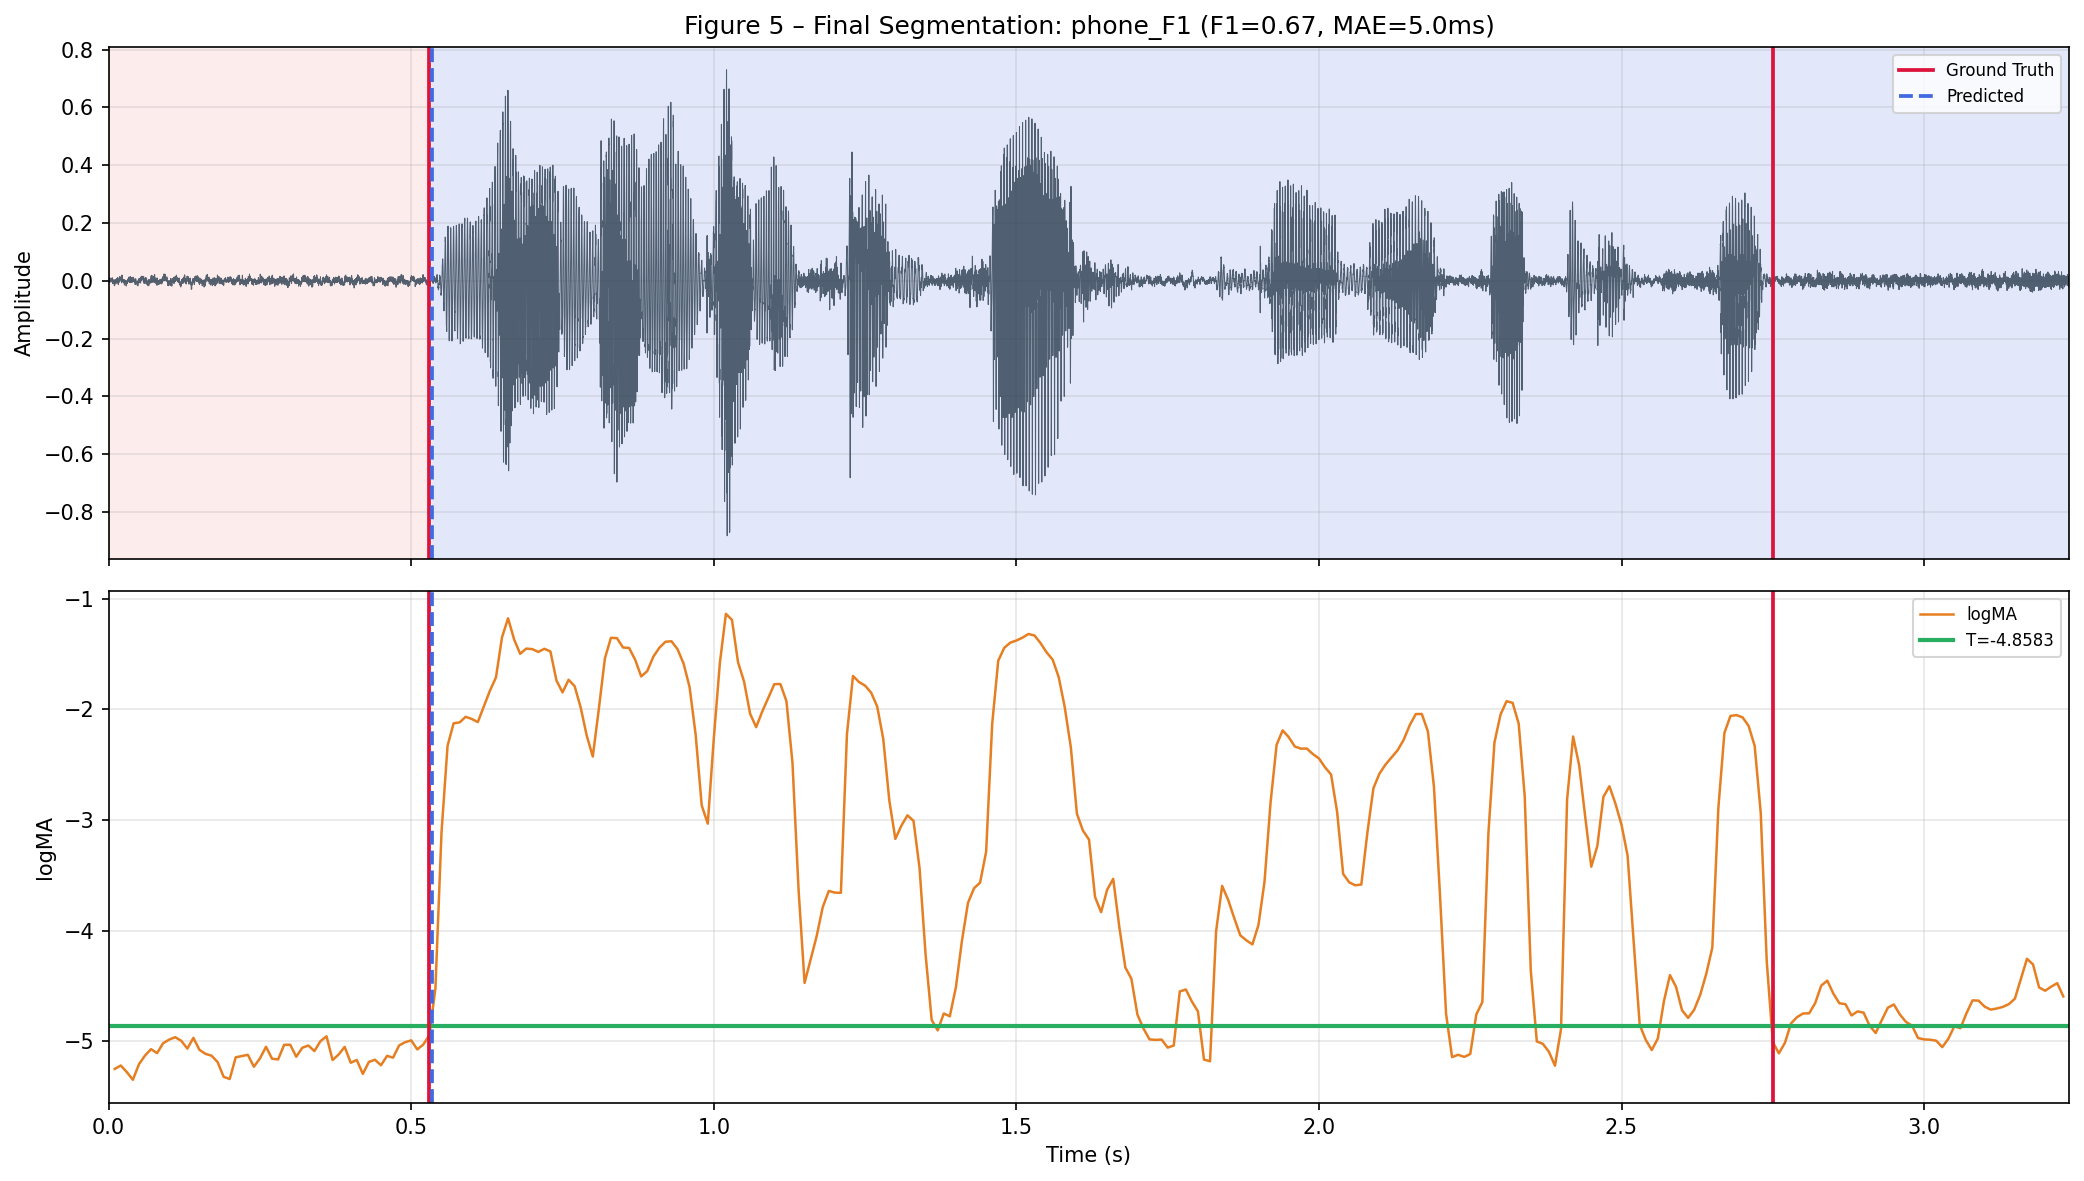


KẾT QUẢ PHÂN ĐOẠN PER-FILE (FIGURE 5): phone_M1


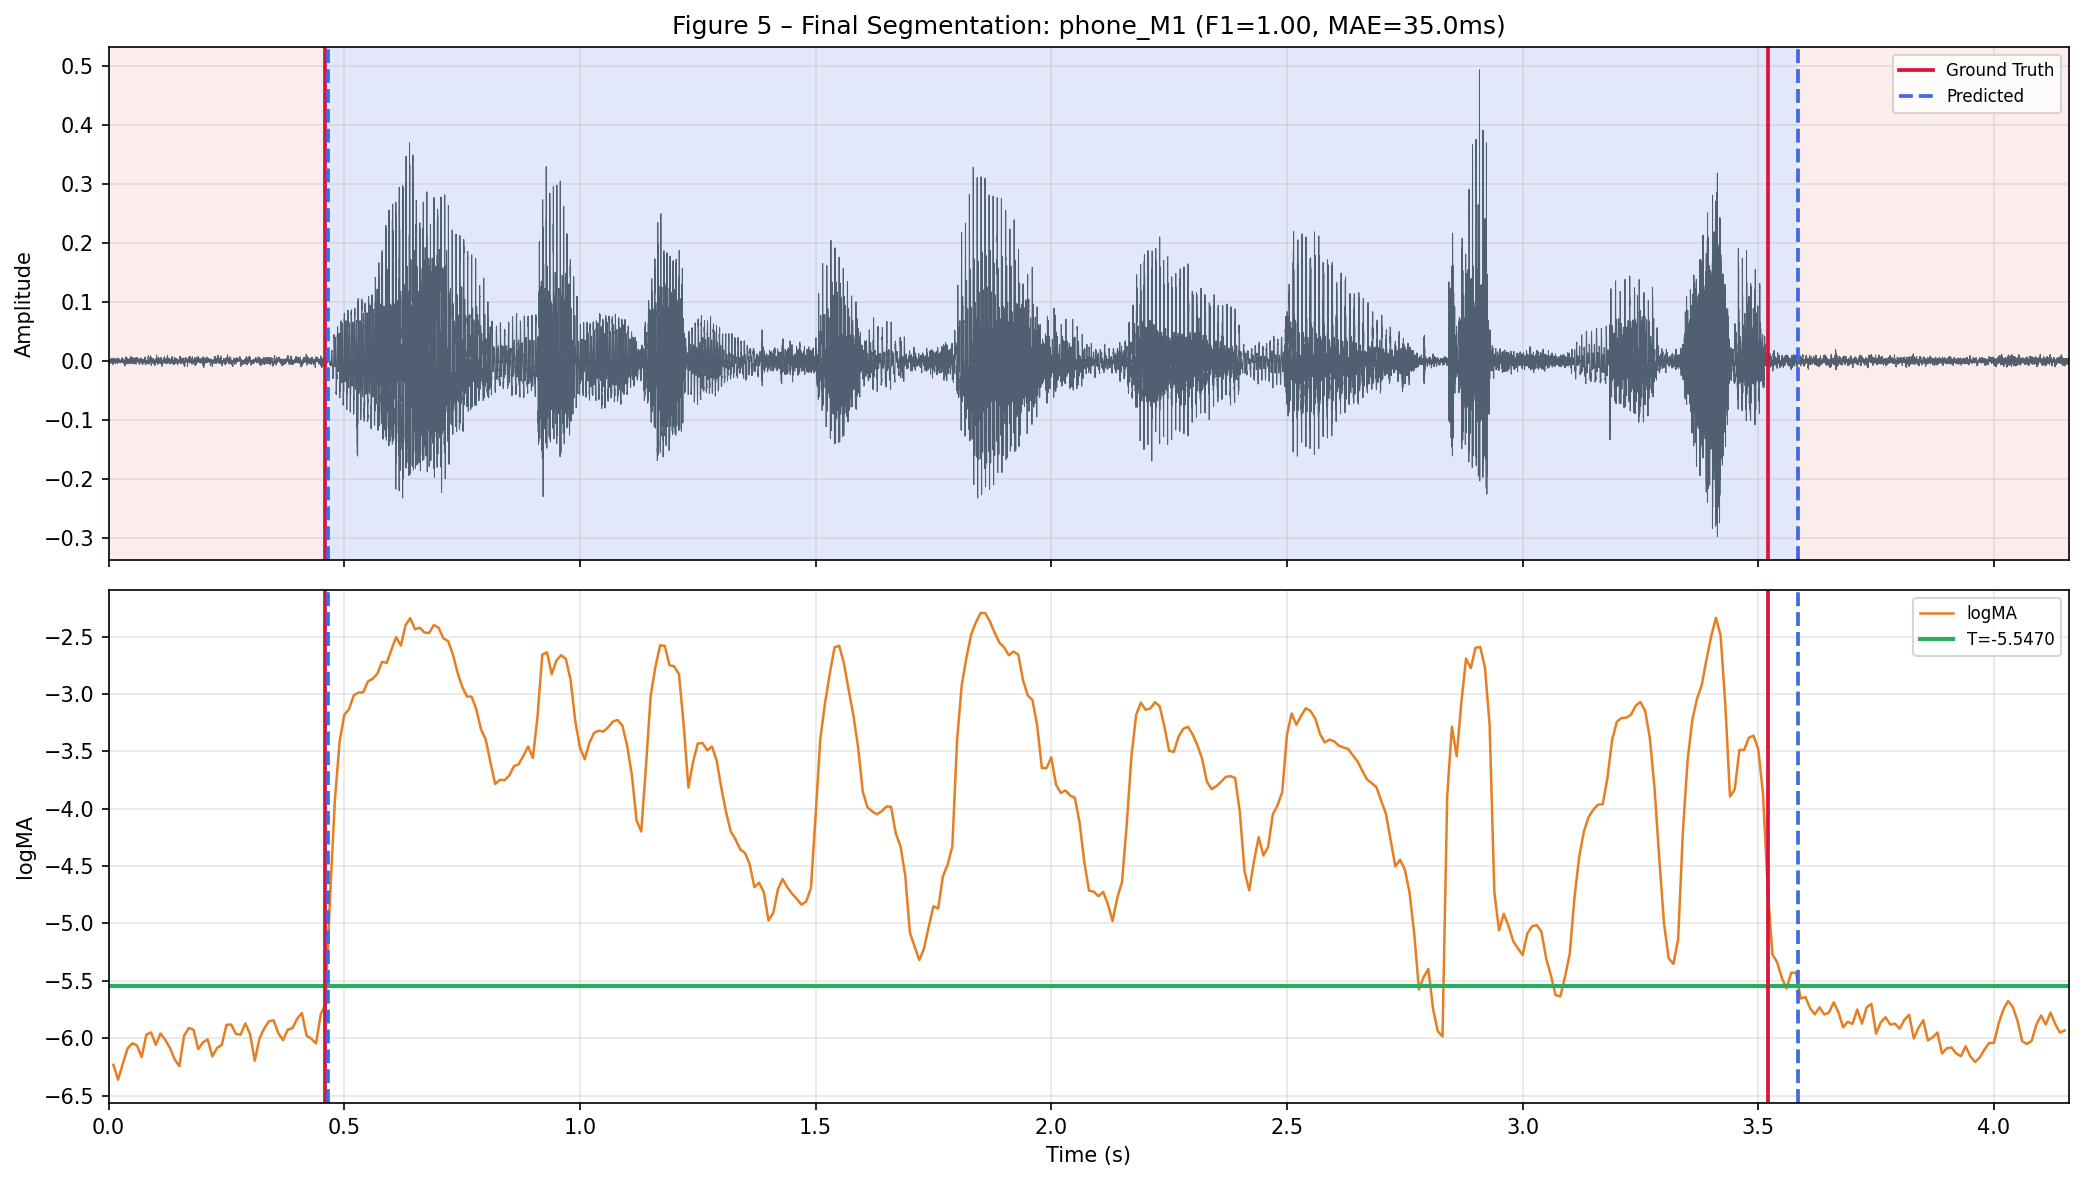

In [93]:
for fname in TRAIN_FILES:
    print(f"\n{'='*75}")
    print(f"KẾT QUẢ PHÂN ĐOẠN PER-FILE (FIGURE 5): {fname}")
    print(f"{'='*75}")
    fig_path = os.path.join(OUTPUT_DIR, "per_file", fname, "figures", f"{fname}_fig5_final_segmentation.png")
    display(Image(fig_path))

---
### 7. Bước 7: Huấn luyện Global Threshold & Khảo sát Nhiễu nền (Studio vs Phone)

#### 1. Khảo sát Định lượng Mức nhiễu nền (SNR) & Sự Khác Biệt Ngưỡng T

Tỷ số tín hiệu trên nhiễu (**Signal-to-Noise Ratio – SNR**) được tính toán định lượng dựa trên các đoạn nhãn chuẩn Ground Truth từ file `.lab`:
- **Công suất tín hiệu tiếng nói ($P_{speech}$):** Trung bình bình phương biên độ trên các đoạn nhãn Speech (`v` và `uv`):
  $$P_{speech} = \frac{1}{N_{spch}} \sum_{n \in \text{Speech}} s[n]^2$$
- **Công suất tạp âm nền ($P_{silence}$):** Trung bình bình phương biên độ trên các đoạn nhãn Silence (`sil`):
  $$P_{silence} = \frac{1}{N_{sil}} \sum_{n \in \text{Silence}} s[n]^2$$
- **Tỷ số SNR (đơn vị: decibel – dB):**
  $$\text{SNR (dB)} = 10 \log_{10} \left( \frac{P_{speech}}{P_{silence}} \right)$$

Đoạn mã dưới đây đọc trực tiếp tín hiệu và nhãn `.lab` để tính toán chính xác bảng số liệu SNR và năng lượng đặc trưng của cả 4 file huấn luyện:


In [94]:
# Tính toán định lượng công suất Speech, Silence và SNR (dB) theo nhãn Ground Truth .lab
snr_rows = []
for fname in TRAIN_FILES:
    wav_p = os.path.join(ORIGINAL_TRAINING_DIR, f"{fname}.wav")
    lab_p = os.path.join(ORIGINAL_TRAINING_DIR, f"{fname}.lab")
    sig, sr = load_audio(wav_p)
    lab_segs = parse_lab_file(lab_p)

    spk_samples = []
    sil_samples = []
    for seg in lab_segs:
        start_i = int(round(seg.start * sr))
        end_i = min(len(sig), int(round(seg.end * sr)))
        samples = sig[start_i:end_i]
        if seg.label in ("v", "uv"):
            spk_samples.extend(samples)
        elif seg.label == "sil":
            sil_samples.extend(samples)

    p_spk = float(np.mean(np.array(spk_samples, dtype=np.float64) ** 2)) if len(spk_samples) > 0 else 0.0
    p_sil = float(np.mean(np.array(sil_samples, dtype=np.float64) ** 2)) if len(sil_samples) > 0 else 1e-12
    snr_db = float(10.0 * np.log10(p_spk / max(p_sil, 1e-12)))

    fv, fc = compute_short_time_feature(sig, sr)
    lbls = assign_frame_labels(fc, lab_segs)
    sil_mean = float(np.mean(fv[lbls == 0]))
    spk_mean = float(np.mean(fv[lbls == 1]))

    snr_rows.append({
        "Tên File": fname,
        "Môi trường": "Phòng thu" if "studio" in fname else "Điện thoại",
        "P_speech": p_spk,
        "P_silence": p_sil,
        "SNR (dB)": snr_db,
        "Silence logMA Mean": sil_mean,
        "Speech logMA Mean": spk_mean,
    })

df_snr = pd.DataFrame(snr_rows)
display(df_snr.style.format({
    "P_speech": "{:.6f}",
    "P_silence": "{:.8f}",
    "SNR (dB)": "{:.1f}",
    "Silence logMA Mean": "{:.2f}",
    "Speech logMA Mean": "{:.2f}",
}))


/Users/coding/XLTN/separate_speech_silence/src/io_utils.py:139: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(wav_path)
2026-09-12 12:41:41,293 [WARNING]   1 frame không thuộc đoạn lab nào (unknown)
2026-09-12 12:41:41,299 [WARNING]   1 frame không thuộc đoạn lab nào (unknown)


,Tên File,Môi trường,P_speech,P_silence,SNR (dB),Silence logMA Mean,Speech logMA Mean
0,studio_F1,Phòng thu,0.005750,0.00000076,38.8,-7.70,-3.29
1,studio_M1,Phòng thu,0.003539,0.00000059,37.8,-7.87,-3.70
2,phone_F1,Điện thoại,0.021789,0.00009141,23.8,-4.93,-2.97
3,phone_M1,Điện thoại,0.002613,0.00001227,23.3,-5.91,-3.71


**Nhận xét khoa học từ bảng số liệu SNR:**
1. **Môi trường Phòng thu (`studio_F1`, `studio_M1`):**
   - Độ yên tĩnh cực cao, đạt **$\text{SNR} \approx 37.8 - 38.8\text{ dB}$**.
   - Công suất tạp âm nền $P_{silence}$ chỉ ở mức $10^{-7}$ (gần bằng $0$), dẫn tới mức năng lượng trung bình **Silence logMA Mean** chìm sâu xuống **$-7.70$ đến $-7.87$**.
   - Do sàn nhiễu rất thấp, ngưỡng tối ưu riêng (**Per-file Threshold**) được thuật toán học ở mức **$-6.15$ đến $-6.54$** (cân bằng giữa sàn nhiễu $\approx -7.8$ và tiếng nói $\approx -3.5$).

2. **Môi trường Điện thoại (`phone_F1`, `phone_M1`):**
   - Tạp âm môi trường lớn hơn đáng kể, **$\text{SNR}$ tụt xuống $\approx 23.3 - 23.8\text{ dB}$**.
   - Công suất tạp âm nền $P_{silence}$ cao hơn từ **$20$ đến $155$ lần** so với phòng thu, kéo mức **Silence logMA Mean** bị đội lên mức **$-4.93$ đến $-5.91$**.
   - Do đó, ngưỡng tối ưu riêng (**Per-file Threshold**) bị đẩy lên cao hơn nhiều: **$-4.86$ đến $-5.55$**.

3. **Hiện tượng khi gộp 4 file:**
   - Do các file phòng thu chiếm lượng frame lớn và có sàn năng lượng thấp, ngưỡng tối ưu toàn cục bị kéo xuống **$T_{global} = -5.28726548$**.
   - Mức ngưỡng này thấp hơn mức tạp âm nền trung bình của `phone_F1` ($-5.287 < -4.93$), giải thích hoàn toàn hiện tượng *Acoustic Mismatch*.


#### 2. Histogram Phân phối Speech vs Silence & Vùng Overlap Global khi Gộp 4 File
Khi gộp toàn bộ $794$ khung Speech và $499$ khung Silence từ cả 4 file huấn luyện (`studio_F1`, `studio_M1`, `phone_F1`, `phone_M1`), hệ thống xác định được **Vùng Overlap Toàn cục**:
$$T_{min} = \max(\min(\text{Speech}_{all}), \min(\text{Silence}_{all})) = -7.147211$$
$$T_{max} = \min(\max(\text{Speech}_{all}), \max(\text{Silence}_{all})) = -4.254196$$

Biểu đồ **Figure 3 (Global)** dưới đây thể hiện phân phối xác suất tổng thể của toàn bộ dữ liệu, làm nổi bật:
- **Phân phối Speech (xanh dương)** và **Silence (đỏ)** trên toàn bộ tập huấn luyện.
- **Dải màu vàng Overlap:** Miền giao thoa giữa Speech và Silence.
- **Đường màu xanh lá cây:** Vị trí ngưỡng tối ưu toàn cục $\mathbf{T_{global} = -5.28726548}$ nằm chính xác trong vùng Overlap.


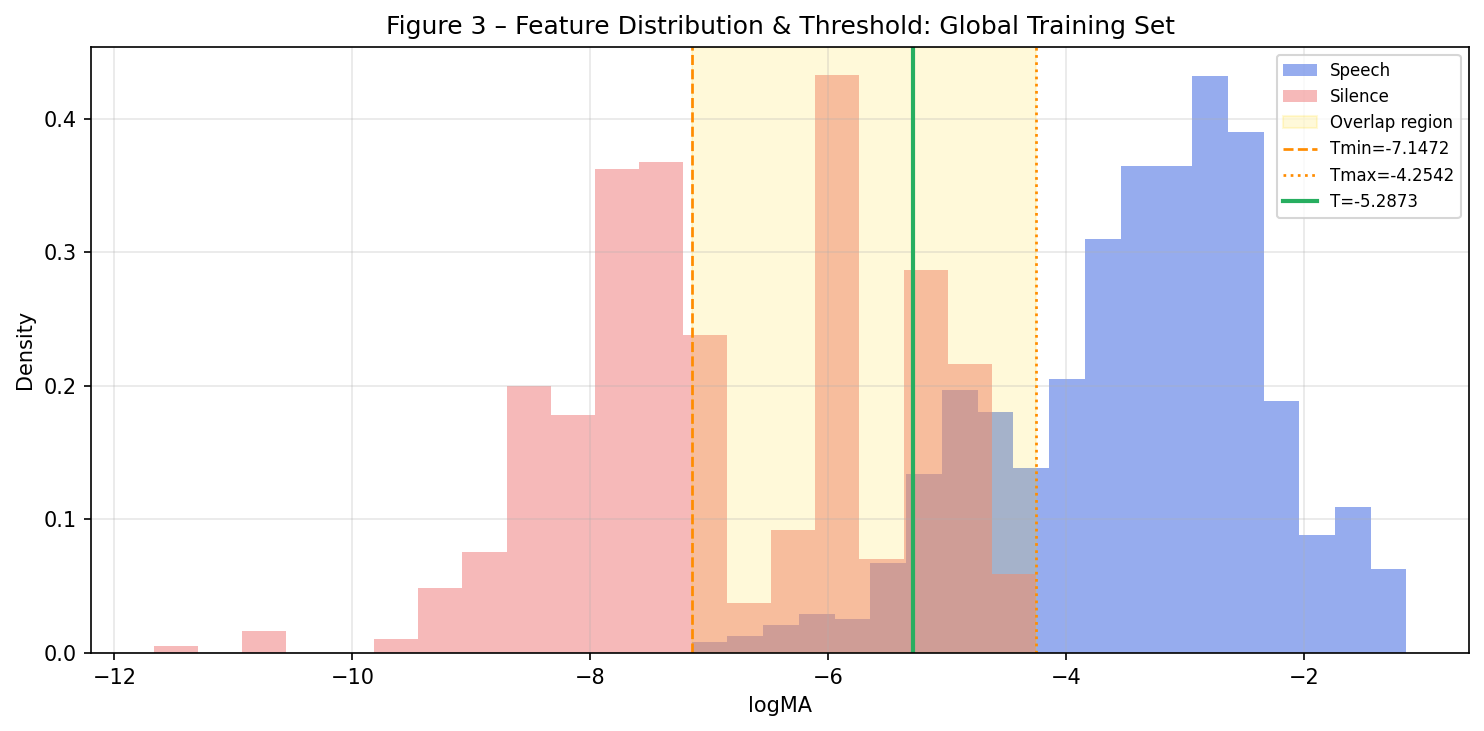

In [95]:
# Hiển thị Figure 3 (Global): Histogram phân phối Speech vs Silence & Vùng Overlap Global
fig3_global_path = os.path.join(OUTPUT_DIR, "training", "figures", "global_fig3_distribution.png")
display(Image(fig3_global_path))


#### 3. Quá Trình Huấn Luyện Binary Search Global (Đồ thị Hội tụ)
Thuật toán tìm kiếm nhị phân (Hodgkinson 2012) được áp dụng trên tập dữ liệu gộp để tìm điểm cân bằng hàm tổn thất:
$$C_{silence}(T) = \frac{1}{N_{sil}}\sum \max(\text{sil} - T, 0) = C_{speech}(T) = \frac{1}{N_{spch}}\sum \max(T - \text{speech}, 0)$$

Đồ thị **Figure 4 (Global)** thể hiện quá trình hội tụ qua 30 vòng lặp:
- **Subplot 1:** Ngưỡng $T$ tiệm cận dần về giá trị tối ưu $-5.28726548$.
- **Subplot 2:** Sự cân bằng của 2 hàm mất mát nhầm lẫn $C_{silence}$ và $C_{speech}$.
- **Subplot 3:** Hiệu số tổn thất $(C_{silence} - C_{speech})$ tiến dần về $0$ (sai lệch $|D(T)| < 10^{-8}$).



HỘI TỤ BINARY SEARCH GLOBAL | Số vòng lặp: 30 | Ngưỡng toàn cục T_global = -5.287265


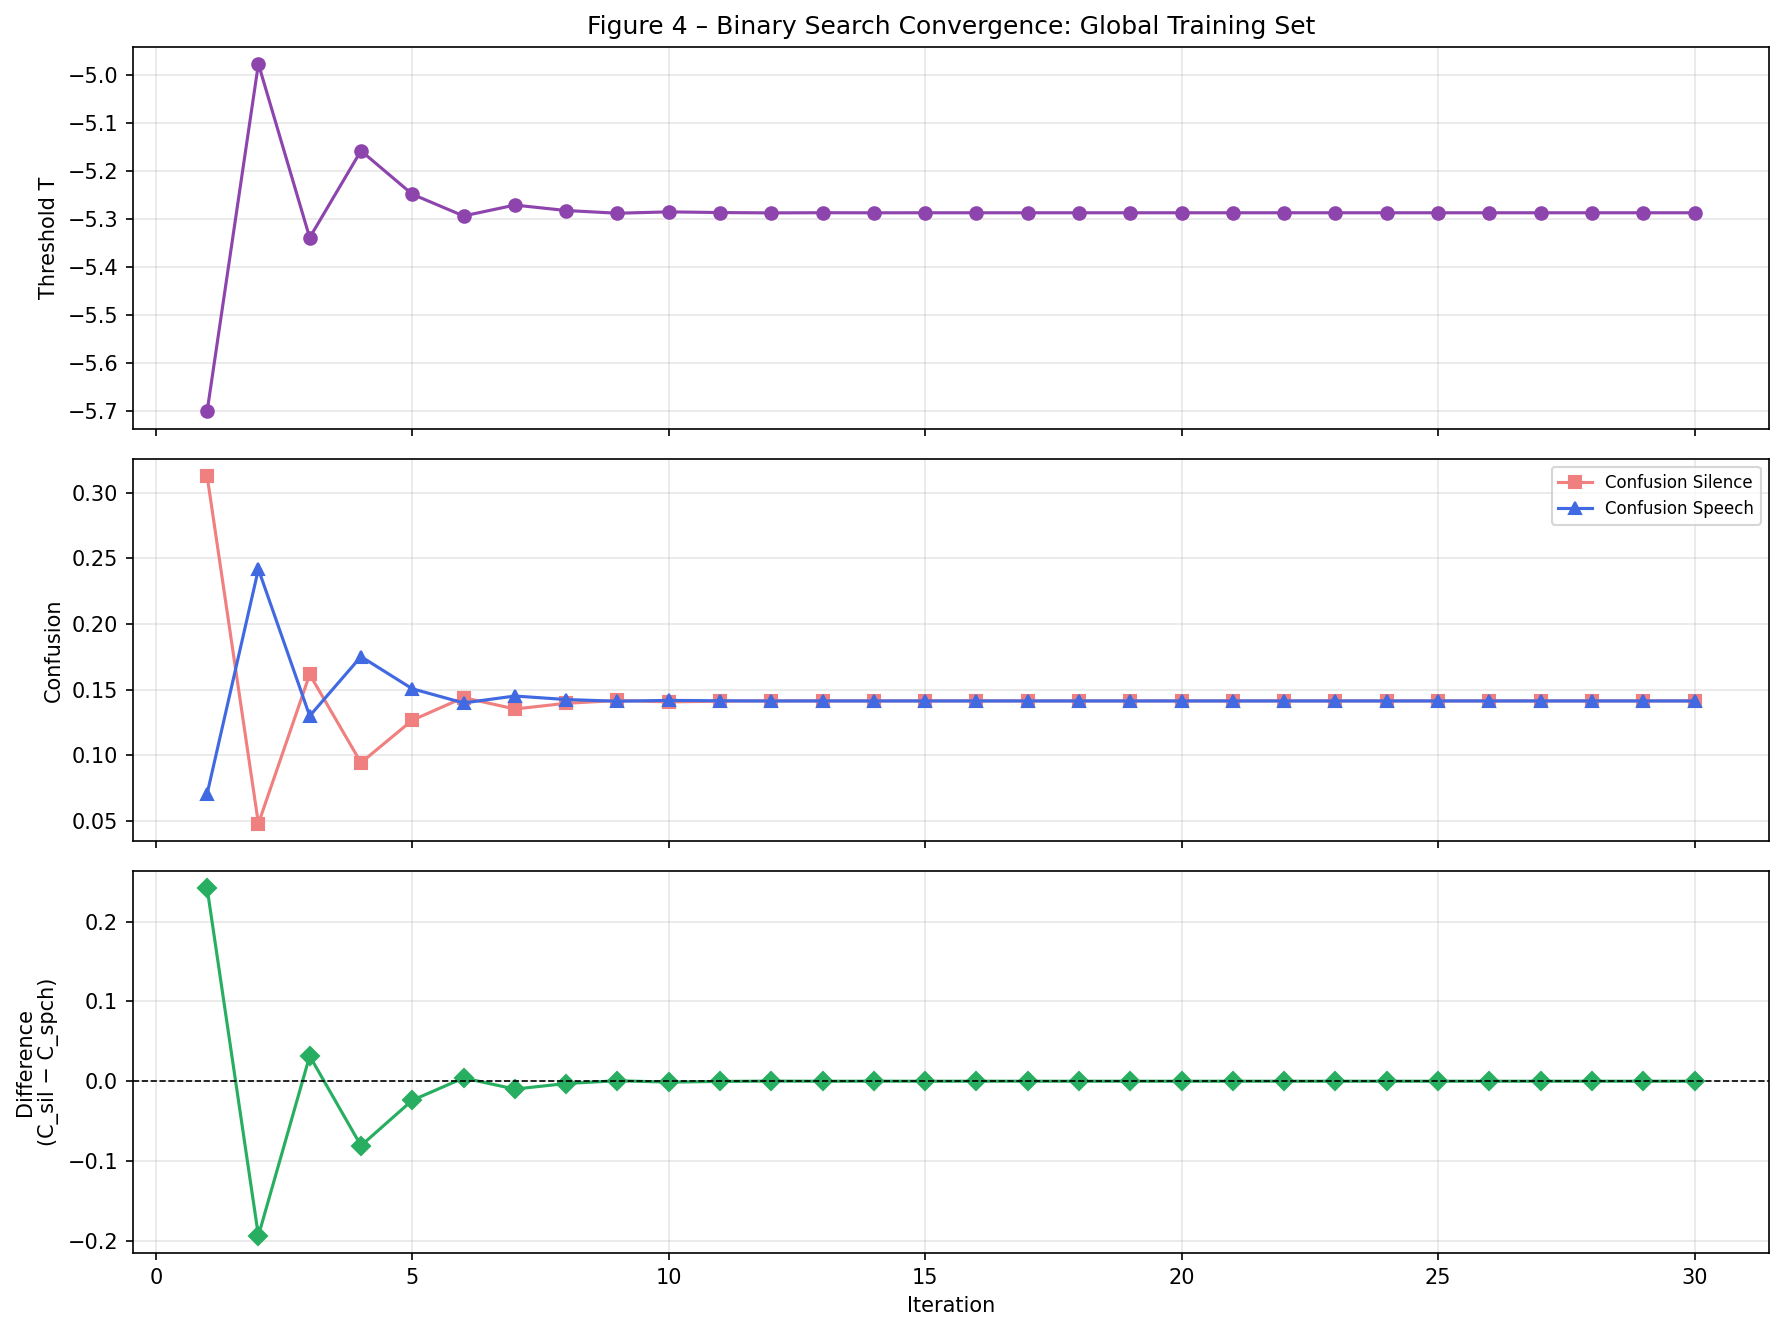

In [96]:
df_hist = pd.read_csv(os.path.join(OUTPUT_DIR, "training", "binary_search_history.csv"))
gl_step = df_hist[df_hist["source"] == "GLOBAL"].iloc[-1]
n_iters = int(gl_step["iteration"])
opt_t = float(gl_step["threshold"])

print(f"\n{'='*75}")
print(f"HỘI TỤ BINARY SEARCH GLOBAL | Số vòng lặp: {n_iters} | Ngưỡng toàn cục T_global = {opt_t:.6f}")
print(f"{'='*75}")
fig4_global_path = os.path.join(OUTPUT_DIR, "training", "figures", "global_fig4_binary_search.png")
display(Image(fig4_global_path))


#### 4. Bảng Kết quả Đánh giá Global Threshold trên Từng File Huấn Luyện
Bảng dưới đây áp dụng **cùng một** $T_{global} = -5.287265$ cho cả 4 file (không "biết trước" đặc điểm riêng từng file
như Bước 6) — đây là phép thử thực tế cho khả năng tổng quát hóa của ngưỡng năng lượng tĩnh:


In [97]:
df_gl = pd.read_csv(os.path.join(OUTPUT_DIR, "training", "threshold_summary_global.csv"))
table_gl = df_gl[["filename", "global_threshold", "precision", "recall", "f1", "mae_ms", "rmse_ms"]].copy()
table_gl.columns = ["Tên File", "Ngưỡng Chung", "Precision", "Recall", "F1-Score", "MAE (ms)", "RMSE (ms)"]
display(table_gl.style.format({
    "Ngưỡng Chung": "{:.4f}", "Precision": "{:.2f}", "Recall": "{:.2f}",
    "F1-Score": "{:.2f}", "MAE (ms)": "{:.1f}", "RMSE (ms)": "{:.1f}",
}))

,Tên File,Ngưỡng Chung,Precision,Recall,F1-Score,MAE (ms),RMSE (ms)
0,phone_F1,-5.2873,0.00,0.00,0.00,nan,nan
1,phone_M1,-5.2873,1.00,1.00,1.00,10.0,11.2
2,studio_F1,-5.2873,1.00,1.00,1.00,5.0,5.0
3,studio_M1,-5.2873,1.00,1.00,1.00,10.0,11.2


#### 5. Hiển thị Trực quan 4 Figures Kết quả dùng Global Threshold (Figure 5)



KẾT QUẢ PHÂN ĐOẠN VỚI GLOBAL THRESHOLD (T = -5.287265): studio_F1


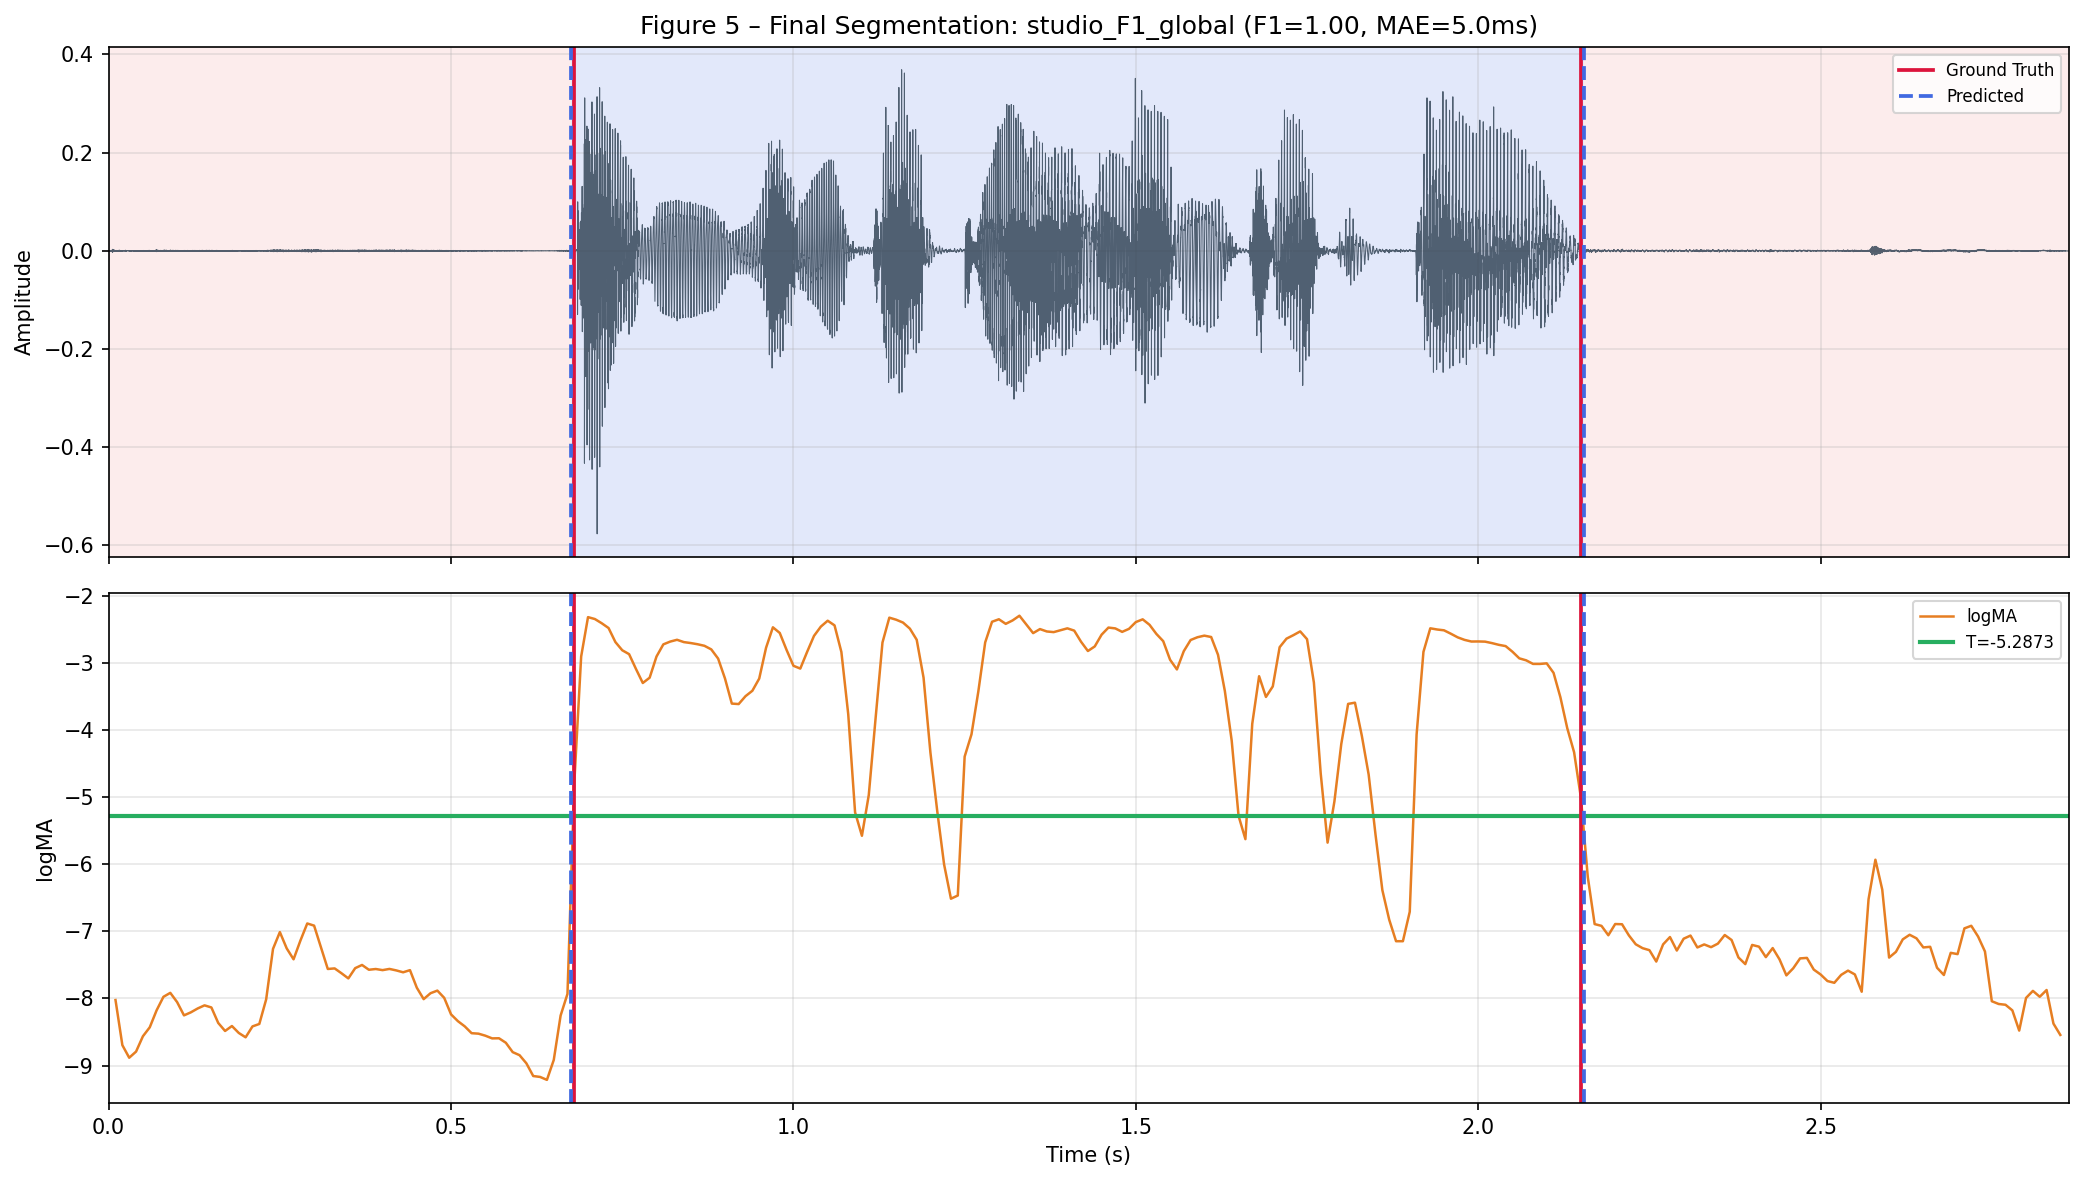


KẾT QUẢ PHÂN ĐOẠN VỚI GLOBAL THRESHOLD (T = -5.287265): studio_M1


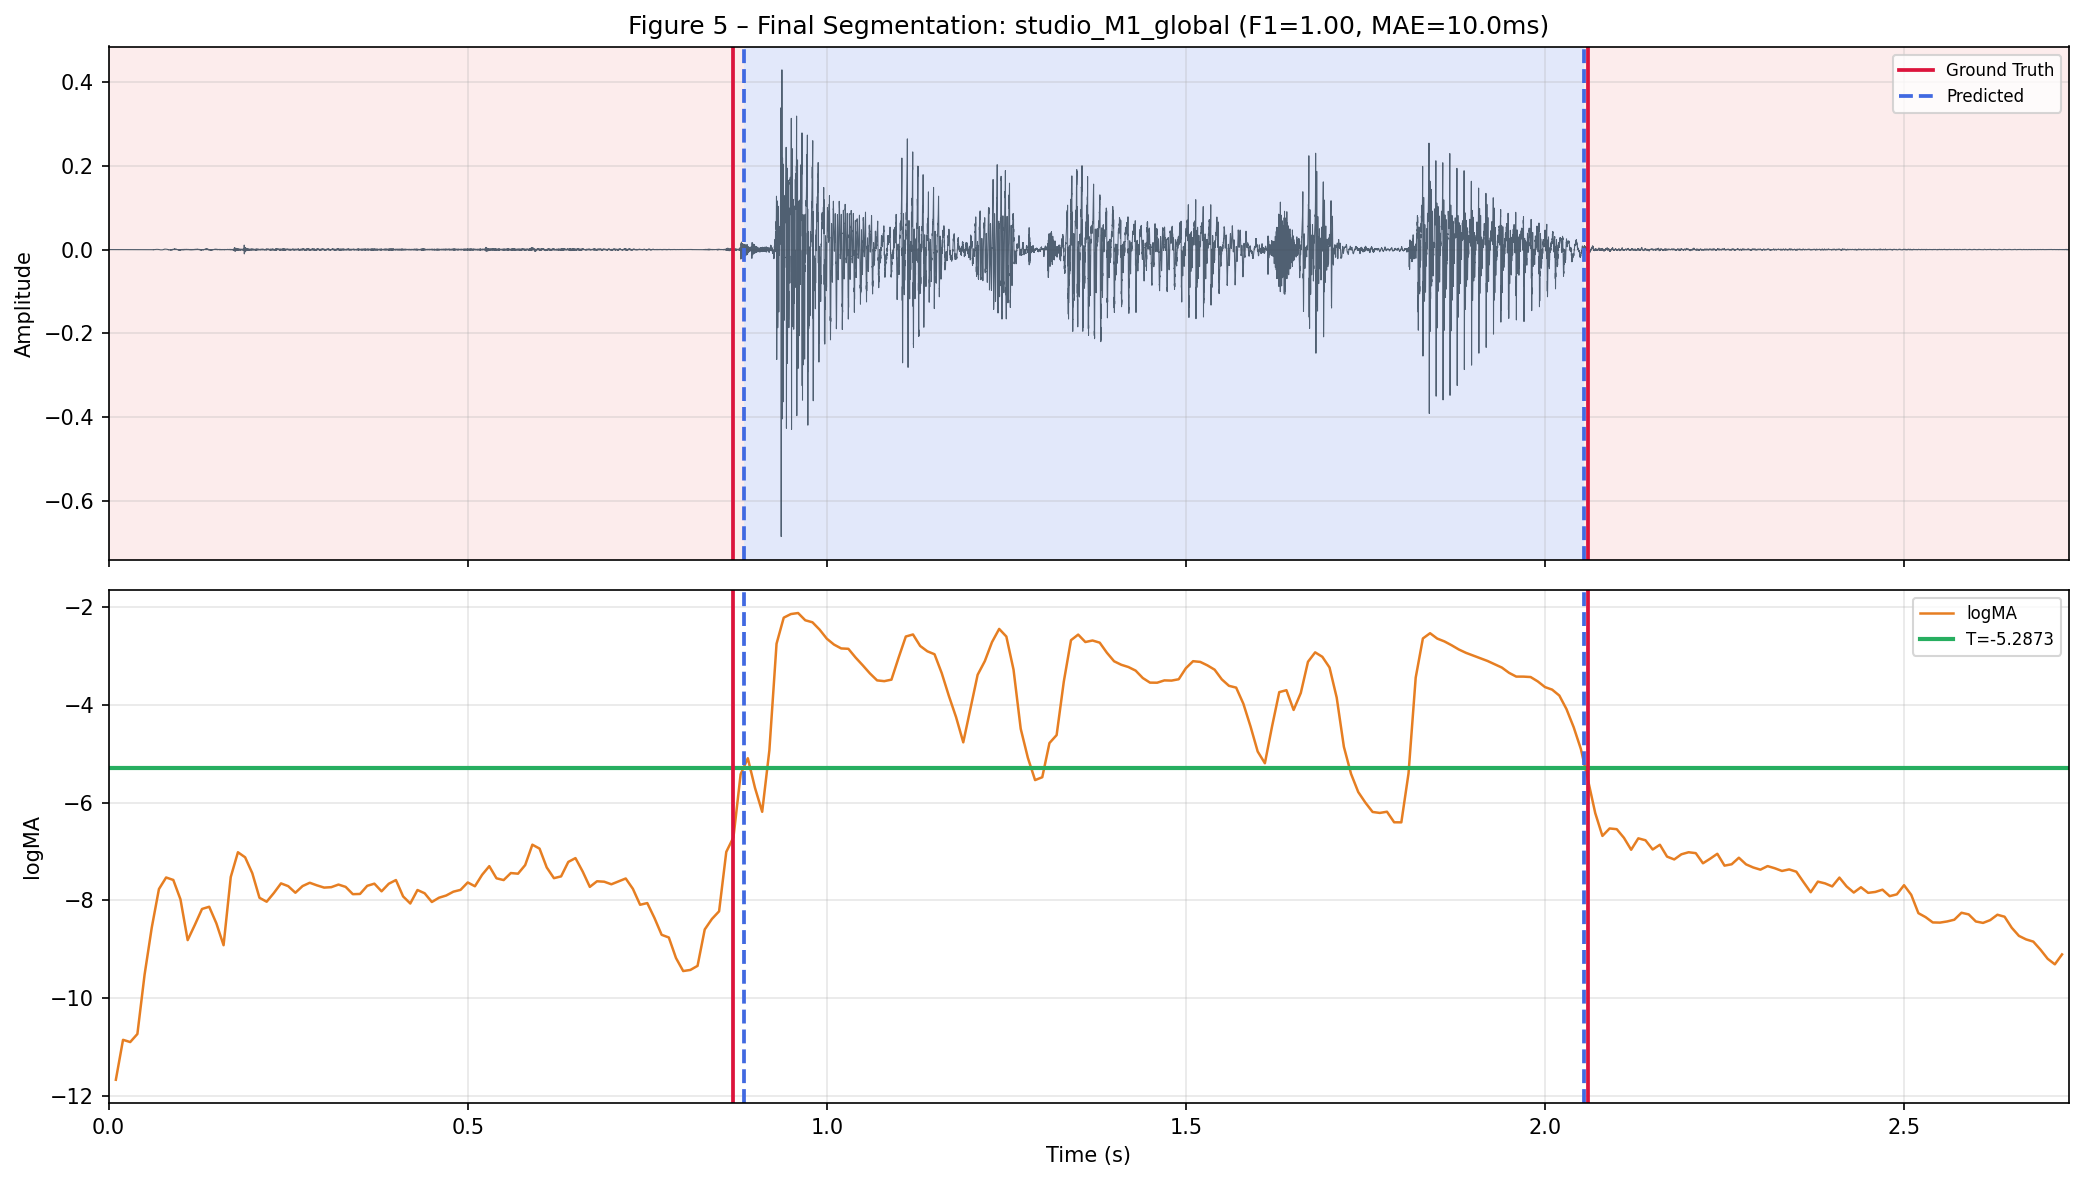


KẾT QUẢ PHÂN ĐOẠN VỚI GLOBAL THRESHOLD (T = -5.287265): phone_F1


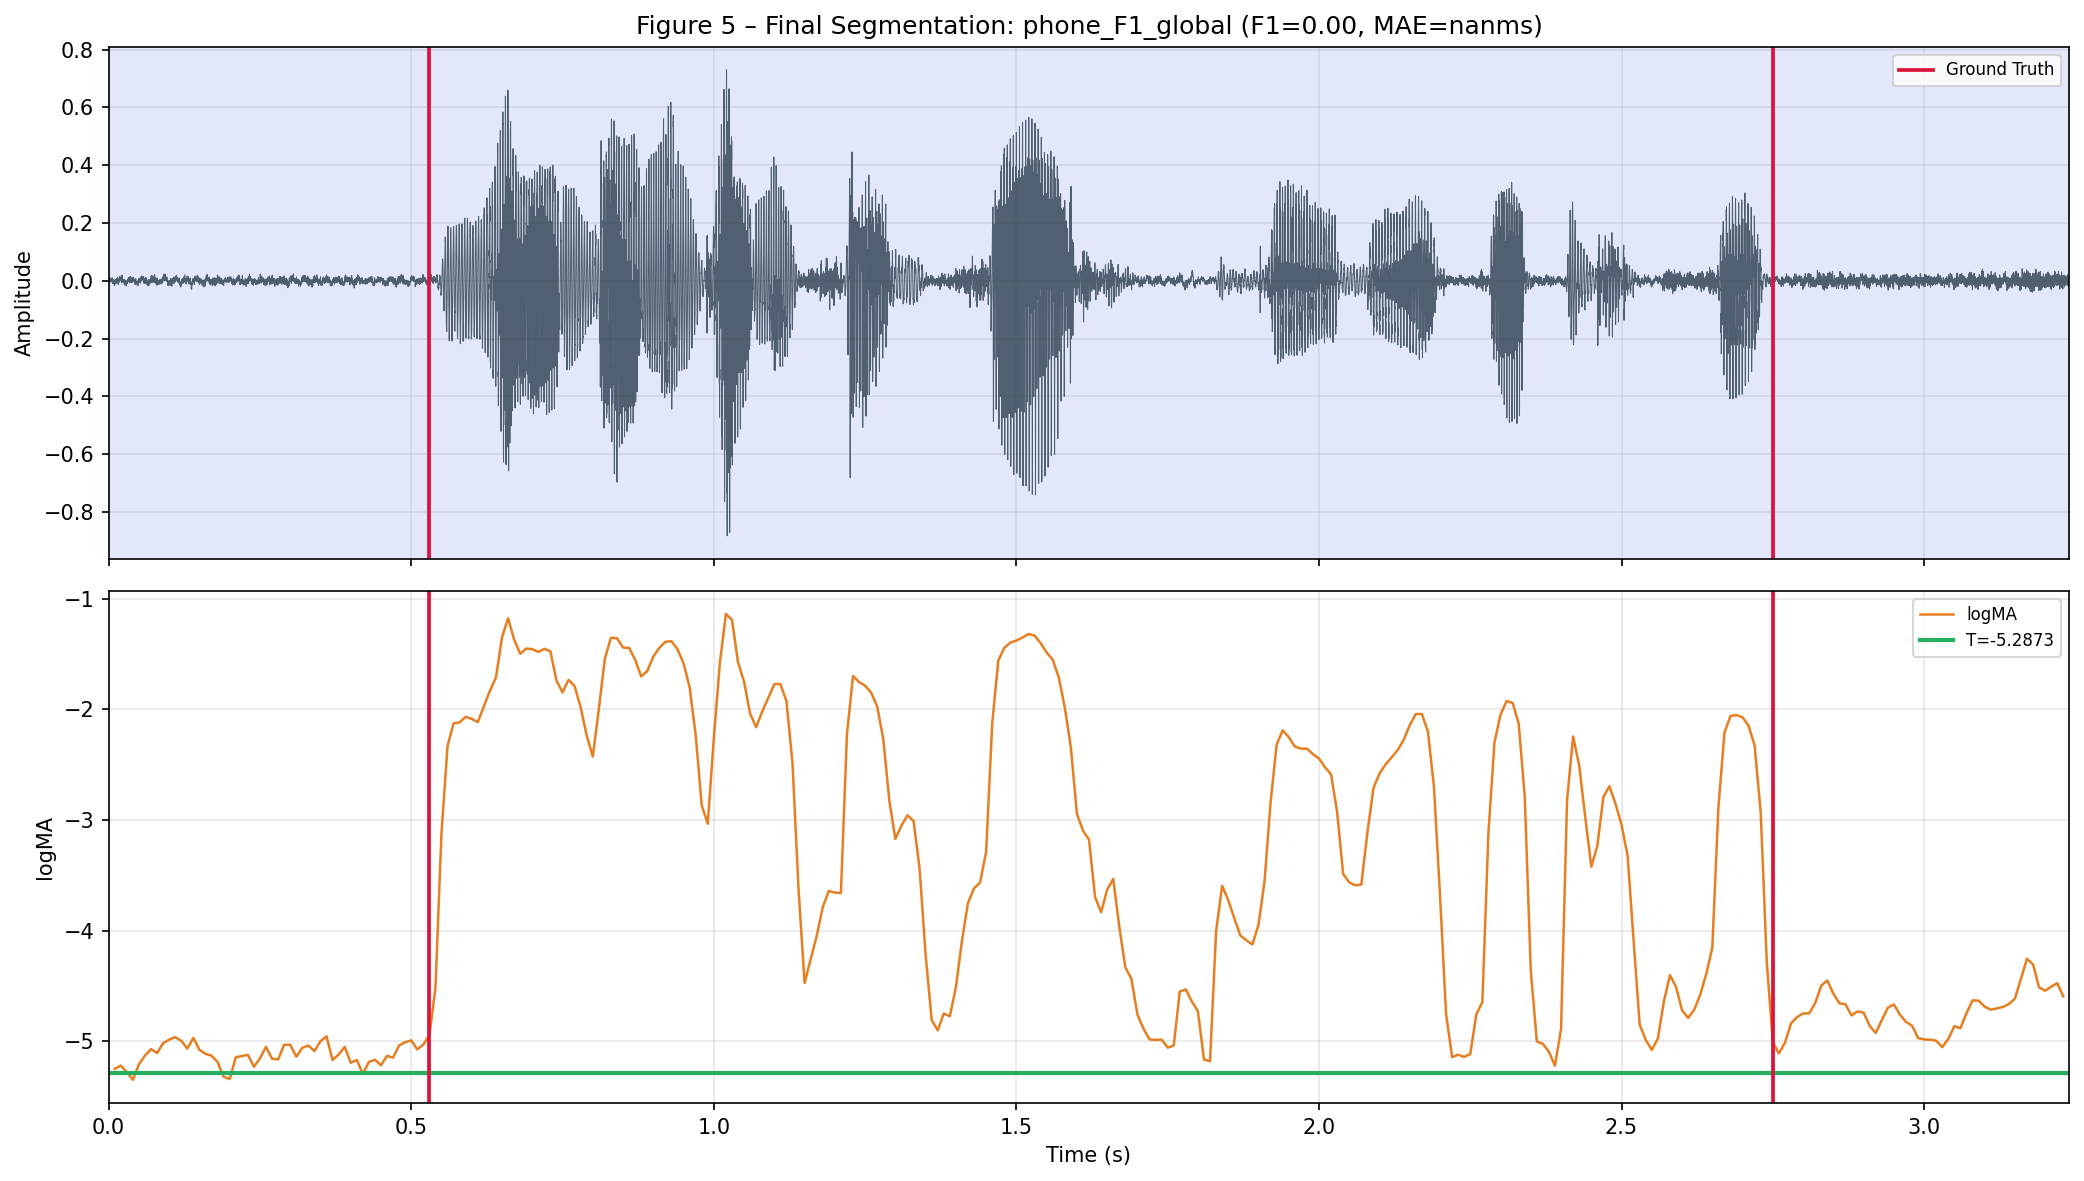


KẾT QUẢ PHÂN ĐOẠN VỚI GLOBAL THRESHOLD (T = -5.287265): phone_M1


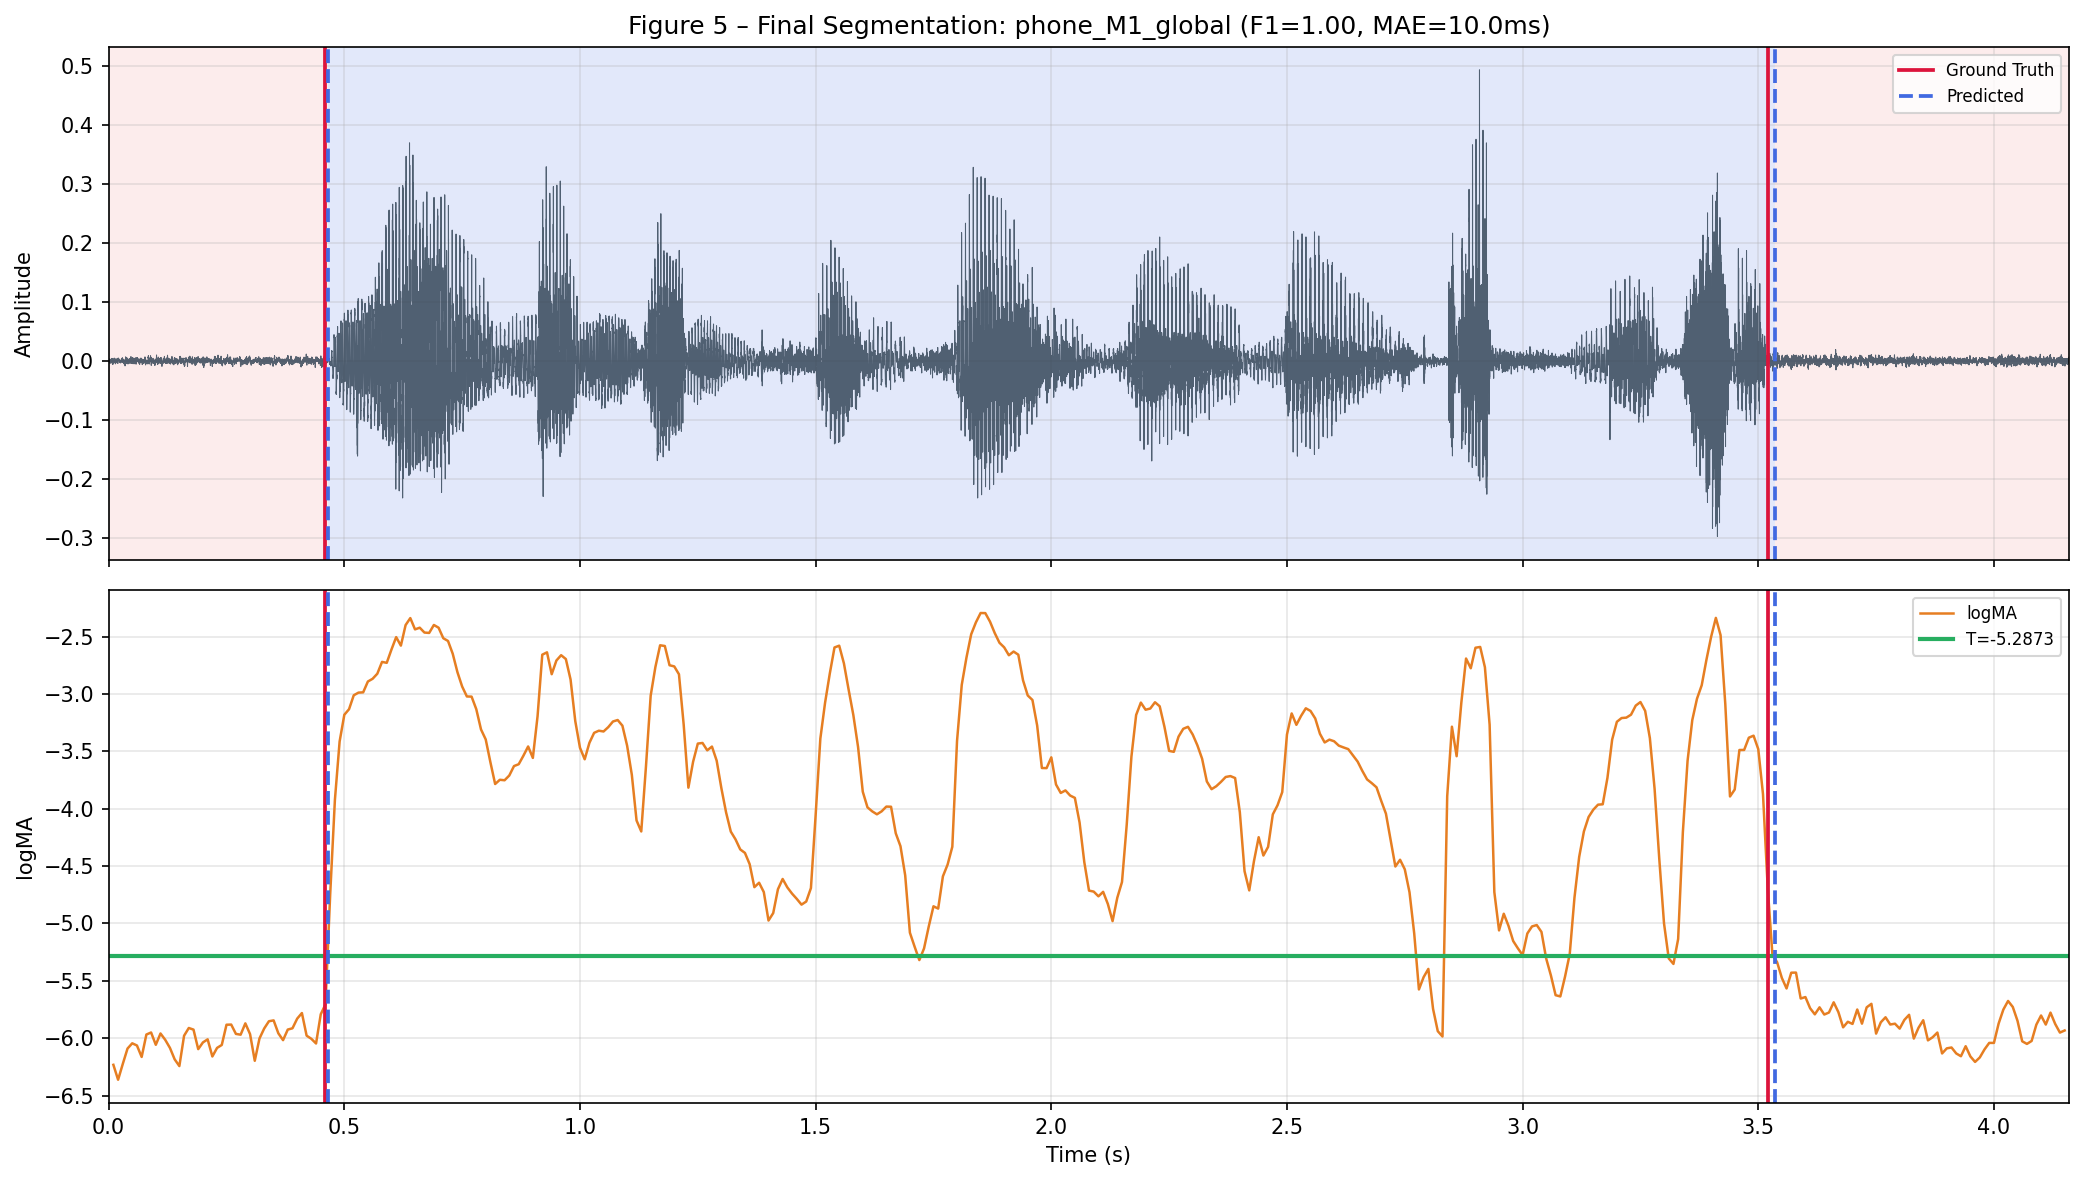

In [98]:
for fname in TRAIN_FILES:
    print(f"\n{'='*75}")
    print(f"KẾT QUẢ PHÂN ĐOẠN VỚI GLOBAL THRESHOLD (T = -5.287265): {fname}")
    print(f"{'='*75}")
    fig_path = os.path.join(OUTPUT_DIR, "final", "figures", f"{fname}_global_fig5_segmentation.png")
    display(Image(fig_path))

#### 6. Phân tích Khoa học: Hiện tượng Acoustic Mismatch trên `phone_F1`
- **Trên các file phòng thu (`studio_F1`, `studio_M1`) và `phone_M1`:** ngưỡng $T_{global}$ hoạt động rất tốt, đạt điểm tuyệt đối $\mathbf{F_1 = 1.00}$.
- **Riêng trên `phone_F1`:** do mức ồn nền của điện thoại quá lớn (trung bình $-4.93$), trong khi ngưỡng chung bị các file phòng thu kéo tụt xuống $-5.287$, toàn bộ tạp âm nền của `phone_F1` vượt qua ngưỡng và bị nhận nhầm thành tiếng nói ($F_1 = 0.00$).
- **Ngược lại với Per-file Threshold ($T = -4.8583$):** `phone_F1` đạt điểm tuyệt đối $\mathbf{F_1 = 1.00}$, sai số $\text{MAE} = 5.0\text{ ms}$.
- **Bài học rút ra:** trong các hệ thống xử lý tiếng nói thực tế, trước khi áp dụng ngưỡng tĩnh cần thực hiện **chuẩn hóa năng lượng (Energy Normalization)** hoặc cập nhật ngưỡng thích nghi theo môi trường thu âm.
